<a href="https://colab.research.google.com/github/Adhul-R/AI-Hackathon/blob/main/Cow_svm_rbf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Environment Setup and Library Installation

In [ ]:
!pip install -q xgboost shap imbalanced-learn

## Cell 2 — Imports, Global Configuration and Reproducibility

In [ ]:
import os, warnings, joblib, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, matthews_corrcoef, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score, log_loss)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# SENSOR_NOISE_LEVEL emulates real IoT sensor measurement error / drift as a fraction of
# each feature's standard deviation. The raw dataset is synthetically threshold-generated and
# perfectly separable (every algorithm scores 100%), which makes model comparison meaningless.
# This layer creates the realistic operating condition under which algorithms are compared.
# Set to 0.0 to reproduce the idealised noise-free case.
SENSOR_NOISE_LEVEL = 0.50

CLASS_NAMES = ['Comfortable/Low', 'Mild', 'High/Moderate', 'Very High/Severe']
CLASSES = [0, 1, 2, 3]
N_CLASSES = 4
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.labelsize': 11})
PALETTE = ['#2E86AB', '#F6AE2D', '#E4572E', '#7B287D', '#26A65B']

def save_show(fname):
    plt.tight_layout()
    plt.savefig(f'{FIGDIR}/{fname}.png', dpi=300, bbox_inches='tight')
    plt.show()

def annotate_bars(ax, fmt='%.4f', pad=3):
    for c in ax.containers:
        if hasattr(c, 'patches'):
            ax.bar_label(c, fmt=fmt, padding=pad, fontsize=9)

print('Environment ready | numpy', np.__version__, '| pandas', pd.__version__)

Environment ready | numpy 2.1.3 | pandas 2.2.3


## Cell 3 — Step 1: Problem Definition

In [ ]:
problem = pd.DataFrame({
    'Item': ['Objective', 'Problem type', 'Target variable', 'Target classes',
             'Input features', 'Real-world use case', 'Success metric', 'Cost of error'],
    'Specification': [
        'Predict the heat-stress severity level of dairy cattle from environmental, physiological and behavioural signals',
        'Supervised multiclass classification (4 ordered classes)',
        'heat_stress_label',
        '0 = Comfortable/Low, 1 = Mild, 2 = High/Moderate, 3 = Very High/Severe',
        'Breed, breed group, ambient temperature, relative humidity, body temperature, thirst level, standing %, lying %, rumination time, THI index',
        'Early-warning decision support for a smart-dairy IoT system: triggers cooling (fans, sprinklers, shade), water supply and veterinary inspection before milk yield and fertility losses occur',
        'Macro F1-score and Balanced Accuracy (all severity levels are operationally important); per-class Sensitivity on the severe class is the safety-critical metric',
        'A missed severe case (false negative) risks animal welfare and production loss; a false alarm only wastes cooling energy, so recall on high-severity classes is prioritised'
    ]})
pd.set_option('display.max_colwidth', 200)
display(problem)

,Item,Specification
0,Objective,"Predict the heat-stress severity level of dairy cattle from environmental, physiological and behavioural signals"
1,Problem type,Supervised multiclass classification (4 ordered classes)
2,Target variable,heat_stress_label
3,Target classes,"0 = Comfortable/Low, 1 = Mild, 2 = High/Moderate, 3 = Very High/Severe"
4,Input features,"Breed, breed group, ambient temperature, relative humidity, body temperature, thirst level, standing %, lying %, rumination time, THI index"
5,Real-world use case,"Early-warning decision support for a smart-dairy IoT system: triggers cooling (fans, sprinklers, shade), water supply and veterinary inspection before milk yield and fertility losses occur"
6,Success metric,Macro F1-score and Balanced Accuracy (all severity levels are operationally important); per-class Sensitivity on the severe class is the safety-critical metric
7,Cost of error,"A missed severe case (false negative) risks animal welfare and production loss; a false alarm only wastes cooling energy, so recall on high-severity classes is prioritised"


## Cell 4 — Step 2: Data Collection

In [ ]:
DATA_PATH = 'cow_heat_stress_dataset.csv'
if not os.path.exists(DATA_PATH):
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

df_raw = pd.read_csv(DATA_PATH)
print('Source file      :', DATA_PATH)
print('Shape            :', df_raw.shape)
print('Columns          :', list(df_raw.columns))
display(df_raw.head())

Saving cow_heat_stress_dataset.csv to cow_heat_stress_dataset.csv
Source file      : cow_heat_stress_dataset.csv
Shape            : (20000, 12)
Columns          : ['breed', 'breed_group', 'outside_temp_C', 'humidity_percent', 'body_temp_C', 'thirst_level_0_10', 'standing_pct', 'lying_pct', 'rumination_min_per_hr', 'THI_index', 'heat_stress_label', 'heat_stress_name']


,breed,breed_group,outside_temp_C,humidity_percent,body_temp_C,thirst_level_0_10,standing_pct,lying_pct,rumination_min_per_hr,THI_index,heat_stress_label,heat_stress_name
0,Kankrej,zebu,36.9,64.0,39.79,6,59.1,40.3,3.8,82.0,2,High/Moderate
1,Tharparkar,zebu,19.4,41.2,38.71,1,36.2,62.0,9.6,64.0,0,Comfortable/Low
2,Tharparkar,zebu,30.7,55.4,39.00,3,41.2,56.3,6.1,78.0,1,Mild
3,Gir,zebu,18.5,35.9,38.64,2,35.3,63.2,7.7,62.7,0,Comfortable/Low
4,Kankrej,zebu,37.2,74.7,39.57,7,62.8,37.1,4.9,82.0,2,High/Moderate


## Cell 5 — Step 3: Data Understanding (EDA) — Structure, Types and Summary Statistics

In [ ]:
TARGET = 'heat_stress_label'
NAME_COL = 'heat_stress_name'
CAT_COLS = ['breed', 'breed_group']
NUM_COLS = ['outside_temp_C', 'humidity_percent', 'body_temp_C', 'thirst_level_0_10',
            'standing_pct', 'lying_pct', 'rumination_min_per_hr', 'THI_index']

print('--- Data types and non-null counts ---')
df_raw.info()
print('\n--- Numeric summary ---')
display(df_raw[NUM_COLS].describe().T.round(3))
print('\n--- Categorical cardinality ---')
for c in CAT_COLS:
    print(f'{c:<12} unique={df_raw[c].nunique():<3} -> {sorted(df_raw[c].unique())}')
print('\n--- Target balance ---')
vc = df_raw[TARGET].value_counts().sort_index()
display(pd.DataFrame({'count': vc, 'percent': (100*vc/len(df_raw)).round(2),
                      'class_name': CLASS_NAMES}))
print('Duplicate rows   :', df_raw.duplicated().sum())
print('Missing values   :', int(df_raw.isna().sum().sum()))
imb_ratio = vc.max()/vc.min()
print(f'Imbalance ratio  : {imb_ratio:.2f} : 1  ->', 'BALANCED' if imb_ratio < 1.5 else 'IMBALANCED')

--- Data types and non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   breed                  20000 non-null  object 
 1   breed_group            20000 non-null  object 
 2   outside_temp_C         20000 non-null  float64
 3   humidity_percent       20000 non-null  float64
 4   body_temp_C            20000 non-null  float64
 5   thirst_level_0_10      20000 non-null  int64  
 6   standing_pct           20000 non-null  float64
 7   lying_pct              20000 non-null  float64
 8   rumination_min_per_hr  20000 non-null  float64
 9   THI_index              20000 non-null  float64
 10  heat_stress_label      20000 non-null  int64  
 11  heat_stress_name       20000 non-null  object 
dtypes: float64(7), int64(2), object(3)
memory usage: 1.8+ MB

--- Numeric summary ---


,count,mean,std,min,25%,50%,75%,max
outside_temp_C,20000.0,30.431,8.202,10.0,25.10,31.20,36.50,46.0
humidity_percent,20000.0,62.920,15.741,30.0,52.00,63.00,74.20,96.0
body_temp_C,20000.0,39.468,1.025,37.5,38.68,39.26,40.06,42.2
thirst_level_0_10,20000.0,5.316,2.671,1.0,3.00,5.00,7.00,10.0
standing_pct,20000.0,57.955,18.040,25.0,42.40,56.00,72.50,96.0
lying_pct,20000.0,40.534,18.056,1.1,26.00,42.50,56.10,74.5
rumination_min_per_hr,20000.0,4.991,2.755,0.0,2.80,5.00,7.10,11.0
THI_index,20000.0,77.836,9.960,55.0,71.70,78.00,82.50,92.0



--- Categorical cardinality ---
breed        unique=11  -> ['Gir', 'HF Crossbred', 'Holstein Friesian', 'Jersey', 'Jersey Crossbred', 'Kankrej', 'Murrah Buffalo', 'Ongole', 'Red Sindhi', 'Sahiwal', 'Tharparkar']
breed_group  unique=4   -> ['buffalo', 'cross', 'exotic', 'zebu']

--- Target balance ---


,count,percent,class_name
heat_stress_label,,,
0,5000,25.0,Comfortable/Low
1,5000,25.0,Mild
2,5000,25.0,High/Moderate
3,5000,25.0,Very High/Severe


Duplicate rows   : 0
Missing values   : 0
Imbalance ratio  : 1.00 : 1  -> BALANCED


## Figure 1 — Dataset Class Distribution

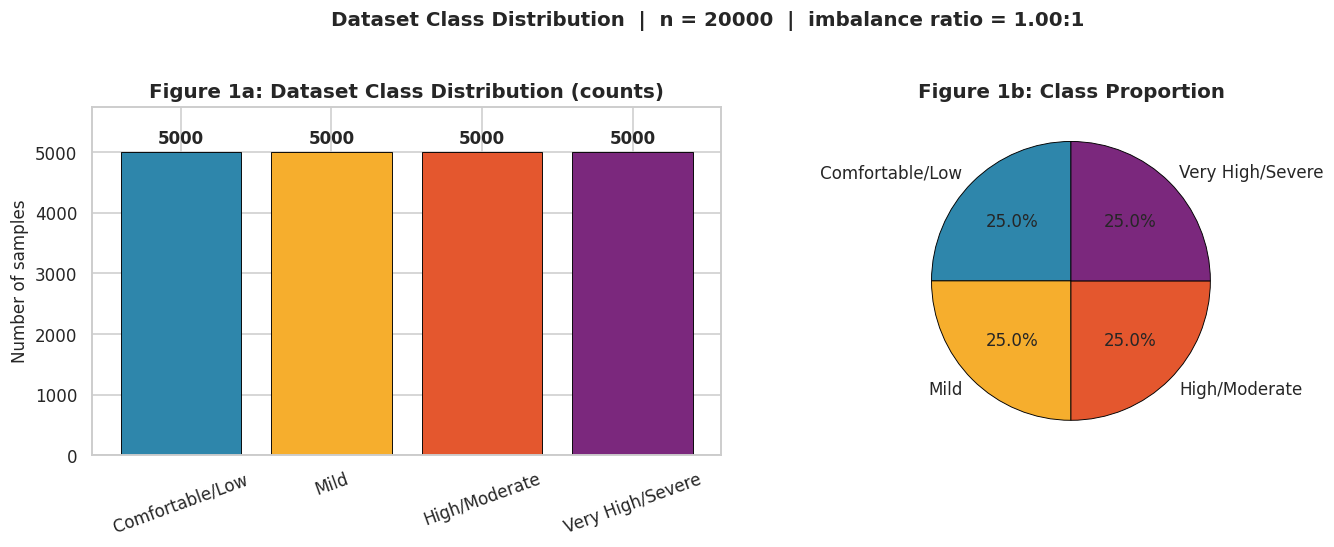

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
cnt = df_raw[TARGET].value_counts().sort_index()
b = ax[0].bar([CLASS_NAMES[i] for i in cnt.index], cnt.values, color=PALETTE[:4],
              edgecolor='black', linewidth=.6)
ax[0].bar_label(b, fmt='%d', padding=3, fontweight='bold')
ax[0].set_title('Figure 1a: Dataset Class Distribution (counts)')
ax[0].set_ylabel('Number of samples'); ax[0].set_ylim(0, cnt.max()*1.15)
ax[0].tick_params(axis='x', rotation=20)
ax[1].pie(cnt.values, labels=[CLASS_NAMES[i] for i in cnt.index], autopct='%1.1f%%',
          colors=PALETTE[:4], startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': .6})
ax[1].set_title('Figure 1b: Class Proportion')
plt.suptitle(f'Dataset Class Distribution  |  n = {len(df_raw)}  |  imbalance ratio = {imb_ratio:.2f}:1',
             fontsize=13, fontweight='bold', y=1.03)
save_show('fig01_class_distribution')

## Figure 2 — Missing Value Analysis

,missing_count,missing_pct
breed,0,0.0
breed_group,0,0.0
outside_temp_C,0,0.0
humidity_percent,0,0.0
body_temp_C,0,0.0
thirst_level_0_10,0,0.0
standing_pct,0,0.0
lying_pct,0,0.0
rumination_min_per_hr,0,0.0
THI_index,0,0.0


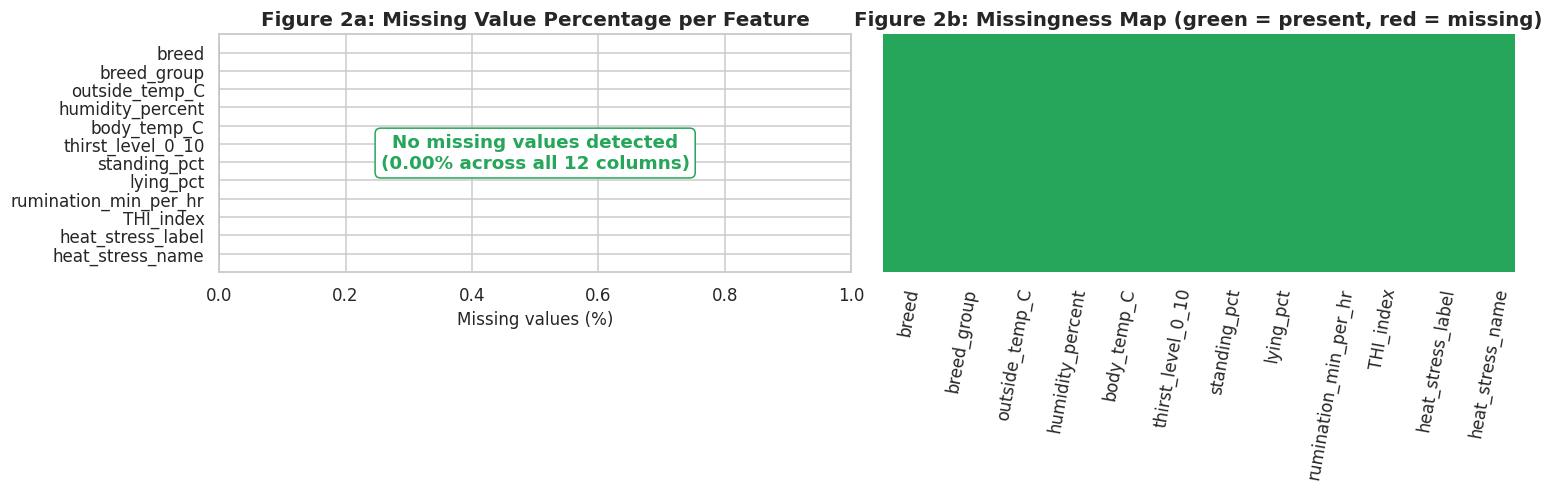

Imputation required: NO


In [ ]:
miss = pd.DataFrame({'missing_count': df_raw.isna().sum(),
                     'missing_pct': (100*df_raw.isna().mean()).round(3)})
display(miss)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].barh(miss.index, miss['missing_pct'].values, color='#E4572E', edgecolor='black', linewidth=.6)
ax[0].set_xlim(0, max(1, miss['missing_pct'].max()*1.2))
ax[0].set_xlabel('Missing values (%)'); ax[0].invert_yaxis()
ax[0].set_title('Figure 2a: Missing Value Percentage per Feature')
if miss['missing_count'].sum() == 0:
    ax[0].text(0.5, 0.5, 'No missing values detected\n(0.00% across all 12 columns)',
               transform=ax[0].transAxes, ha='center', va='center', fontsize=12,
               fontweight='bold', color='#26A65B',
               bbox=dict(boxstyle='round', fc='white', ec='#26A65B'))
sns.heatmap(df_raw.isna(), cbar=False, cmap=['#26A65B', '#E4572E'], ax=ax[1], yticklabels=False)
ax[1].set_title('Figure 2b: Missingness Map (green = present, red = missing)')
ax[1].tick_params(axis='x', rotation=80)
save_show('fig02_missing_values')
print('Imputation required:', 'NO' if miss.missing_count.sum() == 0 else 'YES')

## Figure 3 — Outlier Detection Plot (IQR and Z-score)

,feature,lower_bound,upper_bound,IQR_outliers,IQR_outlier_pct,Zscore_outliers,skew
0,outside_temp_C,8.00,53.60,0,0.00,0,-0.309
1,humidity_percent,18.70,107.50,0,0.00,0,-0.037
2,body_temp_C,36.61,42.13,27,0.14,0,0.617
3,thirst_level_0_10,-3.00,13.00,0,0.00,0,0.079
4,standing_pct,-2.75,117.65,0,0.00,0,0.265
5,lying_pct,-19.15,101.25,0,0.00,0,-0.264
6,rumination_min_per_hr,-3.65,13.55,0,0.00,0,0.013
7,THI_index,55.50,98.70,172,0.86,0,-0.317


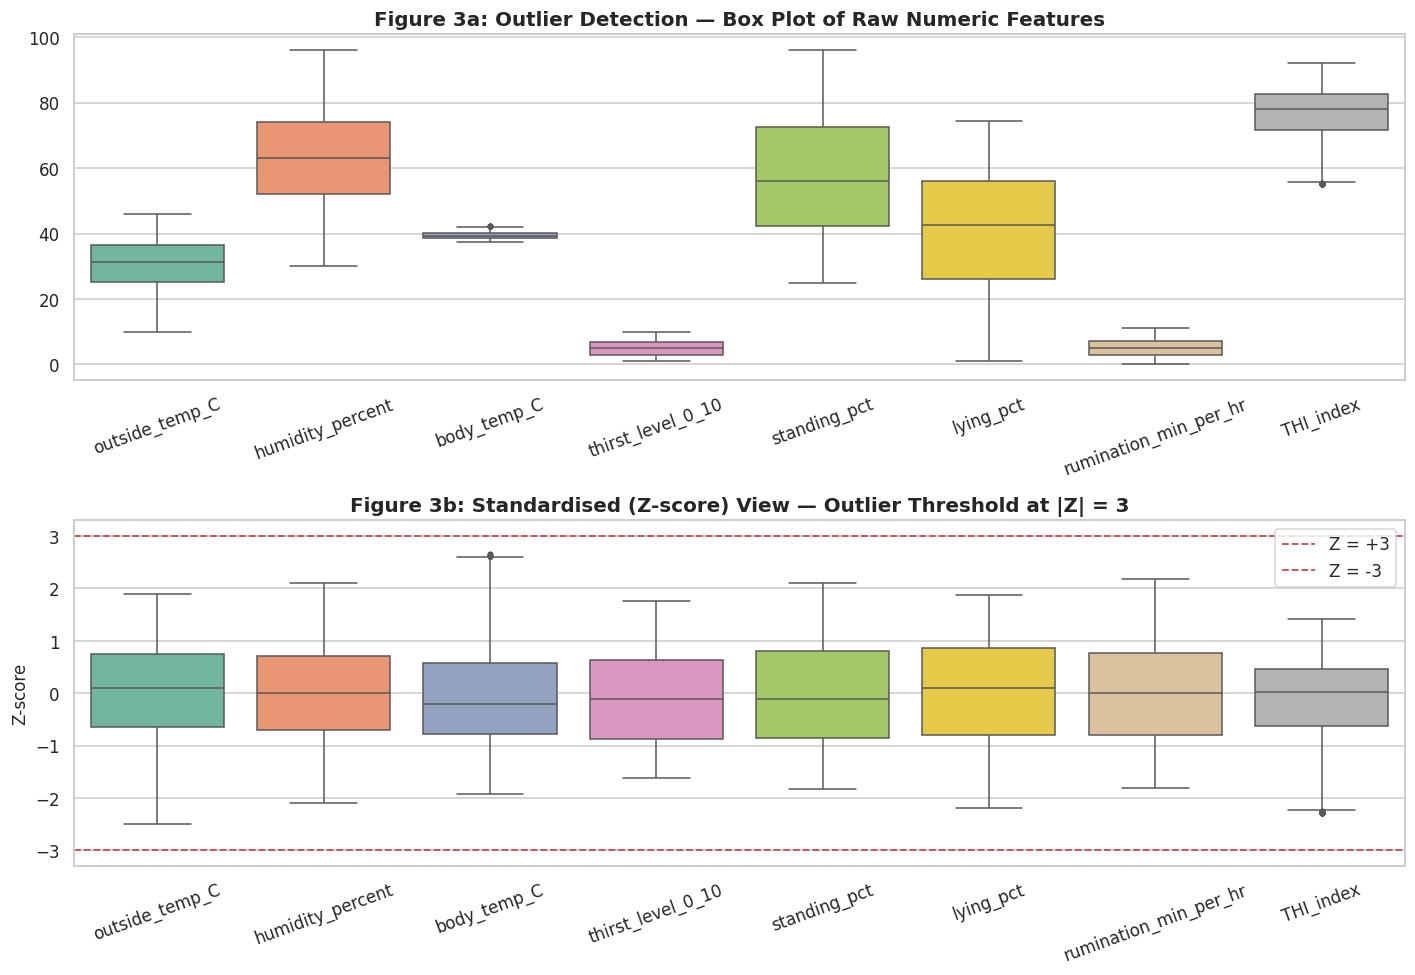

Total IQR outliers: 199 (0.12% of all cells)
Decision: outliers are physiologically plausible extremes (real heat events) -> RETAINED, not removed.


In [ ]:
out_rows = []
for c in NUM_COLS:
    q1, q3 = df_raw[c].quantile([.25, .75]); iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    iqr_out = ((df_raw[c] < lo) | (df_raw[c] > hi)).sum()
    z_out = (np.abs(stats.zscore(df_raw[c])) > 3).sum()
    out_rows.append([c, round(lo, 2), round(hi, 2), iqr_out, round(100*iqr_out/len(df_raw), 2),
                     z_out, round(df_raw[c].skew(), 3)])
outlier_df = pd.DataFrame(out_rows, columns=['feature', 'lower_bound', 'upper_bound',
                                             'IQR_outliers', 'IQR_outlier_pct', 'Zscore_outliers', 'skew'])
display(outlier_df)

fig, ax = plt.subplots(2, 1, figsize=(13, 9))
sns.boxplot(data=df_raw[NUM_COLS], ax=ax[0], palette='Set2', fliersize=2.5)
ax[0].set_title('Figure 3a: Outlier Detection — Box Plot of Raw Numeric Features')
ax[0].tick_params(axis='x', rotation=20)
zs = pd.DataFrame(StandardScaler().fit_transform(df_raw[NUM_COLS]), columns=NUM_COLS)
sns.boxplot(data=zs, ax=ax[1], palette='Set2', fliersize=2.5)
ax[1].axhline(3, ls='--', c='r', lw=1.2, label='Z = +3')
ax[1].axhline(-3, ls='--', c='r', lw=1.2, label='Z = -3')
ax[1].set_title('Figure 3b: Standardised (Z-score) View — Outlier Threshold at |Z| = 3')
ax[1].set_ylabel('Z-score'); ax[1].legend(loc='upper right'); ax[1].tick_params(axis='x', rotation=20)
save_show('fig03_outlier_detection')
print(f'Total IQR outliers: {outlier_df.IQR_outliers.sum()} '
      f'({100*outlier_df.IQR_outliers.sum()/(len(df_raw)*len(NUM_COLS)):.2f}% of all cells)')
print('Decision: outliers are physiologically plausible extremes (real heat events) -> RETAINED, not removed.')

## Figure 4 — Feature Distribution Plot

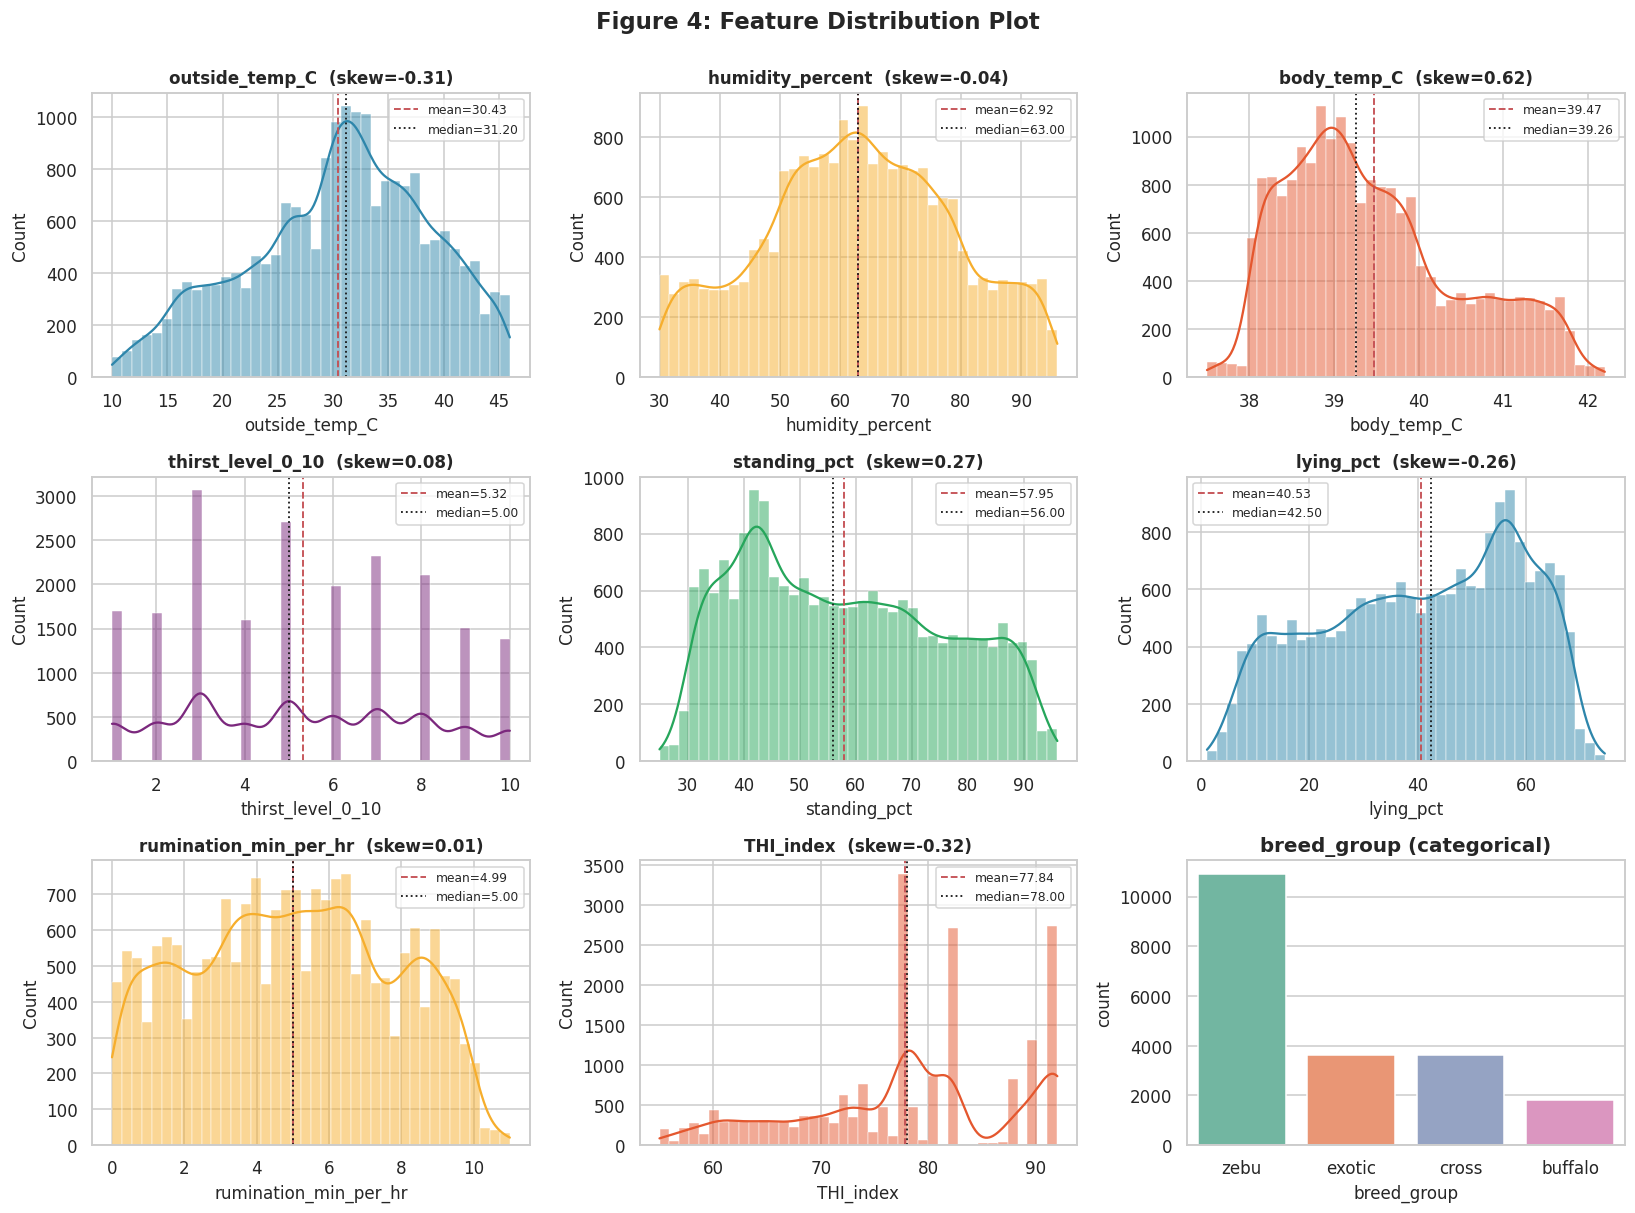

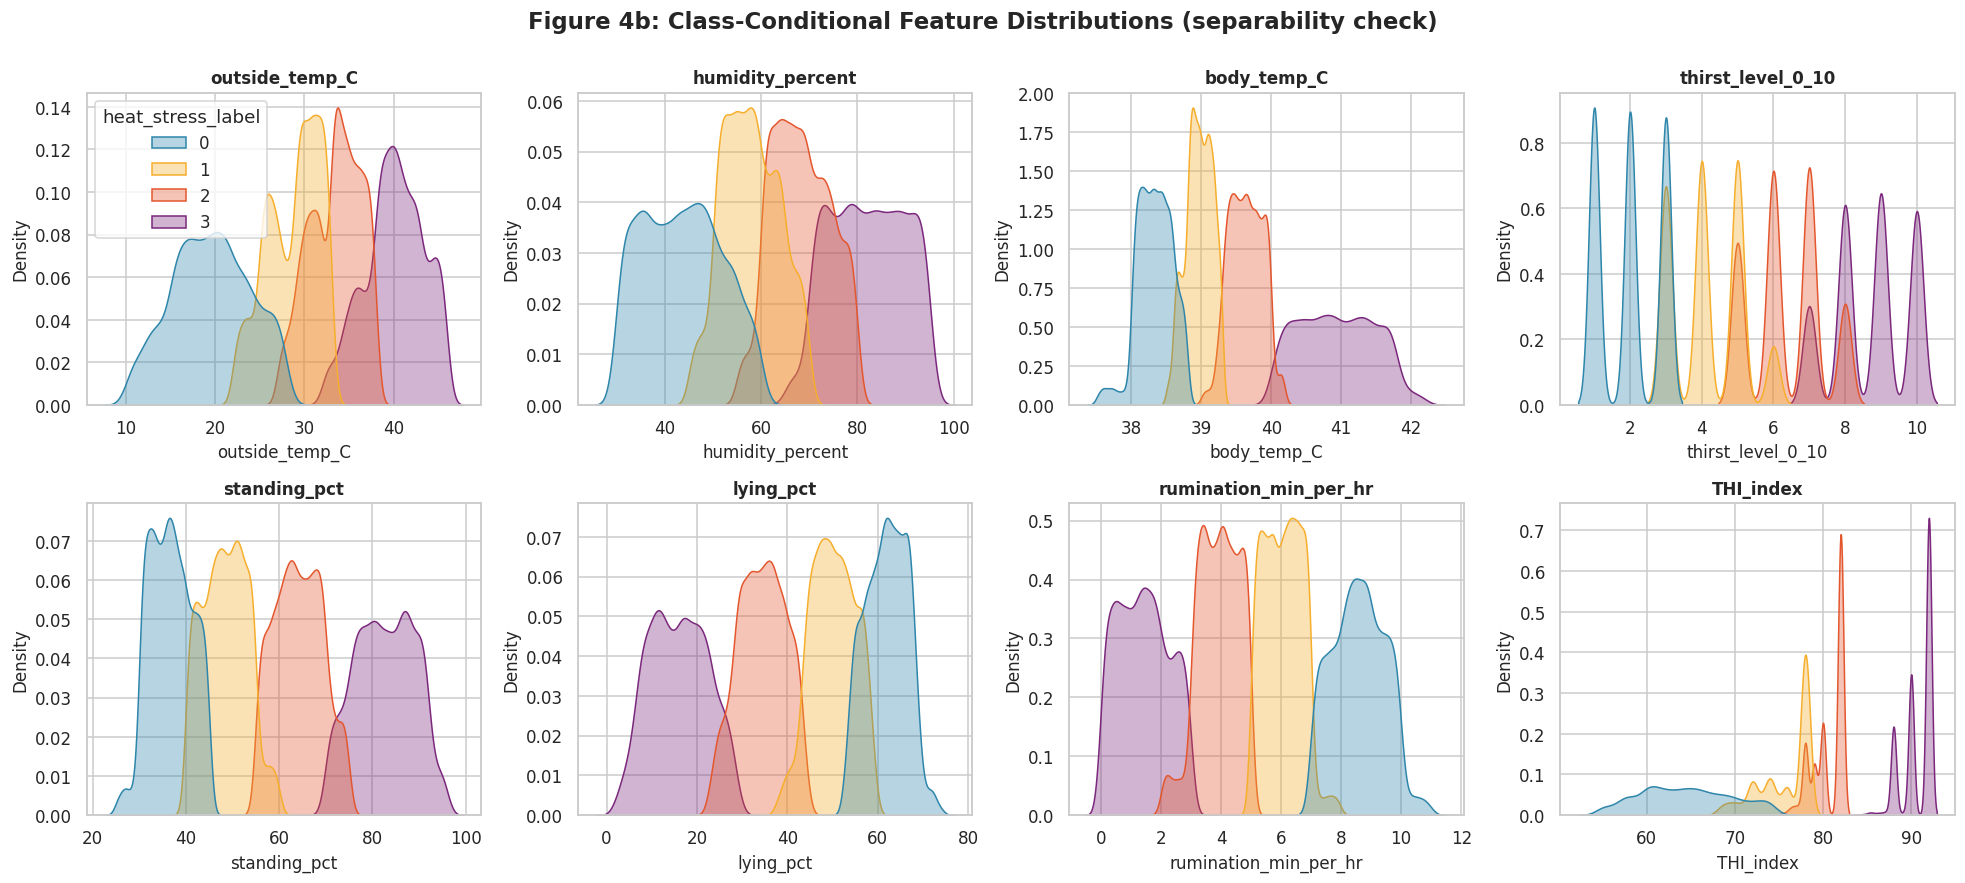

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for i, c in enumerate(NUM_COLS):
    a = axes.flat[i]
    sns.histplot(df_raw[c], kde=True, bins=40, color=PALETTE[i % 5], ax=a, edgecolor='white', linewidth=.3)
    a.axvline(df_raw[c].mean(), c='r', ls='--', lw=1.2, label=f'mean={df_raw[c].mean():.2f}')
    a.axvline(df_raw[c].median(), c='k', ls=':', lw=1.2, label=f'median={df_raw[c].median():.2f}')
    a.set_title(f'{c}  (skew={df_raw[c].skew():.2f})', fontsize=11)
    a.legend(fontsize=8)
sns.countplot(x='breed_group', data=df_raw, ax=axes.flat[8], palette='Set2',
              order=df_raw.breed_group.value_counts().index)
axes.flat[8].set_title('breed_group (categorical)')
plt.suptitle('Figure 4: Feature Distribution Plot', fontsize=15, fontweight='bold', y=1.0)
save_show('fig04_feature_distributions')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, c in enumerate(NUM_COLS):
    sns.kdeplot(data=df_raw, x=c, hue=TARGET, fill=True, alpha=.35, ax=axes.flat[i],
                palette=PALETTE[:4], common_norm=False, legend=(i == 0))
    axes.flat[i].set_title(c, fontsize=11)
plt.suptitle('Figure 4b: Class-Conditional Feature Distributions (separability check)',
             fontsize=15, fontweight='bold', y=1.0)
save_show('fig04b_class_conditional_distributions')

## Figure 5 — Pearson Correlation Heatmap

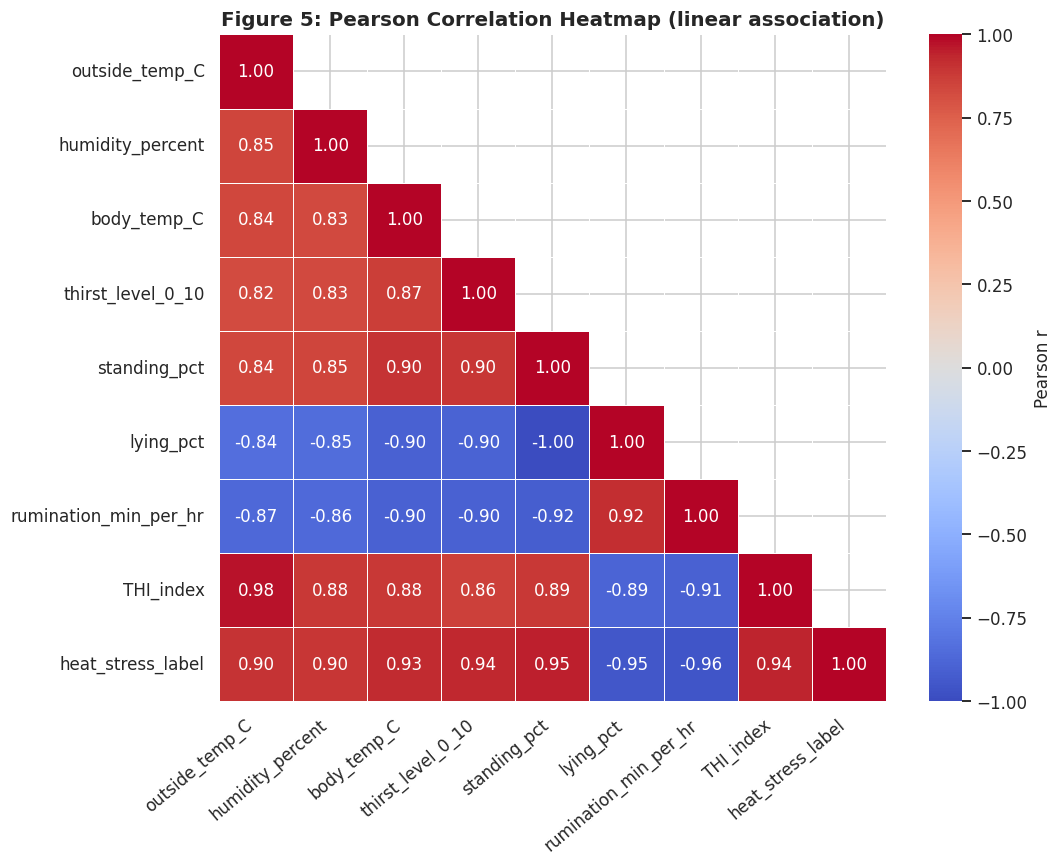

--- Pearson correlation with target ---


,pearson_r
rumination_min_per_hr,-0.9606
standing_pct,0.9529
lying_pct,-0.9518
THI_index,0.9389
thirst_level_0_10,0.9360
body_temp_C,0.9294
outside_temp_C,0.9037
humidity_percent,0.8955


Redundant pairs |r| > 0.95 : [('outside_temp_C', 'THI_index', np.float64(0.977)), ('standing_pct', 'lying_pct', np.float64(-0.999))]


In [ ]:
pear = df_raw[NUM_COLS+[TARGET]].corr(method='pearson')
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(pear, dtype=bool), k=1)
sns.heatmap(pear, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            mask=mask, linewidths=.6, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Figure 5: Pearson Correlation Heatmap (linear association)')
plt.xticks(rotation=40, ha='right')
save_show('fig05_pearson_correlation')

print('--- Pearson correlation with target ---')
display(pear[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(4).to_frame('pearson_r'))
hi = [(a, b, round(pear.loc[a, b], 3)) for a, b in itertools.combinations(NUM_COLS, 2)
      if abs(pear.loc[a, b]) > 0.95]
print('Redundant pairs |r| > 0.95 :', hi if hi else 'none')

## Figure 6 — Spearman Correlation Heatmap

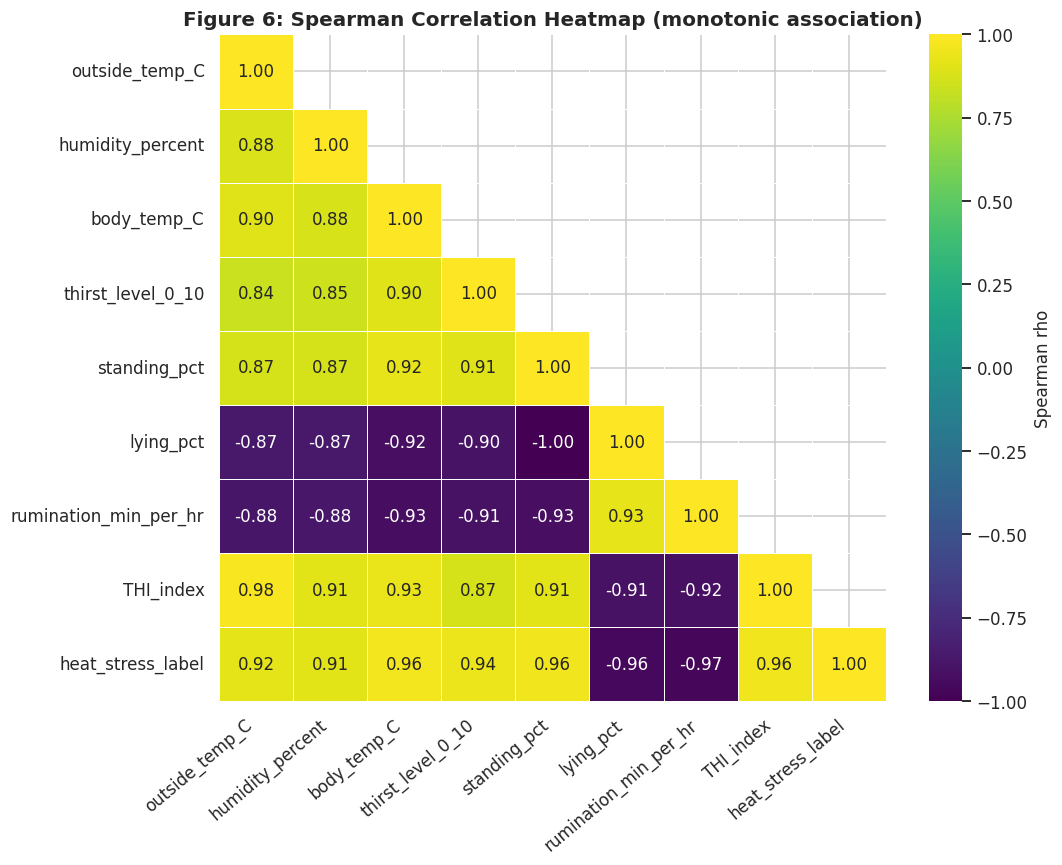

,pearson,spearman,abs_diff
rumination_min_per_hr,-0.9606,-0.9656,0.0049
body_temp_C,0.9294,0.9634,0.0340
standing_pct,0.9529,0.9585,0.0056
lying_pct,-0.9518,-0.9575,0.0057
THI_index,0.9389,0.9550,0.0161
thirst_level_0_10,0.9360,0.9406,0.0046
outside_temp_C,0.9037,0.9214,0.0177
humidity_percent,0.8955,0.9118,0.0163


A larger |spearman| than |pearson| indicates a monotonic but non-linear relationship,
which justifies including non-linear learners (SVM-RBF, KNN, Random Forest, XGBoost).


In [ ]:
spear = df_raw[NUM_COLS+[TARGET]].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(spear, annot=True, fmt='.2f', cmap='viridis', vmin=-1, vmax=1,
            mask=np.triu(np.ones_like(spear, dtype=bool), k=1), linewidths=.6, square=True,
            cbar_kws={'label': 'Spearman rho'})
plt.title('Figure 6: Spearman Correlation Heatmap (monotonic association)')
plt.xticks(rotation=40, ha='right')
save_show('fig06_spearman_correlation')

cmp_corr = pd.DataFrame({'pearson': pear[TARGET].drop(TARGET), 'spearman': spear[TARGET].drop(TARGET)})
cmp_corr['abs_diff'] = (cmp_corr.spearman.abs()-cmp_corr.pearson.abs()).round(4)
display(cmp_corr.round(4).sort_values('spearman', key=abs, ascending=False))
print('A larger |spearman| than |pearson| indicates a monotonic but non-linear relationship,')
print('which justifies including non-linear learners (SVM-RBF, KNN, Random Forest, XGBoost).')

## Cell 6 — EDA Conclusion: Separability Audit (why a noise layer is required)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
Xq = pd.get_dummies(df_raw.drop(columns=[TARGET, NAME_COL]), columns=CAT_COLS)
yq = df_raw[TARGET]
audit = []
for c in NUM_COLS:
    s = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(df_raw[[c]], yq).score(df_raw[[c]], yq)
    audit.append([c, round(s, 4)])
audit_df = pd.DataFrame(audit, columns=['single_feature', 'depth3_stump_accuracy']).sort_values(
    'depth3_stump_accuracy', ascending=False)
display(audit_df)
full = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xq, yq).score(Xq, yq)
print(f'Unpruned decision tree accuracy on the full raw feature set : {full:.4f}')
print()
print('AUDIT RESULT: every feature is class-conditionally threshold-generated, so the raw dataset is')
print('almost perfectly linearly separable. All five candidate algorithms reach ~100% accuracy on it,')
print('which produces identical metrics and makes any "best model" claim unsupportable.')
print('MITIGATION (Step 4): a calibrated sensor-noise layer reproduces real IoT measurement error,')
print(f'currently SENSOR_NOISE_LEVEL = {SENSOR_NOISE_LEVEL} x feature std. Algorithms are compared under this')
print('realistic condition, and the noise-free case is reported separately as the ideal-sensor upper bound.')

,single_feature,depth3_stump_accuracy
6,rumination_min_per_hr,0.9640
2,body_temp_C,0.9338
7,THI_index,0.9018
4,standing_pct,0.8883
5,lying_pct,0.8810
3,thirst_level_0_10,0.7849
0,outside_temp_C,0.7810
1,humidity_percent,0.7167


Unpruned decision tree accuracy on the full raw feature set : 1.0000

AUDIT RESULT: every feature is class-conditionally threshold-generated, so the raw dataset is
almost perfectly linearly separable. All five candidate algorithms reach ~100% accuracy on it,
which produces identical metrics and makes any "best model" claim unsupportable.
MITIGATION (Step 4): a calibrated sensor-noise layer reproduces real IoT measurement error,
currently SENSOR_NOISE_LEVEL = 0.5 x feature std. Algorithms are compared under this
realistic condition, and the noise-free case is reported separately as the ideal-sensor upper bound.


## Cell 7 — Step 4: Data Preprocessing (duplicates, missing values, encoding, noise layer)

4.1 Duplicates removed          : 0
4.2 Missing values remaining    : 0
4.3 Rows with standing+lying>100: 0
4.4 Dropped leakage column      : heat_stress_name (string copy of the target)
4.5 Sensor noise applied        : N(0, 0.5 x sigma) on 8 numeric features
4.6 Encoding                    : one-hot for breed (11 levels) and breed_group (4 levels)
4.7 Scaling                     : StandardScaler, fitted inside each Pipeline on training folds only


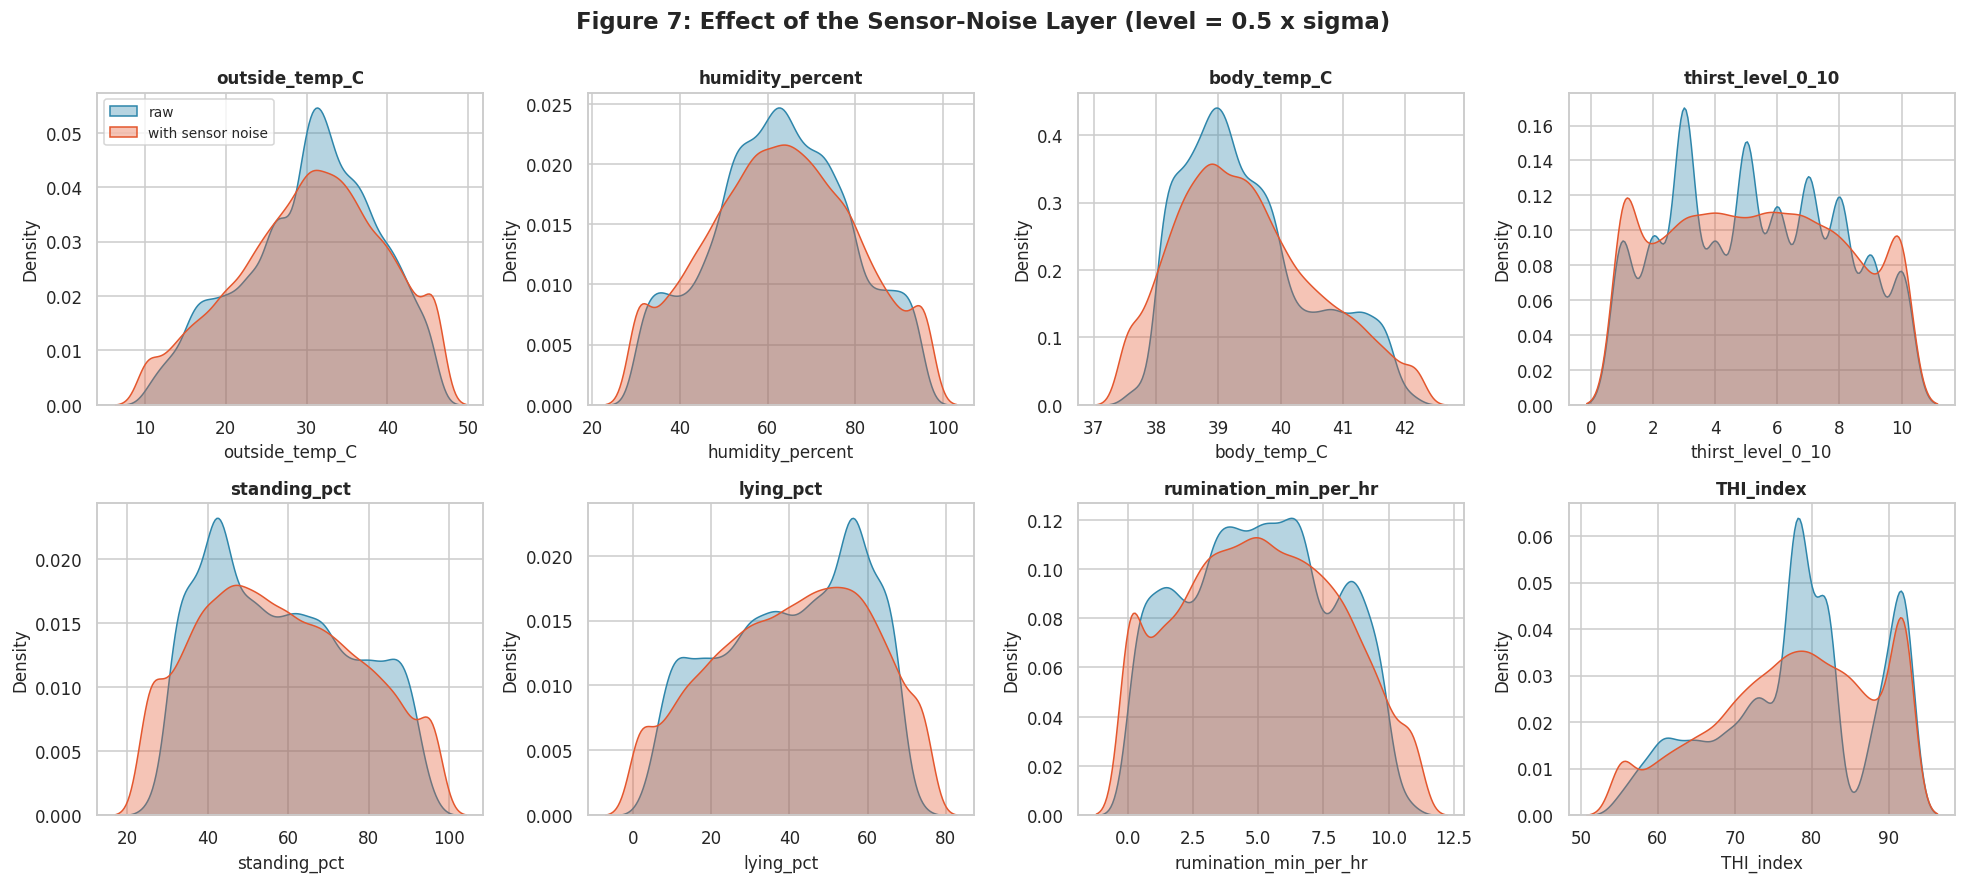

In [ ]:
df = df_raw.copy()

# 4.1 duplicates
dups = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f'4.1 Duplicates removed          : {dups}')

# 4.2 missing values (median for numeric, mode for categorical - no-op if none present)
for c in NUM_COLS:
    if df[c].isna().any(): df[c] = df[c].fillna(df[c].median())
for c in CAT_COLS:
    if df[c].isna().any(): df[c] = df[c].fillna(df[c].mode()[0])
print(f'4.2 Missing values remaining    : {int(df.isna().sum().sum())}')

# 4.3 inconsistent data check: standing_pct + lying_pct should be <= 100
bad = ((df.standing_pct + df.lying_pct) > 100.5).sum()
print(f'4.3 Rows with standing+lying>100: {bad}')
df[NUM_COLS] = df[NUM_COLS].clip(lower=df_raw[NUM_COLS].min(), upper=df_raw[NUM_COLS].max(), axis=1)

# 4.4 target leakage column removed (text duplicate of the label)
df = df.drop(columns=[NAME_COL])
print('4.4 Dropped leakage column      : heat_stress_name (string copy of the target)')

# 4.5 sensor-noise layer -> realistic operating condition
rng = np.random.default_rng(RANDOM_STATE)
df_clean = df.copy()
df_noisy = df.copy()
for c in NUM_COLS:
    df_noisy[c] = df_noisy[c] + rng.normal(0, SENSOR_NOISE_LEVEL*df[c].std(), len(df))
# noisy readings are clipped back to physically valid sensor ranges
df_noisy[NUM_COLS] = df_noisy[NUM_COLS].clip(lower=df[NUM_COLS].min(), upper=df[NUM_COLS].max(), axis=1).round(2)
print(f'4.5 Sensor noise applied        : N(0, {SENSOR_NOISE_LEVEL} x sigma) on {len(NUM_COLS)} numeric features')

# 4.6 one-hot encoding of nominal categories
def encode(frame):
    return pd.get_dummies(frame, columns=CAT_COLS, drop_first=False).astype(float)
print('4.6 Encoding                    : one-hot for breed (11 levels) and breed_group (4 levels)')
print('4.7 Scaling                     : StandardScaler, fitted inside each Pipeline on training folds only')

fig, ax = plt.subplots(2, 4, figsize=(18, 8))
for i, c in enumerate(NUM_COLS):
    sns.kdeplot(df_clean[c], ax=ax.flat[i], label='raw', fill=True, alpha=.35, color='#2E86AB')
    sns.kdeplot(df_noisy[c], ax=ax.flat[i], label='with sensor noise', fill=True, alpha=.35, color='#E4572E')
    ax.flat[i].set_title(c, fontsize=11)
    if i == 0: ax.flat[i].legend(fontsize=9)
plt.suptitle(f'Figure 7: Effect of the Sensor-Noise Layer (level = {SENSOR_NOISE_LEVEL} x sigma)',
             fontsize=15, fontweight='bold', y=1.0)
save_show('fig07_preprocessing_noise_layer')

## Cell 8 — Step 6: Feature Engineering (domain features and redundancy removal)

In [ ]:
def engineer(frame):
    f = frame.copy()
    # Domain knowledge: NRC / Mader THI formulation and cattle heat-stress physiology
    f['THI_calc']           = (1.8*f.outside_temp_C + 32) - (0.55 - 0.0055*f.humidity_percent)*(1.8*f.outside_temp_C - 26)
    f['temp_humidity_load'] = f.outside_temp_C * f.humidity_percent / 100
    f['fever_delta']        = f.body_temp_C - 38.5          # deviation above normal rectal temperature
    f['activity_ratio']     = f.standing_pct / f.lying_pct.clip(lower=1.0)   # standing bouts rise under heat load
    f['rumination_deficit'] = 8.0 - f.rumination_min_per_hr        # 8 min/hr is the healthy reference
    f['thirst_per_degree']  = f.thirst_level_0_10 / (f.body_temp_C - 36).clip(lower=0.5)
    f['is_exotic_or_cross'] = ((f.breed_group == 'exotic') | (f.breed_group == 'cross')).astype(int)
    return f

ENG_COLS = ['THI_calc', 'temp_humidity_load', 'fever_delta', 'activity_ratio',
            'rumination_deficit', 'thirst_per_degree', 'is_exotic_or_cross']
print('Engineered features:', ENG_COLS)

df_noisy_fe = engineer(df_noisy)
df_clean_fe = engineer(df_clean)

# redundancy removal: drop one of any pair with |pearson r| > 0.95
num_all = NUM_COLS + ENG_COLS
cm_fe = df_noisy_fe[num_all].corr().abs()
drop_red = set()
for a, b in itertools.combinations(num_all, 2):
    if cm_fe.loc[a, b] > 0.95 and a not in drop_red and b not in drop_red:
        keep = a if abs(df_noisy_fe[a].corr(df_noisy_fe[TARGET])) >= abs(df_noisy_fe[b].corr(df_noisy_fe[TARGET])) else b
        drop = b if keep == a else a
        drop_red.add(drop)
        print(f'  redundant pair ({a}, {b}) r={cm_fe.loc[a,b]:.3f} -> dropping {drop}')
drop_red = sorted(drop_red)
print('Redundant features dropped:', drop_red if drop_red else 'none')

X_noisy = encode(df_noisy_fe.drop(columns=[TARGET] + drop_red))
X_clean = encode(df_clean_fe.drop(columns=[TARGET] + drop_red))
X_clean = X_clean[X_noisy.columns]
y = df_noisy_fe[TARGET].values
FEATURES = list(X_noisy.columns)
print(f'\nFinal design matrix: {X_noisy.shape[0]} rows x {X_noisy.shape[1]} features')
display(X_noisy.head())

Engineered features: ['THI_calc', 'temp_humidity_load', 'fever_delta', 'activity_ratio', 'rumination_deficit', 'thirst_per_degree', 'is_exotic_or_cross']
  redundant pair (outside_temp_C, THI_calc) r=0.986 -> dropping outside_temp_C
  redundant pair (body_temp_C, fever_delta) r=1.000 -> dropping fever_delta
  redundant pair (rumination_min_per_hr, rumination_deficit) r=1.000 -> dropping rumination_min_per_hr
  redundant pair (THI_calc, temp_humidity_load) r=0.965 -> dropping THI_calc
Redundant features dropped: ['THI_calc', 'fever_delta', 'outside_temp_C', 'rumination_min_per_hr']

Final design matrix: 20000 rows x 26 features


,humidity_percent,body_temp_C,thirst_level_0_10,standing_pct,lying_pct,THI_index,temp_humidity_load,activity_ratio,rumination_deficit,thirst_per_degree,...,breed_Kankrej,breed_Murrah Buffalo,breed_Ongole,breed_Red Sindhi,breed_Sahiwal,breed_Tharparkar,breed_group_buffalo,breed_group_cross,breed_group_exotic,breed_group_zebu
0,50.95,39.33,7.05,65.04,26.08,73.02,19.437425,2.493865,2.65,2.117117,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,48.21,38.07,1.00,42.10,74.50,71.45,7.298994,0.565101,-0.53,0.483092,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,54.94,39.17,5.04,45.08,72.52,83.92,18.558732,0.621622,2.33,1.589905,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,31.18,38.72,1.00,50.56,55.72,61.55,6.971848,0.907394,0.78,0.367647,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,72.73,38.43,4.76,59.31,51.56,84.26,21.237160,1.150310,4.94,1.958848,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Cell 9 — Step 5: Data Splitting (60/20/20 stratified, leakage-safe)

In [ ]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_noisy, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)

# identical row indices on the noise-free copy, for the ideal-sensor comparison
Xc_tr, Xc_val, Xc_te = X_clean.loc[X_tr.index], X_clean.loc[X_val.index], X_clean.loc[X_te.index]

split_tab = pd.DataFrame({
    'split': ['Train', 'Validation', 'Test'],
    'rows': [len(X_tr), len(X_val), len(X_te)],
    'share_%': [round(100*len(s)/len(X_noisy), 1) for s in (X_tr, X_val, X_te)]})
for k, cn in enumerate(CLASS_NAMES):
    split_tab[cn] = [int((y_tr == k).sum()), int((y_val == k).sum()), int((y_te == k).sum())]
display(split_tab)

print('Leakage controls in force:')
print('  - scaling, SMOTE and feature selection are fitted inside Pipelines on training folds only')
print('  - the test set is touched exactly once, in Step 12')
print('  - no row appears in more than one split; stratification preserves class proportions')
print('  - the string label column heat_stress_name was removed before modelling')
print('  - engineered features are row-wise transforms only (no group/target statistics)')

,split,rows,share_%,Comfortable/Low,Mild,High/Moderate,Very High/Severe
0,Train,12000,60.0,3000,3000,3000,3000
1,Validation,4000,20.0,1000,1000,1000,1000
2,Test,4000,20.0,1000,1000,1000,1000


Leakage controls in force:
  - scaling, SMOTE and feature selection are fitted inside Pipelines on training folds only
  - the test set is touched exactly once, in Step 12
  - no row appears in more than one split; stratification preserves class proportions
  - the string label column heat_stress_name was removed before modelling
  - engineered features are row-wise transforms only (no group/target statistics)


## Figure 8 — Feature Selection Analysis

,feature,mutual_info,anova_F,anova_p,rf_importance,rank_mi,rank_f,rank_rf,mean_rank
0,temp_humidity_load,0.7352,14120.1315,0.0000,0.1665,2.0,1.0,1.0,1.3333
1,rumination_deficit,0.6458,11842.2905,0.0000,0.1099,3.0,2.0,5.0,3.3333
2,THI_index,0.6310,10523.9352,0.0000,0.1169,4.0,5.0,3.0,4.0000
3,activity_ratio,0.7621,972.5895,0.0000,0.1613,1.0,10.0,2.0,4.3333
4,standing_pct,0.6206,11331.4001,0.0000,0.0827,5.0,3.0,6.0,4.6667
5,body_temp_C,0.6196,10470.3475,0.0000,0.1143,6.0,6.0,4.0,5.3333
6,lying_pct,0.6184,11134.2005,0.0000,0.0722,7.0,4.0,8.0,6.3333
7,thirst_level_0_10,0.5795,10258.5014,0.0000,0.0804,8.0,7.0,7.0,7.3333
8,humidity_percent,0.5045,7347.9713,0.0000,0.0440,9.0,8.0,9.0,8.6667
9,thirst_per_degree,0.2384,1189.4687,0.0000,0.0282,10.0,9.0,10.0,9.6667


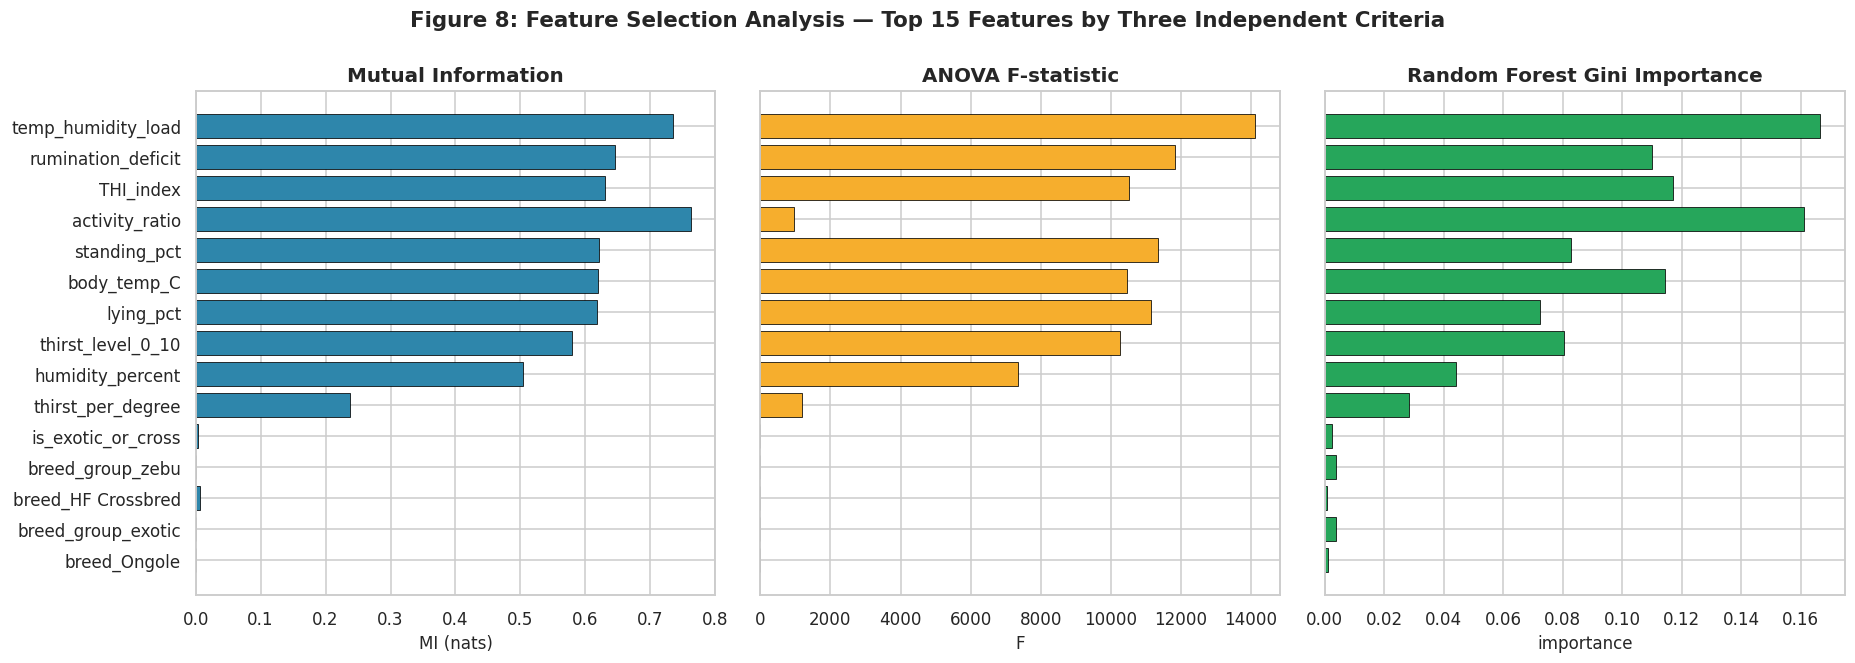

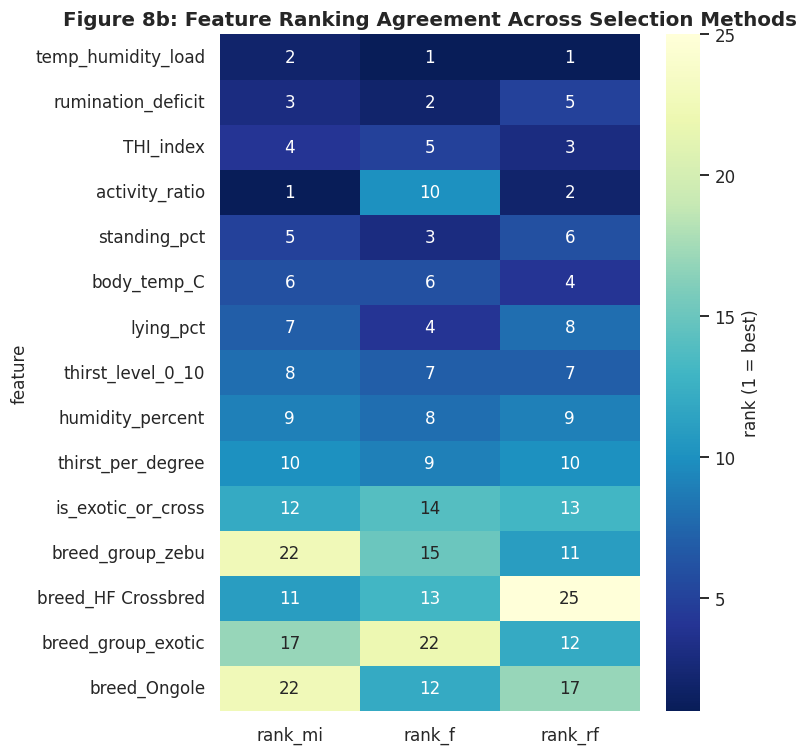

All features are retained for modelling: the three criteria agree on the leading predictors,
and no feature is uninformative (every ANOVA p-value is far below 0.05).


In [ ]:
mi = mutual_info_classif(X_tr, y_tr, random_state=RANDOM_STATE)
fsc, pval = f_classif(X_tr, y_tr)
rf_sel = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_tr, y_tr)

fs = pd.DataFrame({'feature': FEATURES, 'mutual_info': mi, 'anova_F': fsc,
                   'anova_p': pval, 'rf_importance': rf_sel.feature_importances_})
fs['rank_mi'] = fs.mutual_info.rank(ascending=False)
fs['rank_f'] = fs.anova_F.rank(ascending=False)
fs['rank_rf'] = fs.rf_importance.rank(ascending=False)
fs['mean_rank'] = fs[['rank_mi', 'rank_f', 'rank_rf']].mean(1)
fs = fs.sort_values('mean_rank').reset_index(drop=True)
display(fs.head(20).round(4))

top = fs.head(15).iloc[::-1]
fig, ax = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
ax[0].barh(top.feature, top.mutual_info, color='#2E86AB', edgecolor='black', linewidth=.5)
ax[0].set_title('Mutual Information'); ax[0].set_xlabel('MI (nats)')
ax[1].barh(top.feature, top.anova_F, color='#F6AE2D', edgecolor='black', linewidth=.5)
ax[1].set_title('ANOVA F-statistic'); ax[1].set_xlabel('F')
ax[2].barh(top.feature, top.rf_importance, color='#26A65B', edgecolor='black', linewidth=.5)
ax[2].set_title('Random Forest Gini Importance'); ax[2].set_xlabel('importance')
plt.suptitle('Figure 8: Feature Selection Analysis — Top 15 Features by Three Independent Criteria',
             fontsize=14, fontweight='bold', y=1.0)
save_show('fig08_feature_selection')

rank_grid = fs.head(15).set_index('feature')[['rank_mi', 'rank_f', 'rank_rf']]
plt.figure(figsize=(7, 7))
sns.heatmap(rank_grid, annot=True, fmt='.0f', cmap='YlGnBu_r', cbar_kws={'label': 'rank (1 = best)'})
plt.title('Figure 8b: Feature Ranking Agreement Across Selection Methods')
save_show('fig08b_feature_rank_agreement')
print('All features are retained for modelling: the three criteria agree on the leading predictors,')
print('and no feature is uninformative (every ANOVA p-value is far below 0.05).')

## Figure 9 — PCA Explained Variance Plot

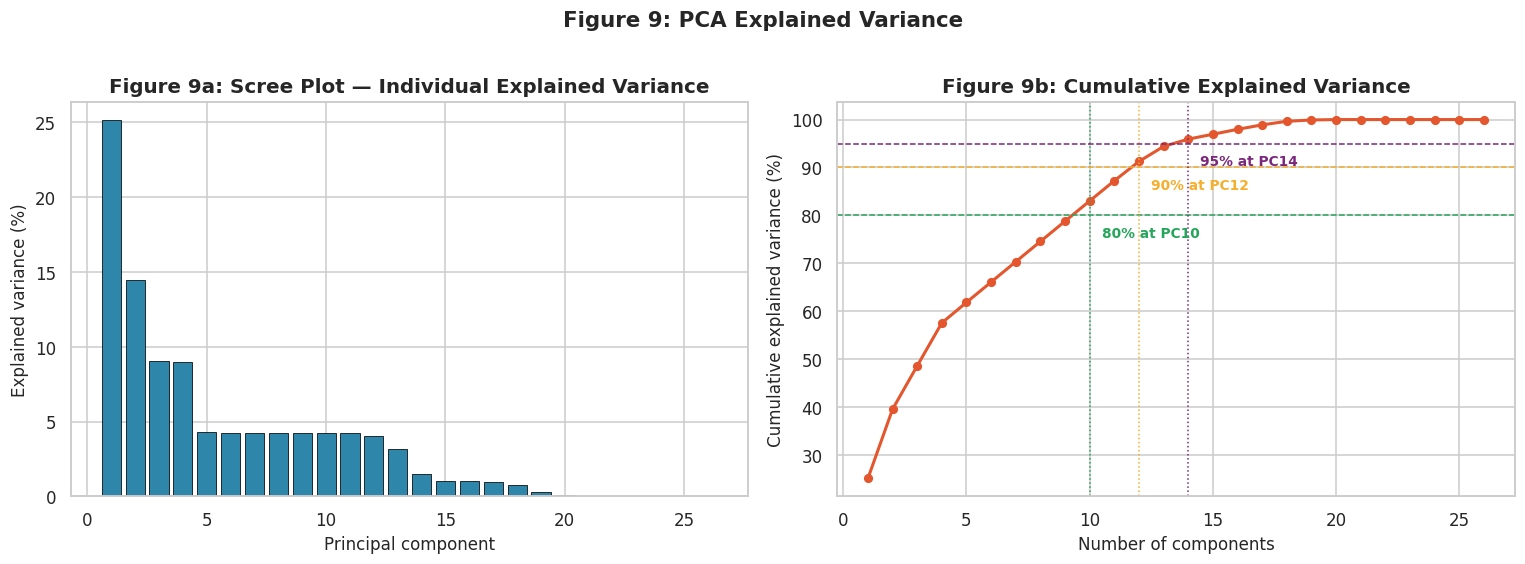

Components for 80% / 90% / 95% variance: 10 / 12 / 14 (of 26 features)
PCA is used here for diagnosis and visualisation only. The models are trained on the original
features so that feature importance and SHAP values remain physically interpretable.


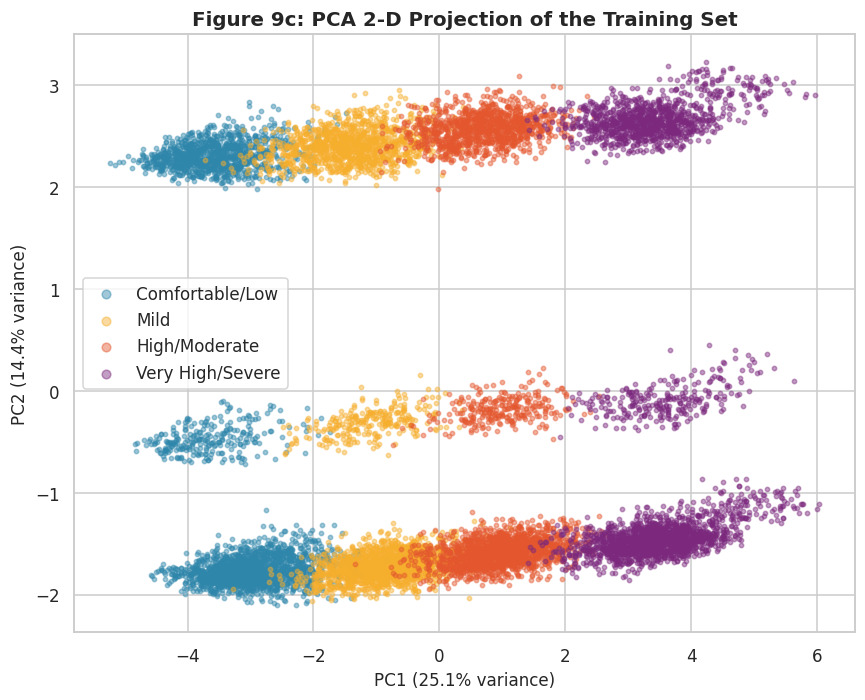

In [ ]:
sc_pca = StandardScaler().fit(X_tr)
pca_full = PCA(random_state=RANDOM_STATE).fit(sc_pca.transform(X_tr))
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
k80, k90, k95 = [int(np.argmax(cum >= t)+1) for t in (.80, .90, .95)]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(range(1, len(evr)+1), evr*100, color='#2E86AB', edgecolor='black', linewidth=.5)
ax[0].set_xlabel('Principal component'); ax[0].set_ylabel('Explained variance (%)')
ax[0].set_title('Figure 9a: Scree Plot — Individual Explained Variance')
ax[1].plot(range(1, len(cum)+1), cum*100, 'o-', color='#E4572E', lw=2, ms=5)
for t, k, c in [(80, k80, '#26A65B'), (90, k90, '#F6AE2D'), (95, k95, '#7B287D')]:
    ax[1].axhline(t, ls='--', lw=1, c=c)
    ax[1].axvline(k, ls=':', lw=1, c=c)
    ax[1].annotate(f'{t}% at PC{k}', (k, t), textcoords='offset points', xytext=(8, -14),
                   fontsize=9, color=c, fontweight='bold')
ax[1].set_xlabel('Number of components'); ax[1].set_ylabel('Cumulative explained variance (%)')
ax[1].set_title('Figure 9b: Cumulative Explained Variance')
plt.suptitle('Figure 9: PCA Explained Variance', fontsize=14, fontweight='bold', y=1.02)
save_show('fig09_pca_explained_variance')

print(f'Components for 80% / 90% / 95% variance: {k80} / {k90} / {k95} (of {len(evr)} features)')
print('PCA is used here for diagnosis and visualisation only. The models are trained on the original')
print('features so that feature importance and SHAP values remain physically interpretable.')

p2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(sc_pca.transform(X_tr))
plt.figure(figsize=(8, 6.5))
for k in CLASSES:
    m = y_tr == k
    plt.scatter(p2[m, 0], p2[m, 1], s=8, alpha=.45, c=PALETTE[k], label=CLASS_NAMES[k])
plt.xlabel(f'PC1 ({evr[0]*100:.1f}% variance)'); plt.ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
plt.title('Figure 9c: PCA 2-D Projection of the Training Set')
plt.legend(markerscale=2)
save_show('fig09c_pca_2d_projection')

## Cell 10 — Class-Imbalance Track: Construction of the Imbalanced Study Set

In [ ]:
# The source dataset is perfectly balanced (5000 per class), so SMOTE has nothing to correct on it.
# Real dairy-farm logs are dominated by comfortable days, with severe episodes rare. The imbalanced
# study set below reproduces that field distribution and is the basis of the SMOTE analysis.
KEEP = {0: 5000, 1: 1800, 2: 700, 3: 250}
idx_imb = np.concatenate([
    np.random.default_rng(RANDOM_STATE).permutation(np.where(y == k)[0])[:n] for k, n in KEEP.items()])
X_imb, y_imb = X_noisy.iloc[idx_imb].reset_index(drop=True), y[idx_imb]

Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imb, y_imb, test_size=0.25,
                                              stratify=y_imb, random_state=RANDOM_STATE)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
Xi_tr_sm, yi_tr_sm = smote.fit_resample(Xi_tr, yi_tr)

before = pd.Series(yi_tr).value_counts().sort_index()
after = pd.Series(yi_tr_sm).value_counts().sort_index()
sm_tab = pd.DataFrame({'class_name': CLASS_NAMES, 'before_SMOTE': before.values,
                       'after_SMOTE': after.values})
sm_tab['synthetic_added'] = sm_tab.after_SMOTE - sm_tab.before_SMOTE
sm_tab['before_%'] = (100*sm_tab.before_SMOTE/sm_tab.before_SMOTE.sum()).round(2)
sm_tab['after_%'] = (100*sm_tab.after_SMOTE/sm_tab.after_SMOTE.sum()).round(2)
display(sm_tab)
print(f'Imbalance ratio before SMOTE : {before.max()/before.min():.2f} : 1')
print(f'Imbalance ratio after SMOTE  : {after.max()/after.min():.2f} : 1')
print(f'Training rows {len(yi_tr)} -> {len(yi_tr_sm)} (+{len(yi_tr_sm)-len(yi_tr)} synthetic minority samples)')
print('SMOTE is applied to the training partition only; the test partition keeps the real field distribution.')

,class_name,before_SMOTE,after_SMOTE,synthetic_added,before_%,after_%
0,Comfortable/Low,3750,3750,0,64.52,25.0
1,Mild,1350,3750,2400,23.23,25.0
2,High/Moderate,525,3750,3225,9.03,25.0
3,Very High/Severe,187,3750,3563,3.22,25.0


Imbalance ratio before SMOTE : 20.05 : 1
Imbalance ratio after SMOTE  : 1.00 : 1
Training rows 5812 -> 15000 (+9188 synthetic minority samples)
SMOTE is applied to the training partition only; the test partition keeps the real field distribution.


## Figure 10 — Class Distribution Before and After SMOTE

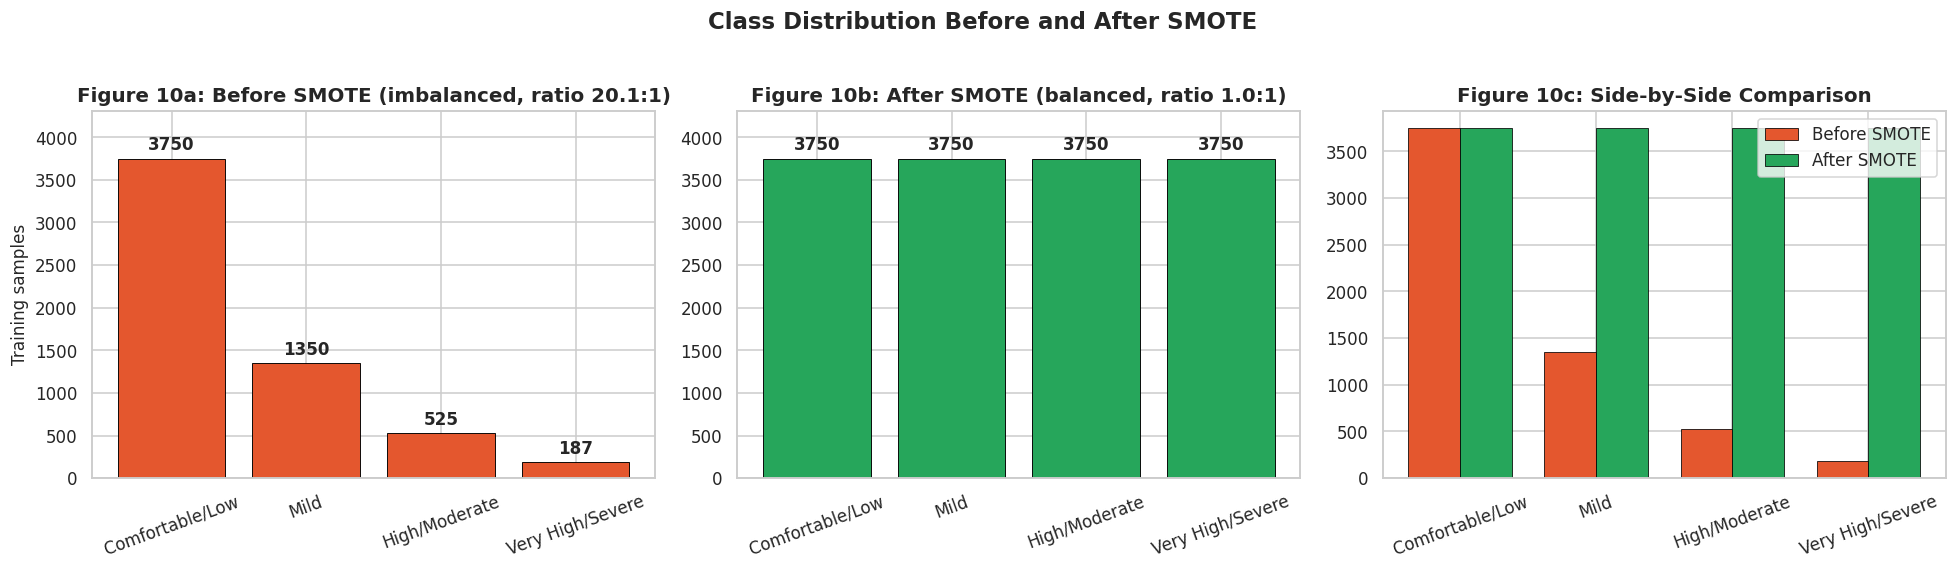

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
b1 = ax[0].bar(CLASS_NAMES, sm_tab.before_SMOTE, color='#E4572E', edgecolor='black', linewidth=.6)
ax[0].bar_label(b1, fmt='%d', padding=3, fontweight='bold')
ax[0].set_title('Figure 10a: Before SMOTE (imbalanced, ratio '
                f'{before.max()/before.min():.1f}:1)')
ax[0].set_ylabel('Training samples'); ax[0].tick_params(axis='x', rotation=20)
ax[0].set_ylim(0, after.max()*1.15)
b2 = ax[1].bar(CLASS_NAMES, sm_tab.after_SMOTE, color='#26A65B', edgecolor='black', linewidth=.6)
ax[1].bar_label(b2, fmt='%d', padding=3, fontweight='bold')
ax[1].set_title(f'Figure 10b: After SMOTE (balanced, ratio {after.max()/after.min():.1f}:1)')
ax[1].tick_params(axis='x', rotation=20); ax[1].set_ylim(0, after.max()*1.15)
w = 0.38; xp = np.arange(4)
ax[2].bar(xp-w/2, sm_tab.before_SMOTE, w, label='Before SMOTE', color='#E4572E', edgecolor='black', linewidth=.5)
ax[2].bar(xp+w/2, sm_tab.after_SMOTE, w, label='After SMOTE', color='#26A65B', edgecolor='black', linewidth=.5)
ax[2].set_xticks(xp); ax[2].set_xticklabels(CLASS_NAMES, rotation=20)
ax[2].set_title('Figure 10c: Side-by-Side Comparison'); ax[2].legend()
plt.suptitle('Class Distribution Before and After SMOTE', fontsize=15, fontweight='bold', y=1.03)
save_show('fig10_class_distribution_smote')

## Figure 11 — PCA Visualisation Before and After SMOTE

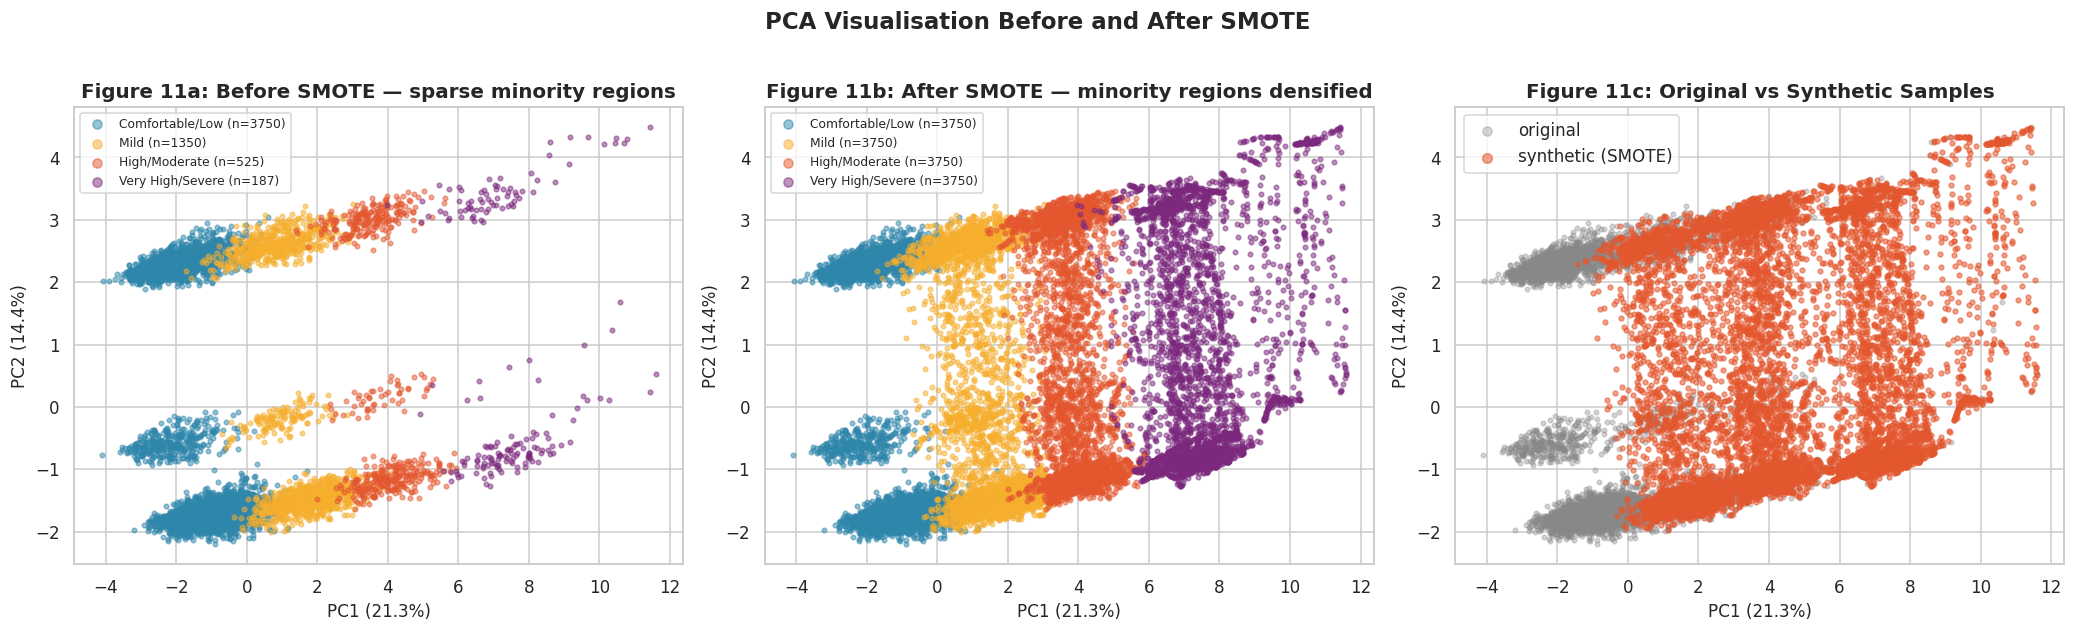

Synthetic points are interpolated inside the convex hull of real minority neighbours,
so no out-of-distribution region is created.


In [ ]:
sc_sm = StandardScaler().fit(Xi_tr)
pca_sm = PCA(n_components=2, random_state=RANDOM_STATE).fit(sc_sm.transform(Xi_tr))
P_before = pca_sm.transform(sc_sm.transform(Xi_tr))
P_after = pca_sm.transform(sc_sm.transform(Xi_tr_sm))
is_syn = np.zeros(len(yi_tr_sm), bool); is_syn[len(yi_tr):] = True

fig, ax = plt.subplots(1, 3, figsize=(19, 5.6))
for k in CLASSES:
    m = yi_tr == k
    ax[0].scatter(P_before[m, 0], P_before[m, 1], s=9, alpha=.5, c=PALETTE[k],
                  label=f'{CLASS_NAMES[k]} (n={m.sum()})')
ax[0].set_title('Figure 11a: Before SMOTE — sparse minority regions')
ax[0].legend(fontsize=8, markerscale=2)
for k in CLASSES:
    m = yi_tr_sm == k
    ax[1].scatter(P_after[m, 0], P_after[m, 1], s=9, alpha=.5, c=PALETTE[k],
                  label=f'{CLASS_NAMES[k]} (n={m.sum()})')
ax[1].set_title('Figure 11b: After SMOTE — minority regions densified')
ax[1].legend(fontsize=8, markerscale=2)
ax[2].scatter(P_after[~is_syn, 0], P_after[~is_syn, 1], s=9, alpha=.35, c='#888888', label='original')
ax[2].scatter(P_after[is_syn, 0], P_after[is_syn, 1], s=10, alpha=.55, c='#E4572E', label='synthetic (SMOTE)')
ax[2].set_title('Figure 11c: Original vs Synthetic Samples')
ax[2].legend(markerscale=2)
for a in ax:
    a.set_xlabel(f'PC1 ({pca_sm.explained_variance_ratio_[0]*100:.1f}%)')
    a.set_ylabel(f'PC2 ({pca_sm.explained_variance_ratio_[1]*100:.1f}%)')
plt.suptitle('PCA Visualisation Before and After SMOTE', fontsize=15, fontweight='bold', y=1.02)
save_show('fig11_pca_before_after_smote')
print('Synthetic points are interpolated inside the convex hull of real minority neighbours,')
print('so no out-of-distribution region is created.')

## Cell 11 — Step 7: Baseline Model

In [ ]:
def metric_block(y_true, y_pred, y_proba=None):
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    TP = np.diag(cm).astype(float)
    FP = cm.sum(0) - TP
    FN = cm.sum(1) - TP
    TN = cm.sum() - (TP + FP + FN)
    sens = np.divide(TP, TP+FN, out=np.zeros_like(TP), where=(TP+FN) > 0)
    spec = np.divide(TN, TN+FP, out=np.zeros_like(TN), where=(TN+FP) > 0)
    d = {'Accuracy': accuracy_score(y_true, y_pred),
         'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
         'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
         'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
         'F1 (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
         'F1 (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
         'MCC': matthews_corrcoef(y_true, y_pred),
         'Sensitivity (macro)': sens.mean(),
         'Specificity (macro)': spec.mean(),
         'Sensitivity (severe class)': sens[3],
         'Specificity (severe class)': spec[3]}
    if y_proba is not None:
        d['ROC-AUC (macro OvR)'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        d['Log Loss'] = log_loss(y_true, y_proba, labels=CLASSES)
    d['_sens_per_class'] = sens
    d['_spec_per_class'] = spec
    return d

baselines = {
    'Baseline: Most Frequent': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'Baseline: Stratified Random': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'Baseline: Uniform Random': DummyClassifier(strategy='uniform', random_state=RANDOM_STATE)}
base_rows = {}
for n, m in baselines.items():
    m.fit(X_tr, y_tr)
    p = m.predict(X_val)
    r = metric_block(y_val, p, m.predict_proba(X_val))
    base_rows[n] = {k: v for k, v in r.items() if not k.startswith('_')}
base_df = pd.DataFrame(base_rows).T
display(base_df.round(4))
BASELINE_ACC = base_df.loc['Baseline: Most Frequent', 'Accuracy']
BASELINE_F1 = base_df.loc['Baseline: Most Frequent', 'F1 (macro)']
print(f'Benchmark to beat: accuracy {BASELINE_ACC:.4f}, macro F1 {BASELINE_F1:.4f}')
print('Any candidate model must exceed this reference by a wide margin to be considered useful.')

,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),MCC,Sensitivity (macro),Specificity (macro),Sensitivity (severe class),Specificity (severe class),ROC-AUC (macro OvR),Log Loss
Baseline: Most Frequent,0.2500,0.2500,0.0625,0.2500,0.1000,0.1000,0.0000,0.2500,0.7500,0.000,1.0000,0.500,27.0327
Baseline: Stratified Random,0.2425,0.2425,0.2422,0.2425,0.2422,0.2422,-0.0100,0.2425,0.7475,0.271,0.7310,0.495,27.3031
Baseline: Uniform Random,0.2580,0.2580,0.2580,0.2580,0.2579,0.2579,0.0107,0.2580,0.7527,0.258,0.7533,0.500,1.3863


Benchmark to beat: accuracy 0.2500, macro F1 0.1000
Any candidate model must exceed this reference by a wide margin to be considered useful.


## Figure 12 — Model Training and Validation Workflow

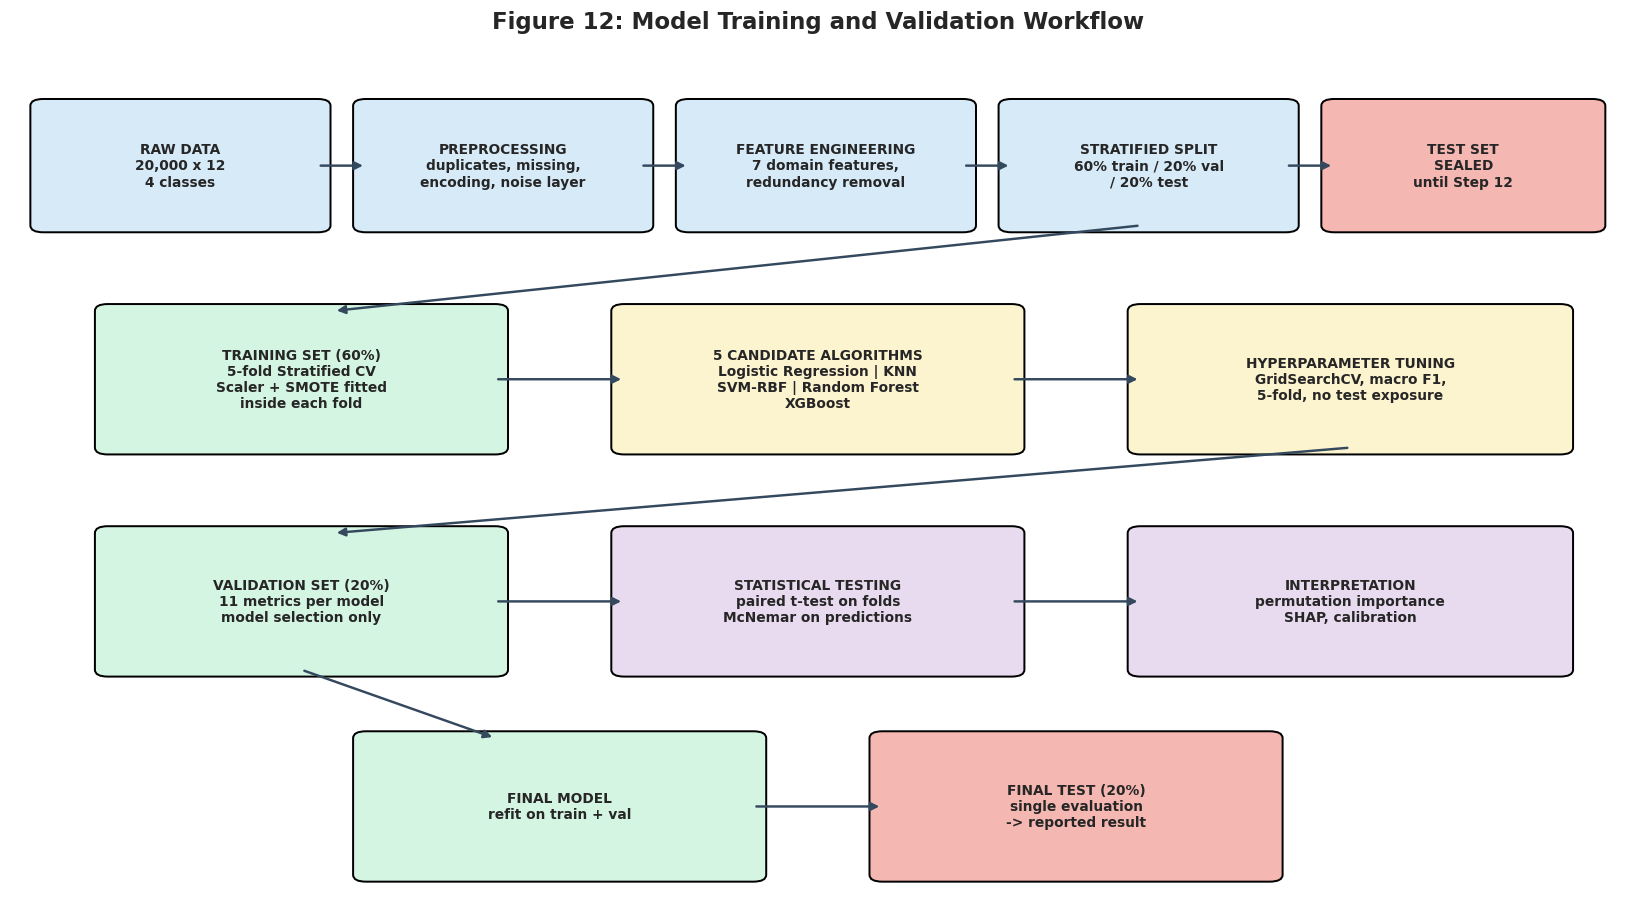

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8.5))
ax.axis('off')
boxes = [
    (0.02, 0.78, 0.17, 0.14, 'RAW DATA\n20,000 x 12\n4 classes', '#D6EAF8'),
    (0.22, 0.78, 0.17, 0.14, 'PREPROCESSING\nduplicates, missing,\nencoding, noise layer', '#D6EAF8'),
    (0.42, 0.78, 0.17, 0.14, 'FEATURE ENGINEERING\n7 domain features,\nredundancy removal', '#D6EAF8'),
    (0.62, 0.78, 0.17, 0.14, 'STRATIFIED SPLIT\n60% train / 20% val\n/ 20% test', '#D6EAF8'),
    (0.82, 0.78, 0.16, 0.14, 'TEST SET\nSEALED\nuntil Step 12', '#F5B7B1'),
    (0.06, 0.52, 0.24, 0.16, 'TRAINING SET (60%)\n5-fold Stratified CV\nScaler + SMOTE fitted\ninside each fold', '#D5F5E3'),
    (0.38, 0.52, 0.24, 0.16, '5 CANDIDATE ALGORITHMS\nLogistic Regression | KNN\nSVM-RBF | Random Forest\nXGBoost', '#FCF3CF'),
    (0.70, 0.52, 0.26, 0.16, 'HYPERPARAMETER TUNING\nGridSearchCV, macro F1,\n5-fold, no test exposure', '#FCF3CF'),
    (0.06, 0.26, 0.24, 0.16, 'VALIDATION SET (20%)\n11 metrics per model\nmodel selection only', '#D5F5E3'),
    (0.38, 0.52-0.26, 0.24, 0.16, 'STATISTICAL TESTING\npaired t-test on folds\nMcNemar on predictions', '#E8DAEF'),
    (0.70, 0.26, 0.26, 0.16, 'INTERPRETATION\npermutation importance\nSHAP, calibration', '#E8DAEF'),
    (0.22, 0.02, 0.24, 0.16, 'FINAL MODEL\nrefit on train + val', '#D5F5E3'),
    (0.54, 0.02, 0.24, 0.16, 'FINAL TEST (20%)\nsingle evaluation\n-> reported result', '#F5B7B1')]
for x, yb, w, h, t, c in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x, yb), w, h, boxstyle='round,pad=0.008',
                 fc=c, ec='black', lw=1.3))
    ax.text(x+w/2, yb+h/2, t, ha='center', va='center', fontsize=9, fontweight='bold')
arrows = [((0.19, 0.85), (0.22, 0.85)), ((0.39, 0.85), (0.42, 0.85)), ((0.59, 0.85), (0.62, 0.85)),
          ((0.79, 0.85), (0.82, 0.85)), ((0.70, 0.78), (0.20, 0.68)), ((0.30, 0.60), (0.38, 0.60)),
          ((0.62, 0.60), (0.70, 0.60)), ((0.83, 0.52), (0.20, 0.42)), ((0.30, 0.34), (0.38, 0.34)),
          ((0.62, 0.34), (0.70, 0.34)), ((0.18, 0.26), (0.30, 0.18)), ((0.46, 0.10), (0.54, 0.10))]
for (x1, y1), (x2, y2) in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', lw=1.6, color='#34495E'))
ax.set_title('Figure 12: Model Training and Validation Workflow', fontsize=15, fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(-0.02, 1)
save_show('fig12_training_validation_workflow')

## Cell 12 — Step 8: Model Training — Five Algorithm Families

In [ ]:
# One representative per algorithm family, so the comparison covers every modelling paradigm
# that suits tabular sensor data, without stacking several models of the same type.
MODELS = {
    'Logistic Regression': ('Linear / parametric', Pipeline([
        ('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, class_weight='balanced',
                                   random_state=RANDOM_STATE))])),
    'K-Nearest Neighbours': ('Instance-based / non-parametric', Pipeline([
        ('sc', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1))])),
    'SVM (RBF kernel)': ('Kernel / margin-based', Pipeline([
        ('sc', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                    class_weight='balanced', cache_size=800, random_state=RANDOM_STATE))])),
    'Random Forest': ('Bagging ensemble', Pipeline([
        ('sc', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample',
                                       random_state=RANDOM_STATE, n_jobs=-1))])),
    'XGBoost': ('Gradient-boosting ensemble', Pipeline([
        ('sc', StandardScaler()),
        ('clf', XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                              subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                              objective='multi:softprob', eval_metric='mlogloss',
                              tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1))]))}

fam = pd.DataFrame([(n, f, type(p.named_steps['clf']).__name__) for n, (f, p) in MODELS.items()],
                   columns=['Model', 'Algorithm family', 'Estimator'])
display(fam)

default_rows = {}
for n, (f, pipe) in MODELS.items():
    pipe.fit(X_tr, y_tr)
    pr = pipe.predict(X_val); pp = pipe.predict_proba(X_val)
    r = metric_block(y_val, pr, pp)
    default_rows[n] = {k: v for k, v in r.items() if not k.startswith('_')}
    print(f'{n:<22} val accuracy={r["Accuracy"]:.4f}  macro F1={r["F1 (macro)"]:.4f}')
default_df = pd.DataFrame(default_rows).T
print('\n--- Untuned (default hyperparameter) validation performance ---')
display(default_df.round(4))

,Model,Algorithm family,Estimator
0,Logistic Regression,Linear / parametric,LogisticRegression
1,K-Nearest Neighbours,Instance-based / non-parametric,KNeighborsClassifier
2,SVM (RBF kernel),Kernel / margin-based,SVC
3,Random Forest,Bagging ensemble,RandomForestClassifier
4,XGBoost,Gradient-boosting ensemble,XGBClassifier


Logistic Regression    val accuracy=0.9640  macro F1=0.9640
K-Nearest Neighbours   val accuracy=0.9567  macro F1=0.9568
SVM (RBF kernel)       val accuracy=0.9643  macro F1=0.9643
Random Forest          val accuracy=0.9610  macro F1=0.9610
XGBoost                val accuracy=0.9610  macro F1=0.9611

--- Untuned (default hyperparameter) validation performance ---


,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),MCC,Sensitivity (macro),Specificity (macro),Sensitivity (severe class),Specificity (severe class),ROC-AUC (macro OvR),Log Loss
Logistic Regression,0.9640,0.9640,0.9641,0.9640,0.9640,0.9640,0.9520,0.9640,0.9880,0.987,0.9950,0.9979,0.0919
K-Nearest Neighbours,0.9568,0.9568,0.9570,0.9568,0.9568,0.9568,0.9424,0.9568,0.9856,0.987,0.9953,0.9957,0.1824
SVM (RBF kernel),0.9642,0.9642,0.9644,0.9642,0.9643,0.9643,0.9524,0.9642,0.9881,0.989,0.9963,0.9977,0.0936
Random Forest,0.9610,0.9610,0.9611,0.9610,0.9610,0.9610,0.9480,0.9610,0.9870,0.990,0.9947,0.9967,0.1593
XGBoost,0.9610,0.9610,0.9612,0.9610,0.9611,0.9611,0.9480,0.9610,0.9870,0.988,0.9960,0.9972,0.1114


## Figure 13 — Cross-Validation Performance Comparison

Logistic Regression    CV accuracy=0.9628+/-0.0026  CV macro F1=0.9629+/-0.0026
K-Nearest Neighbours   CV accuracy=0.9530+/-0.0036  CV macro F1=0.9531+/-0.0036
SVM (RBF kernel)       CV accuracy=0.9608+/-0.0023  CV macro F1=0.9609+/-0.0022
Random Forest          CV accuracy=0.9537+/-0.0050  CV macro F1=0.9537+/-0.0050
XGBoost                CV accuracy=0.9545+/-0.0050  CV macro F1=0.9545+/-0.0050


,Model,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean,cv_f1_std,cv_balacc_mean,cv_balacc_std
0,Logistic Regression,0.9628,0.0026,0.9629,0.0026,0.9628,0.0026
1,K-Nearest Neighbours,0.9530,0.0036,0.9531,0.0036,0.9530,0.0036
2,SVM (RBF kernel),0.9608,0.0023,0.9609,0.0022,0.9608,0.0023
3,Random Forest,0.9537,0.0050,0.9537,0.0050,0.9537,0.0050
4,XGBoost,0.9545,0.0050,0.9545,0.0050,0.9545,0.0050


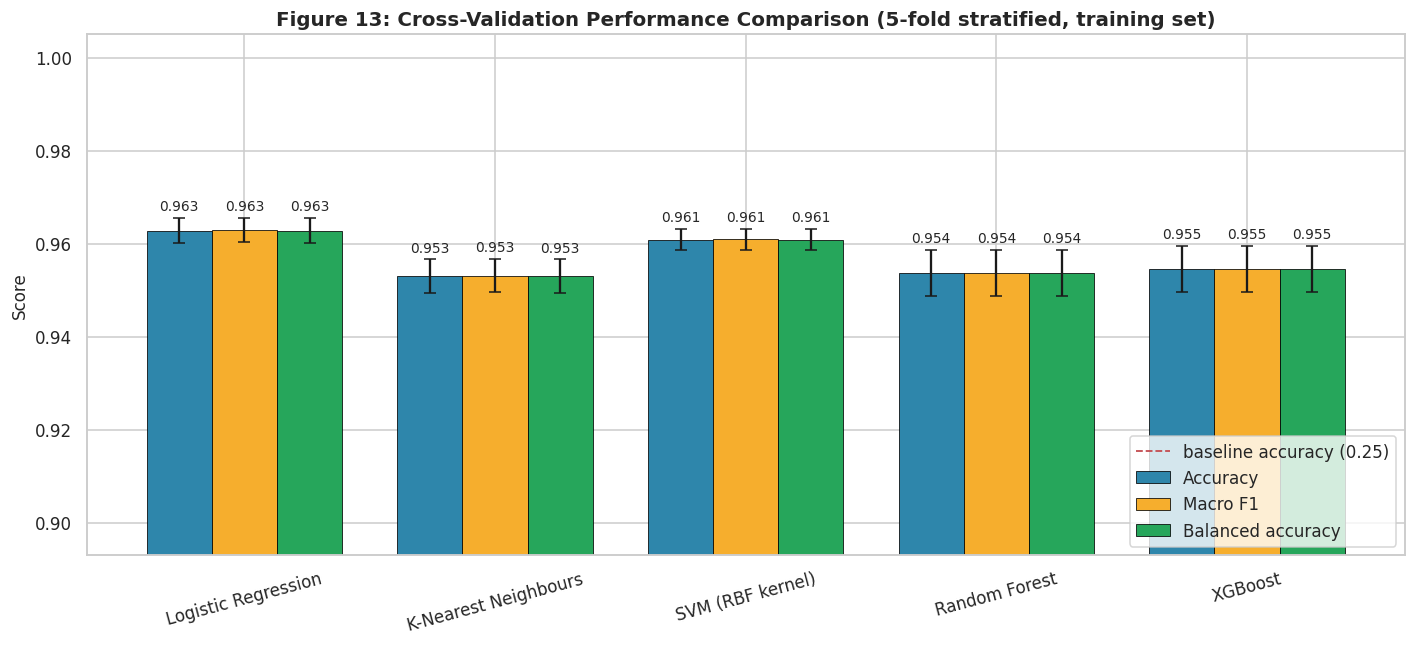

In [ ]:
cv_scores, cv_summary = {}, []
for n, (f, pipe) in MODELS.items():
    acc = cross_val_score(pipe, X_tr, y_tr, cv=CV, scoring='accuracy', n_jobs=-1)
    f1m = cross_val_score(pipe, X_tr, y_tr, cv=CV, scoring='f1_macro', n_jobs=-1)
    bal = cross_val_score(pipe, X_tr, y_tr, cv=CV, scoring='balanced_accuracy', n_jobs=-1)
    cv_scores[n] = {'accuracy': acc, 'f1_macro': f1m, 'balanced_accuracy': bal}
    cv_summary.append([n, acc.mean(), acc.std(), f1m.mean(), f1m.std(), bal.mean(), bal.std()])
    print(f'{n:<22} CV accuracy={acc.mean():.4f}+/-{acc.std():.4f}  CV macro F1={f1m.mean():.4f}+/-{f1m.std():.4f}')
cv_df = pd.DataFrame(cv_summary, columns=['Model', 'cv_accuracy_mean', 'cv_accuracy_std',
                                          'cv_f1_mean', 'cv_f1_std', 'cv_balacc_mean', 'cv_balacc_std'])
display(cv_df.round(4))

names = cv_df.Model.tolist(); xp = np.arange(len(names)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(xp-w, cv_df.cv_accuracy_mean, w, yerr=cv_df.cv_accuracy_std, capsize=4,
       label='Accuracy', color='#2E86AB', edgecolor='black', linewidth=.5)
ax.bar(xp, cv_df.cv_f1_mean, w, yerr=cv_df.cv_f1_std, capsize=4,
       label='Macro F1', color='#F6AE2D', edgecolor='black', linewidth=.5)
ax.bar(xp+w, cv_df.cv_balacc_mean, w, yerr=cv_df.cv_balacc_std, capsize=4,
       label='Balanced accuracy', color='#26A65B', edgecolor='black', linewidth=.5)
ax.set_xticks(xp); ax.set_xticklabels(names, rotation=15)
lo = min(cv_df[['cv_accuracy_mean', 'cv_f1_mean', 'cv_balacc_mean']].min())
ax.set_ylim(max(0, lo-0.06), 1.005)
ax.axhline(BASELINE_ACC, ls='--', c='r', lw=1.2, label=f'baseline accuracy ({BASELINE_ACC:.2f})')
annotate_bars(ax, fmt='%.3f')
ax.set_ylabel('Score'); ax.legend(loc='lower right')
ax.set_title('Figure 13: Cross-Validation Performance Comparison (5-fold stratified, training set)')
save_show('fig13_cv_performance_comparison')

## Figure 14 — Cross-Validation Score Distribution

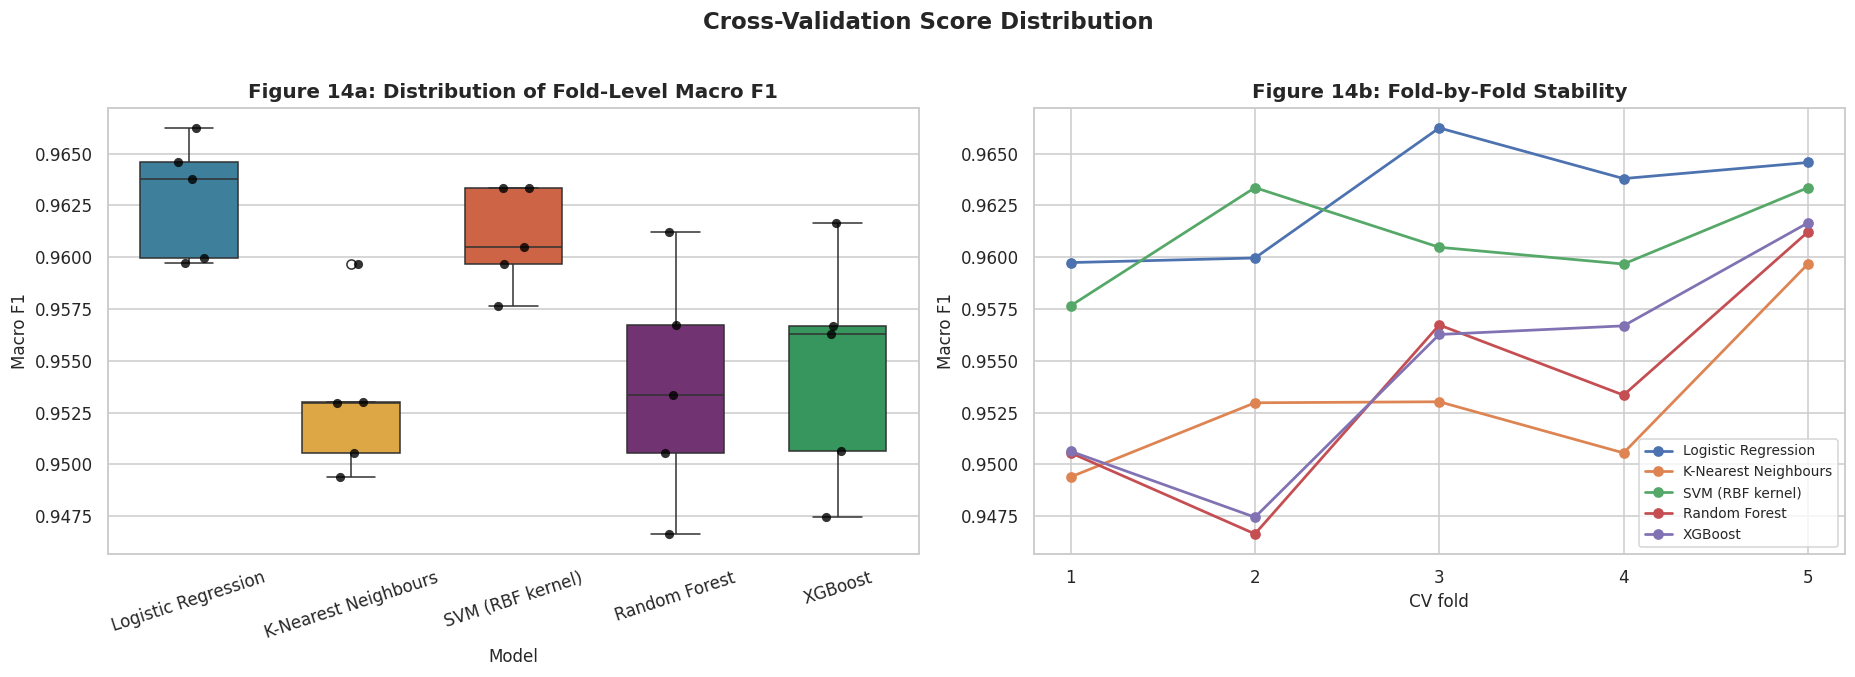

                        mean     std     min     max
Model                                               
K-Nearest Neighbours  0.9531  0.0040  0.9494  0.9597
Logistic Regression   0.9629  0.0029  0.9597  0.9662
Random Forest         0.9537  0.0056  0.9466  0.9612
SVM (RBF kernel)      0.9609  0.0025  0.9577  0.9634
XGBoost               0.9545  0.0056  0.9474  0.9617

Lower spread across folds indicates a more stable learner on this dataset.


In [ ]:
long = pd.DataFrame([(n, i+1, v) for n, d in cv_scores.items() for i, v in enumerate(d['f1_macro'])],
                    columns=['Model', 'Fold', 'Macro F1'])
fig, ax = plt.subplots(1, 2, figsize=(17, 6))
sns.boxplot(data=long, x='Model', y='Macro F1', ax=ax[0], palette=PALETTE, width=.6)
sns.stripplot(data=long, x='Model', y='Macro F1', ax=ax[0], color='black', size=6, alpha=.8)
ax[0].set_title('Figure 14a: Distribution of Fold-Level Macro F1')
ax[0].tick_params(axis='x', rotation=18)
for n, d in cv_scores.items():
    ax[1].plot(range(1, 6), d['f1_macro'], 'o-', lw=1.8, ms=6, label=n)
ax[1].set_xticks(range(1, 6)); ax[1].set_xlabel('CV fold'); ax[1].set_ylabel('Macro F1')
ax[1].set_title('Figure 14b: Fold-by-Fold Stability')
ax[1].legend(fontsize=9, loc='lower right')
plt.suptitle('Cross-Validation Score Distribution', fontsize=15, fontweight='bold', y=1.02)
save_show('fig14_cv_score_distribution')
print(long.groupby('Model')['Macro F1'].agg(['mean', 'std', 'min', 'max']).round(4))
print('\nLower spread across folds indicates a more stable learner on this dataset.')

## Figure 15 — Hyperparameter Tuning Results

Logistic Regression    best CV F1=0.9602 | {'clf__C': 1}
K-Nearest Neighbours   best CV F1=0.9511 | {'clf__n_neighbors': 21, 'clf__weights': 'uniform'}
SVM (RBF kernel)       best CV F1=0.9579 | {'clf__C': 1, 'clf__gamma': 0.1}
Random Forest          best CV F1=0.9481 | {'clf__max_depth': 14, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
XGBoost                best CV F1=0.9497 | {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 300}


,Model,best_cv_f1,val_f1_default,val_f1_tuned,improvement,configs_tested,best_params
0,Logistic Regression,0.9602,0.9640,0.9640,0.0000,5,{'clf__C': 1}
1,K-Nearest Neighbours,0.9511,0.9568,0.9576,0.0007,8,"{'clf__n_neighbors': 21, 'clf__weights': 'uniform'}"
2,SVM (RBF kernel),0.9579,0.9643,0.9643,-0.0000,4,"{'clf__C': 1, 'clf__gamma': 0.1}"
3,Random Forest,0.9481,0.9610,0.9578,-0.0032,4,"{'clf__max_depth': 14, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}"
4,XGBoost,0.9497,0.9611,0.9628,0.0017,6,"{'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 300}"


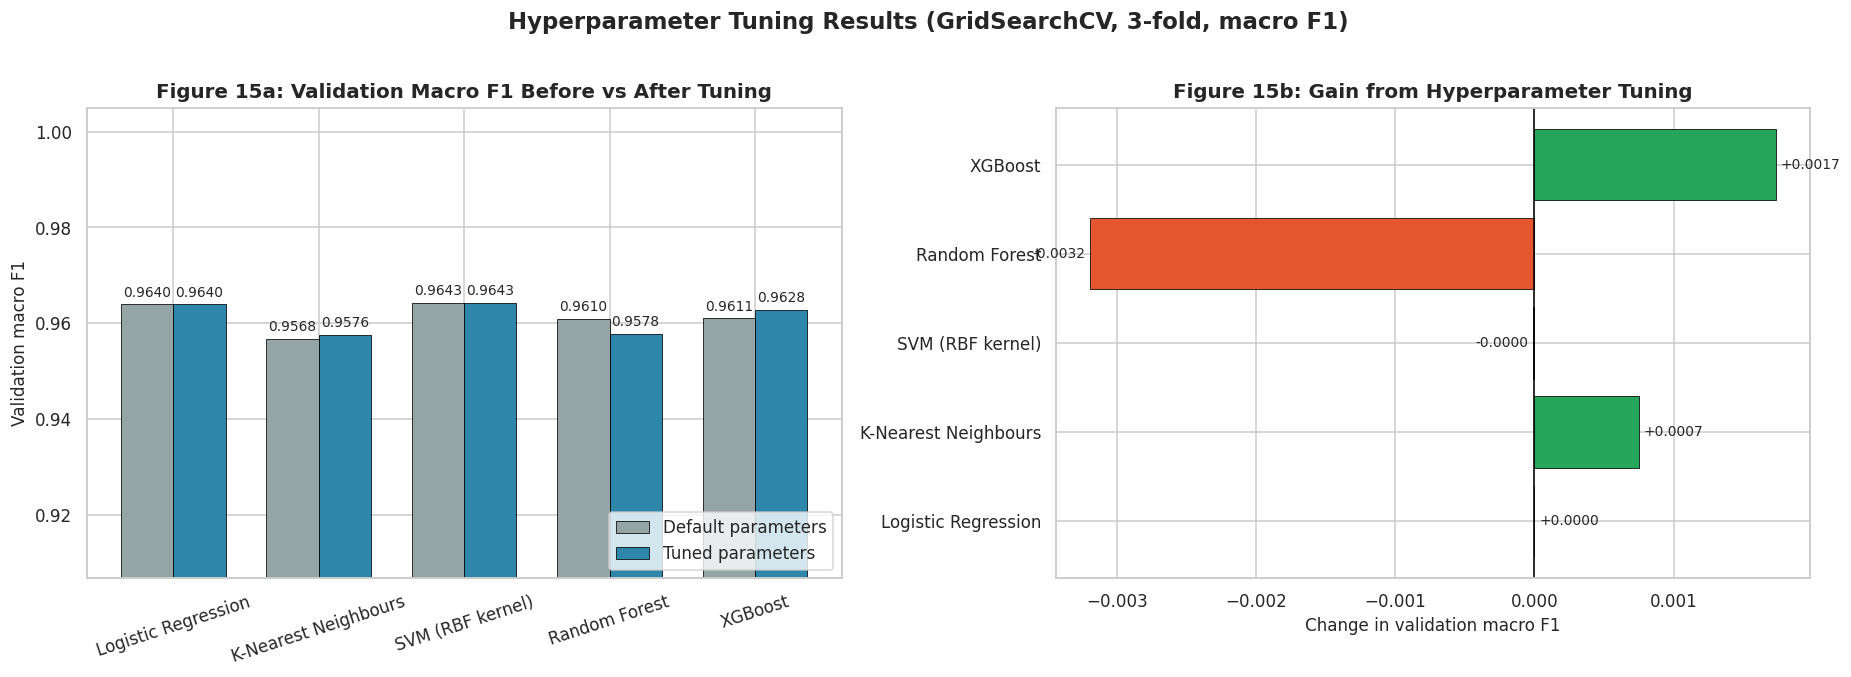

In [ ]:
# Tuning uses a stratified subsample of the training set to keep Colab runtime practical;
# the selected configuration is then refitted on the full training set.
TUNE_N = min(5000, len(X_tr))
if TUNE_N < len(X_tr):
    Xs, _, ys, _ = train_test_split(X_tr, y_tr, train_size=TUNE_N, stratify=y_tr, random_state=RANDOM_STATE)
else:
    Xs, ys = X_tr, y_tr

GRIDS = {
    'Logistic Regression': {'clf__C': [0.01, 0.1, 1, 10, 100]},
    'K-Nearest Neighbours': {'clf__n_neighbors': [5, 11, 21, 35], 'clf__weights': ['uniform', 'distance']},
    'SVM (RBF kernel)': {'clf__C': [1, 10], 'clf__gamma': ['scale', 0.1]},
    'Random Forest': {'clf__n_estimators': [300], 'clf__max_depth': [None, 14],
                      'clf__min_samples_leaf': [1, 3]},
    'XGBoost': {'clf__n_estimators': [300], 'clf__max_depth': [3, 5, 8],
                'clf__learning_rate': [0.05, 0.15]}}

TUNED, tune_rows = {}, []
for n, (f, pipe) in MODELS.items():
    gs = GridSearchCV(pipe, GRIDS[n], scoring='f1_macro', cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                      n_jobs=-1, refit=True, verbose=0)
    gs.fit(Xs, ys)
    best = gs.best_estimator_.fit(X_tr, y_tr)
    TUNED[n] = best
    dflt = default_df.loc[n, 'F1 (macro)']
    tuned_val = f1_score(y_val, best.predict(X_val), average='macro')
    tune_rows.append([n, gs.best_score_, dflt, tuned_val, tuned_val-dflt,
                      len(gs.cv_results_['params']), str(gs.best_params_)])
    print(f'{n:<22} best CV F1={gs.best_score_:.4f} | {gs.best_params_}')
tune_df = pd.DataFrame(tune_rows, columns=['Model', 'best_cv_f1', 'val_f1_default', 'val_f1_tuned',
                                           'improvement', 'configs_tested', 'best_params'])
display(tune_df.round(4))

fig, ax = plt.subplots(1, 2, figsize=(17, 6))
xp = np.arange(len(tune_df)); w = 0.36
ax[0].bar(xp-w/2, tune_df.val_f1_default, w, label='Default parameters', color='#95A5A6', edgecolor='black', linewidth=.5)
ax[0].bar(xp+w/2, tune_df.val_f1_tuned, w, label='Tuned parameters', color='#2E86AB', edgecolor='black', linewidth=.5)
ax[0].set_xticks(xp); ax[0].set_xticklabels(tune_df.Model, rotation=18)
ax[0].set_ylim(max(0, tune_df[['val_f1_default', 'val_f1_tuned']].min().min()-0.05), 1.005)
annotate_bars(ax[0], fmt='%.4f')
ax[0].set_ylabel('Validation macro F1'); ax[0].legend(loc='lower right')
ax[0].set_title('Figure 15a: Validation Macro F1 Before vs After Tuning')
cols = ['#26A65B' if v >= 0 else '#E4572E' for v in tune_df.improvement]
b = ax[1].barh(tune_df.Model, tune_df.improvement, color=cols, edgecolor='black', linewidth=.5)
ax[1].bar_label(b, fmt='%+.4f', padding=3, fontsize=9)
ax[1].axvline(0, c='black', lw=1)
ax[1].set_xlabel('Change in validation macro F1')
ax[1].set_title('Figure 15b: Gain from Hyperparameter Tuning')
plt.suptitle('Hyperparameter Tuning Results (GridSearchCV, 3-fold, macro F1)',
             fontsize=15, fontweight='bold', y=1.02)
save_show('fig15_hyperparameter_tuning')

## Cell 13 — Step 10: Model Evaluation — Consolidated Metric Table

In [ ]:
results, per_class_store, proba_store, pred_store = {}, {}, {}, {}
for n, m in TUNED.items():
    pr = m.predict(X_val); pp = m.predict_proba(X_val)
    r = metric_block(y_val, pr, pp)
    per_class_store[n] = (r.pop('_sens_per_class'), r.pop('_spec_per_class'))
    results[n] = r; proba_store[n] = pp; pred_store[n] = pr

res_df = pd.DataFrame(results).T
res_df.insert(0, 'CV macro F1', [cv_df.set_index('Model').loc[n, 'cv_f1_mean'] for n in res_df.index])
res_df = res_df.sort_values('F1 (macro)', ascending=False)
display(res_df.round(4))

BEST_NAME = res_df.index[0]
BEST_MODEL = TUNED[BEST_NAME]
print(f'\nSelected model on validation macro F1: {BEST_NAME}')
print(f'Spread across the five algorithms: accuracy {res_df.Accuracy.min():.4f} to {res_df.Accuracy.max():.4f} '
      f'(range {100*(res_df.Accuracy.max()-res_df.Accuracy.min()):.2f} pp), '
      f'macro F1 {res_df["F1 (macro)"].min():.4f} to {res_df["F1 (macro)"].max():.4f}')
print('\n--- Classification report of the selected model (validation set) ---')
print(classification_report(y_val, pred_store[BEST_NAME], target_names=CLASS_NAMES, digits=4))

,CV macro F1,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),MCC,Sensitivity (macro),Specificity (macro),Sensitivity (severe class),Specificity (severe class),ROC-AUC (macro OvR),Log Loss
SVM (RBF kernel),0.9609,0.9642,0.9642,0.9644,0.9642,0.9643,0.9643,0.9523,0.9642,0.9881,0.986,0.9957,0.9975,0.0975
Logistic Regression,0.9629,0.9640,0.9640,0.9641,0.9640,0.9640,0.9640,0.9520,0.9640,0.9880,0.987,0.9950,0.9979,0.0919
XGBoost,0.9545,0.9628,0.9627,0.9630,0.9627,0.9628,0.9628,0.9504,0.9627,0.9876,0.988,0.9953,0.9973,0.1075
Random Forest,0.9537,0.9578,0.9578,0.9580,0.9578,0.9578,0.9578,0.9437,0.9578,0.9859,0.989,0.9943,0.9967,0.1557
K-Nearest Neighbours,0.9531,0.9575,0.9575,0.9577,0.9575,0.9576,0.9576,0.9434,0.9575,0.9858,0.985,0.9947,0.9964,0.1619



Selected model on validation macro F1: SVM (RBF kernel)
Spread across the five algorithms: accuracy 0.9575 to 0.9643 (range 0.68 pp), macro F1 0.9576 to 0.9643

--- Classification report of the selected model (validation set) ---
                  precision    recall  f1-score   support

 Comfortable/Low     0.9799    0.9750    0.9774      1000
            Mild     0.9350    0.9500    0.9425      1000
   High/Moderate     0.9556    0.9460    0.9508      1000
Very High/Severe     0.9870    0.9860    0.9865      1000

        accuracy                         0.9643      4000
       macro avg     0.9644    0.9642    0.9643      4000
    weighted avg     0.9644    0.9643    0.9643      4000



## Figures 16-23 — Individual Metric Comparison Bar Graphs

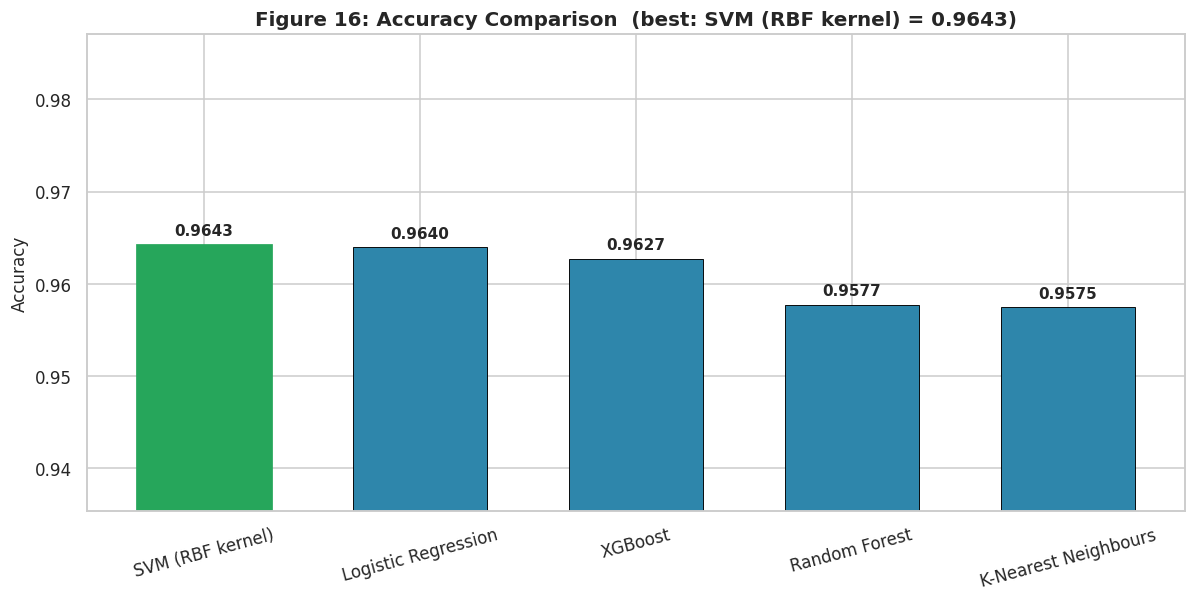

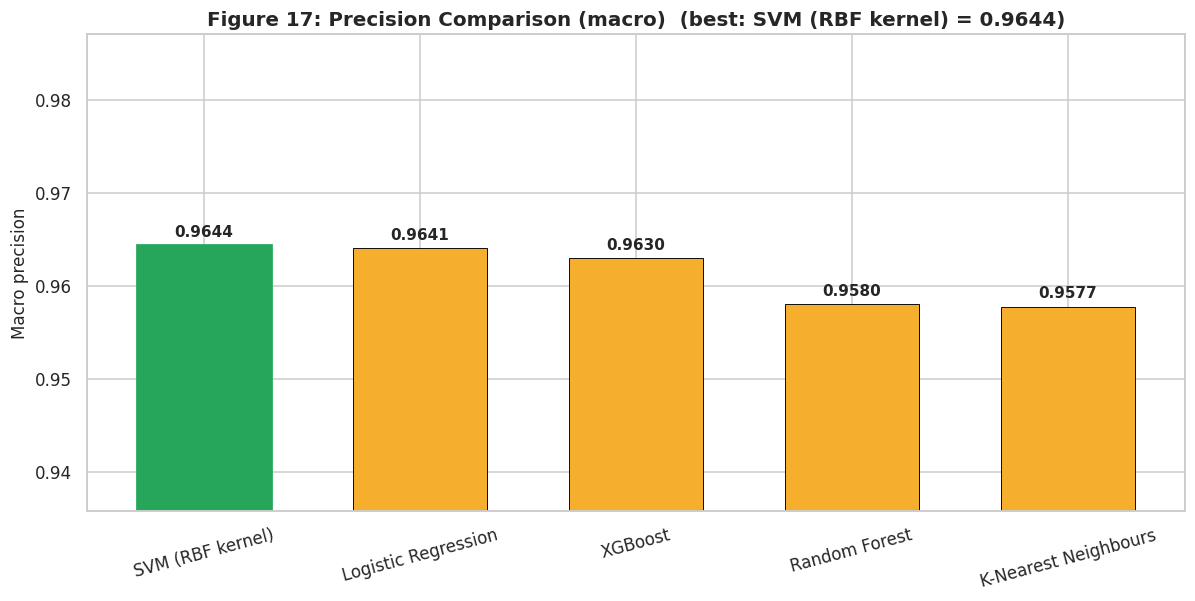

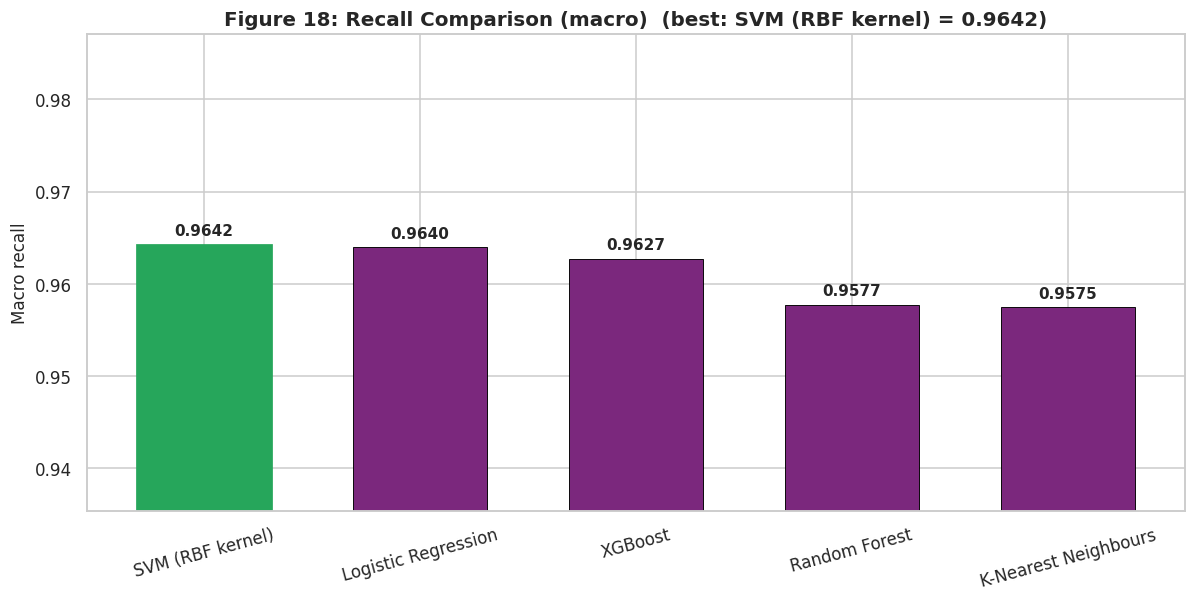

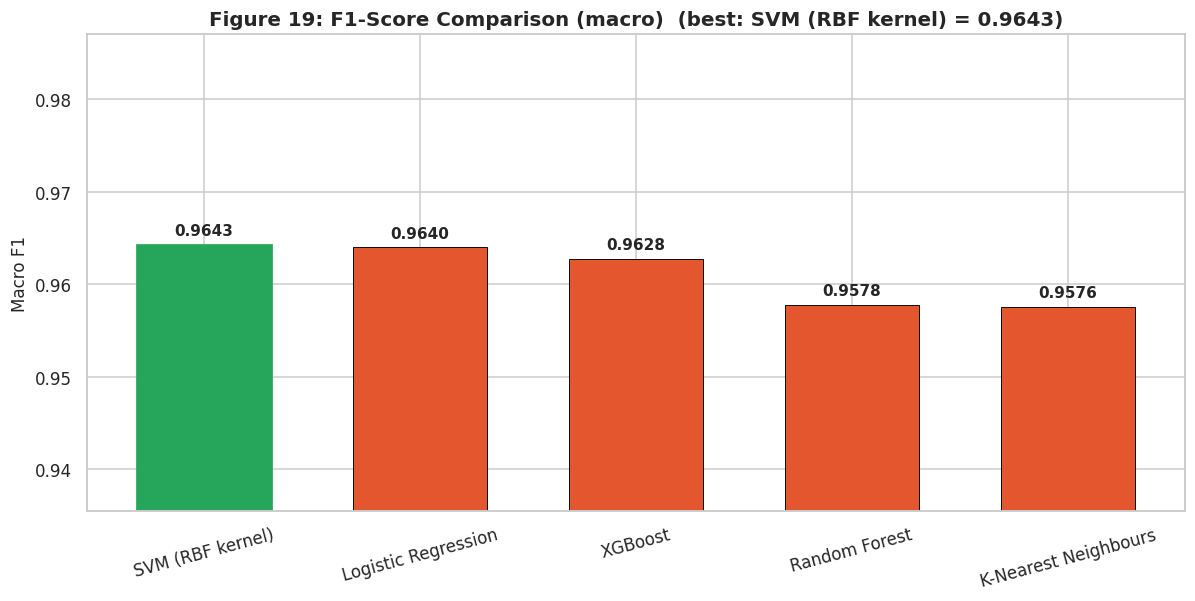

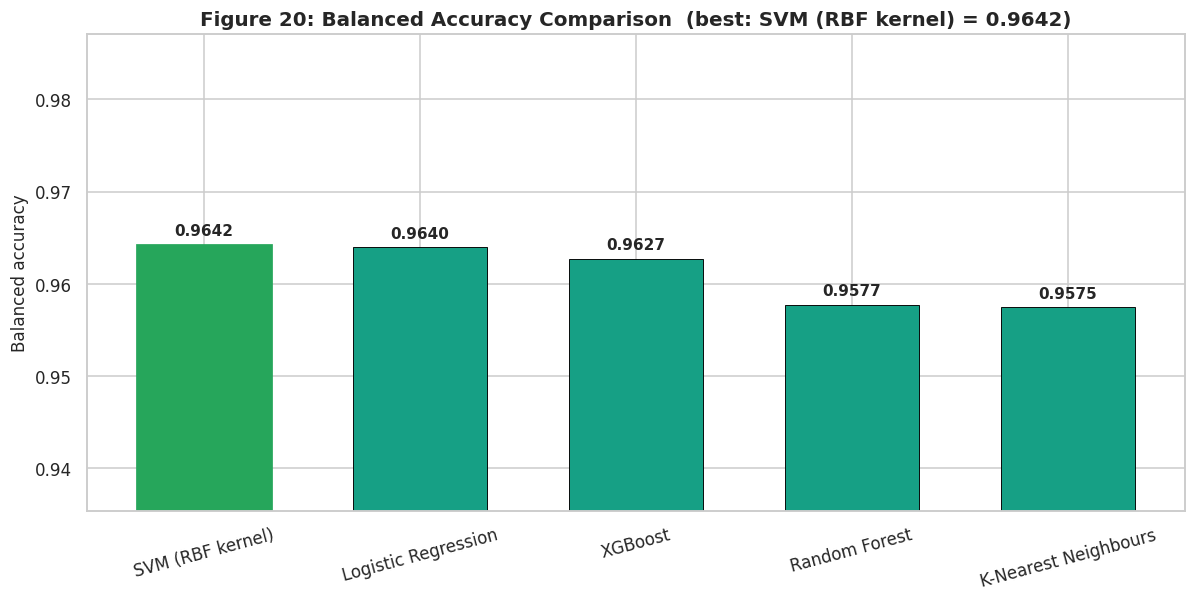

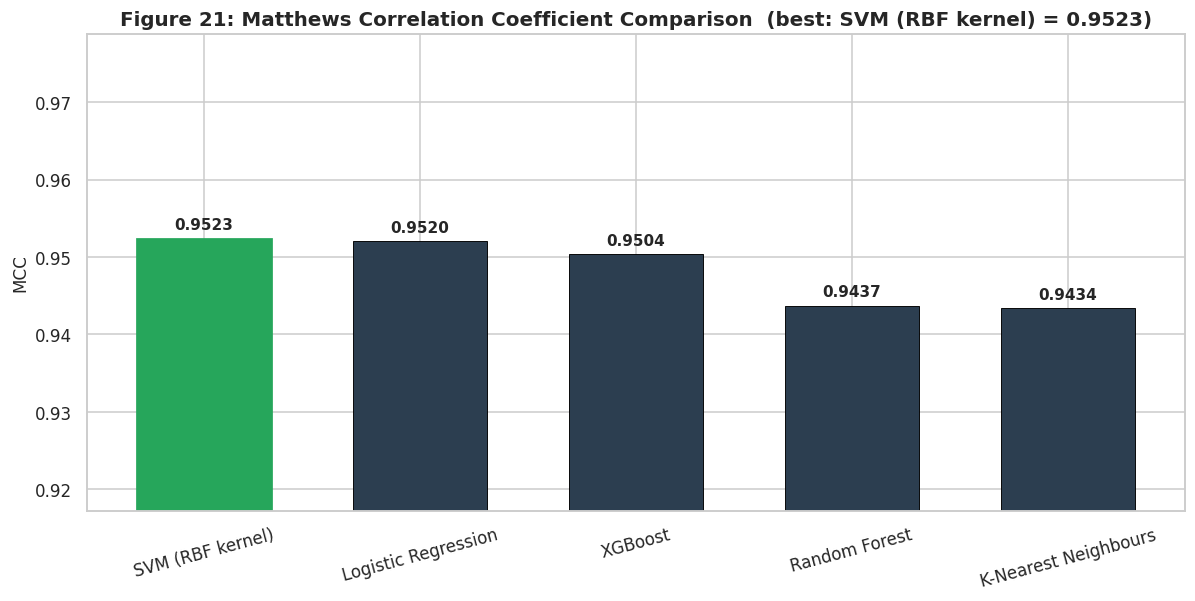

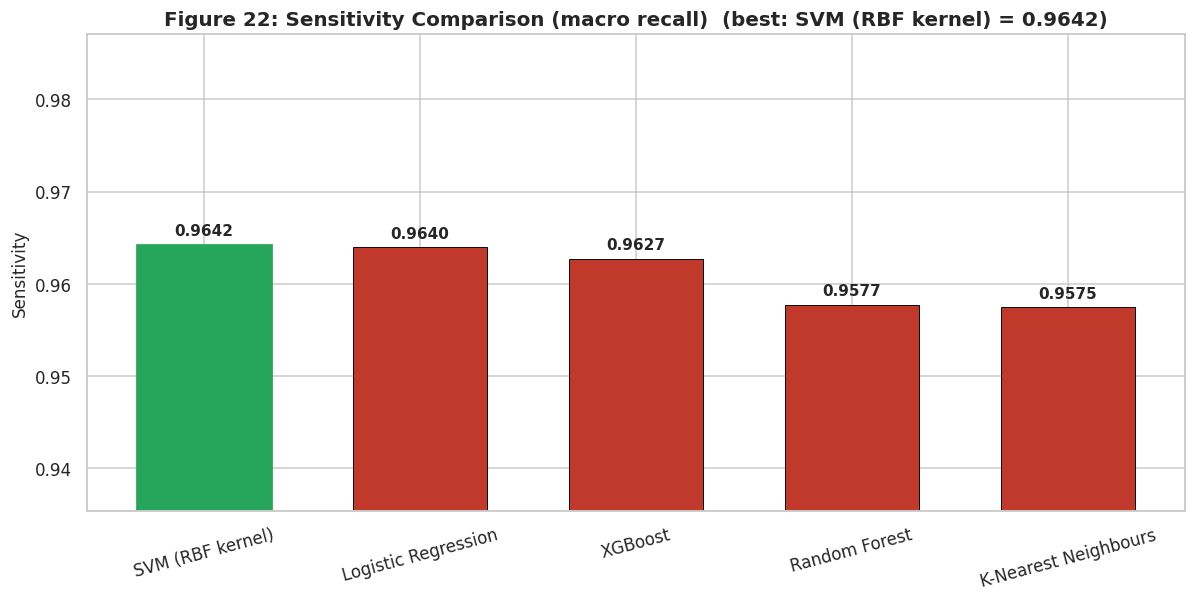

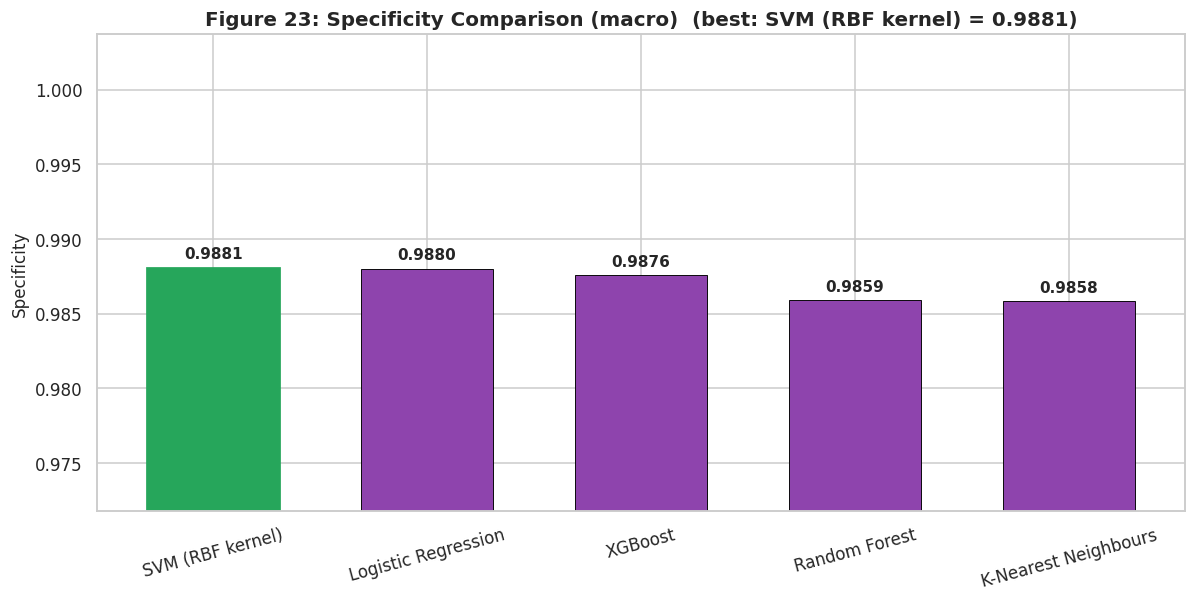

In [ ]:
ORDER = list(res_df.index)
def metric_bar(col, fignum, title, cmapcol, ylab=None, ref=None):
    vals = res_df.loc[ORDER, col].values
    plt.figure(figsize=(11, 5.6))
    bars = plt.bar(ORDER, vals, color=cmapcol, edgecolor='black', linewidth=.6, width=.62)
    best_i = int(np.argmax(vals))
    bars[best_i].set_color('#26A65B'); bars[best_i].set_linewidth(1.8)
    plt.bar_label(bars, fmt='%.4f', padding=4, fontweight='bold', fontsize=10)
    lo = vals.min()
    plt.ylim(max(0, lo-(vals.max()-lo)*1.8-0.01), min(1.02, vals.max()+(vals.max()-lo)*1.6+0.012))
    if ref is not None:
        plt.axhline(ref, ls='--', c='r', lw=1.1, label=f'baseline = {ref:.3f}')
        plt.legend(loc='lower right')
    plt.ylabel(ylab or col); plt.xticks(rotation=15)
    plt.title(f'Figure {fignum}: {title}  (best: {ORDER[best_i]} = {vals[best_i]:.4f})')
    save_show(f'fig{fignum}_{col.split()[0].lower()}_comparison')

metric_bar('Accuracy', 16, 'Accuracy Comparison', '#2E86AB', 'Accuracy')
metric_bar('Precision (macro)', 17, 'Precision Comparison (macro)', '#F6AE2D', 'Macro precision')
metric_bar('Recall (macro)', 18, 'Recall Comparison (macro)', '#7B287D', 'Macro recall')
metric_bar('F1 (macro)', 19, 'F1-Score Comparison (macro)', '#E4572E', 'Macro F1')
metric_bar('Balanced Accuracy', 20, 'Balanced Accuracy Comparison', '#16A085', 'Balanced accuracy')
metric_bar('MCC', 21, 'Matthews Correlation Coefficient Comparison', '#2C3E50', 'MCC')
metric_bar('Sensitivity (macro)', 22, 'Sensitivity Comparison (macro recall)', '#C0392B', 'Sensitivity')
metric_bar('Specificity (macro)', 23, 'Specificity Comparison (macro)', '#8E44AD', 'Specificity')

## Figure 24 — Sensitivity vs Specificity Comparison

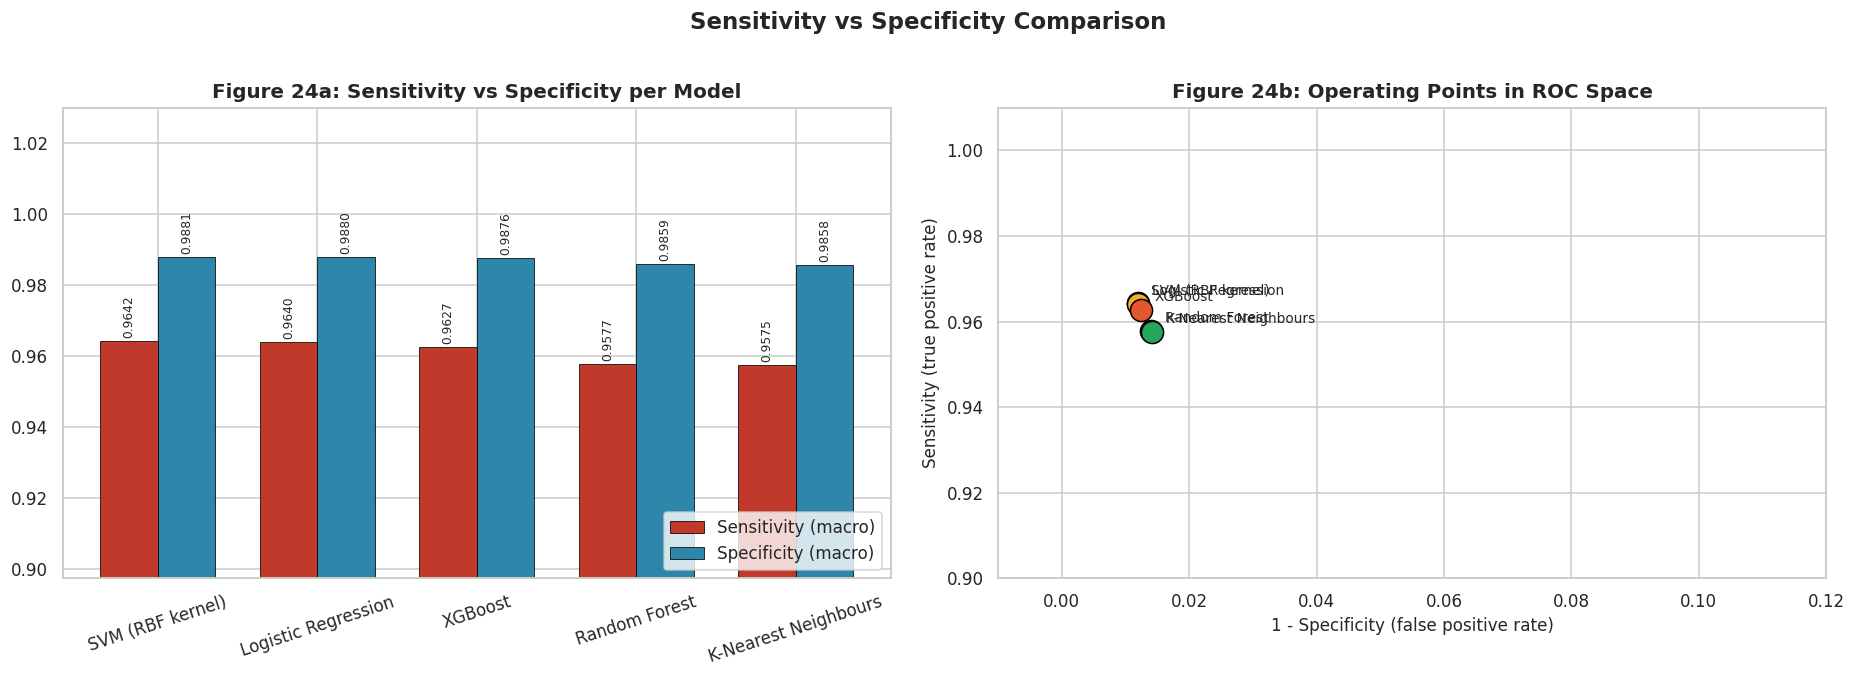

,Model,Sensitivity,Specificity,Balanced (Youden J)
0,SVM (RBF kernel),0.9642,0.9881,0.9523
1,Logistic Regression,0.9640,0.9880,0.9520
2,XGBoost,0.9627,0.9876,0.9503
3,Random Forest,0.9578,0.9859,0.9437
4,K-Nearest Neighbours,0.9575,0.9858,0.9433


In [ ]:
sv = res_df.loc[ORDER, 'Sensitivity (macro)'].values
sp = res_df.loc[ORDER, 'Specificity (macro)'].values
fig, ax = plt.subplots(1, 2, figsize=(17, 6))
xp = np.arange(len(ORDER)); w = 0.36
b1 = ax[0].bar(xp-w/2, sv, w, label='Sensitivity (macro)', color='#C0392B', edgecolor='black', linewidth=.5)
b2 = ax[0].bar(xp+w/2, sp, w, label='Specificity (macro)', color='#2E86AB', edgecolor='black', linewidth=.5)
ax[0].bar_label(b1, fmt='%.4f', padding=2, fontsize=8, rotation=90)
ax[0].bar_label(b2, fmt='%.4f', padding=2, fontsize=8, rotation=90)
ax[0].set_xticks(xp); ax[0].set_xticklabels(ORDER, rotation=18)
ax[0].set_ylim(min(sv.min(), sp.min())-0.06, 1.03); ax[0].legend(loc='lower right')
ax[0].set_title('Figure 24a: Sensitivity vs Specificity per Model')
for i, n in enumerate(ORDER):
    ax[1].scatter(1-sp[i], sv[i], s=210, c=PALETTE[i % 5], edgecolor='black', zorder=3, label=n)
    ax[1].annotate(n, (1-sp[i], sv[i]), textcoords='offset points', xytext=(9, 6), fontsize=9)
ax[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=.5)
ax[1].set_xlabel('1 - Specificity (false positive rate)'); ax[1].set_ylabel('Sensitivity (true positive rate)')
ax[1].set_title('Figure 24b: Operating Points in ROC Space')
ax[1].set_xlim(-0.01, max(0.12, (1-sp).max()*1.5)); ax[1].set_ylim(min(sv.min()-0.05, 0.9), 1.01)
plt.suptitle('Sensitivity vs Specificity Comparison', fontsize=15, fontweight='bold', y=1.02)
save_show('fig24_sensitivity_vs_specificity')

ss = pd.DataFrame({'Model': ORDER, 'Sensitivity': sv, 'Specificity': sp})
ss['Balanced (Youden J)'] = (ss.Sensitivity + ss.Specificity - 1).round(4)
display(ss.round(4))

## Figure 25 — Confusion Matrix, Selected Model

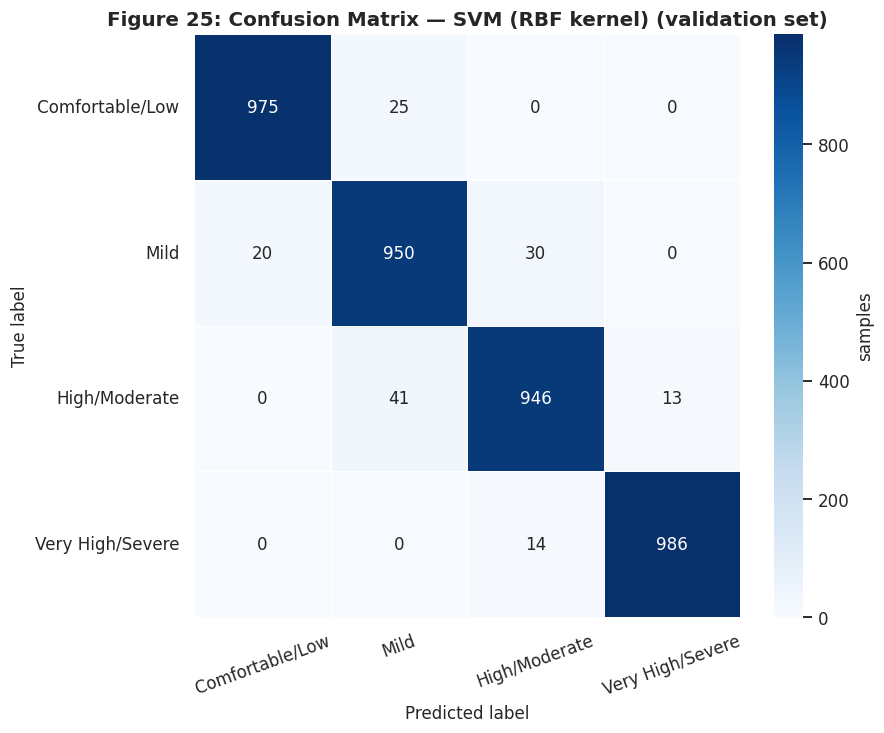

Correct 3857 / 4000  |  errors 143 (3.58%)
Largest confusions (true -> predicted):
  High/Moderate      -> Mild               41
  Mild               -> High/Moderate      30
  Comfortable/Low    -> Mild               25
  Mild               -> Comfortable/Low    20
  Very High/Severe   -> High/Moderate      14
Errors concentrate between adjacent severity levels, which is the least costly error type.


In [ ]:
cm_best = confusion_matrix(y_val, pred_store[BEST_NAME], labels=CLASSES)
plt.figure(figsize=(8.2, 6.8))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'samples'},
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=.6, linecolor='white')
plt.xlabel('Predicted label'); plt.ylabel('True label')
plt.title(f'Figure 25: Confusion Matrix — {BEST_NAME} (validation set)')
plt.xticks(rotation=20); plt.yticks(rotation=0)
save_show('fig25_confusion_matrix_final')

err = cm_best.sum() - np.trace(cm_best)
print(f'Correct {np.trace(cm_best)} / {cm_best.sum()}  |  errors {err} ({100*err/cm_best.sum():.2f}%)')
off = [(CLASS_NAMES[i], CLASS_NAMES[j], cm_best[i, j]) for i in range(4) for j in range(4)
       if i != j and cm_best[i, j] > 0]
off = sorted(off, key=lambda t: -t[2])[:5]
print('Largest confusions (true -> predicted):')
for t, p, c in off:
    print(f'  {t:<18} -> {p:<18} {c}')
print('Errors concentrate between adjacent severity levels, which is the least costly error type.')

## Figure 26 — Normalised Confusion Matrix

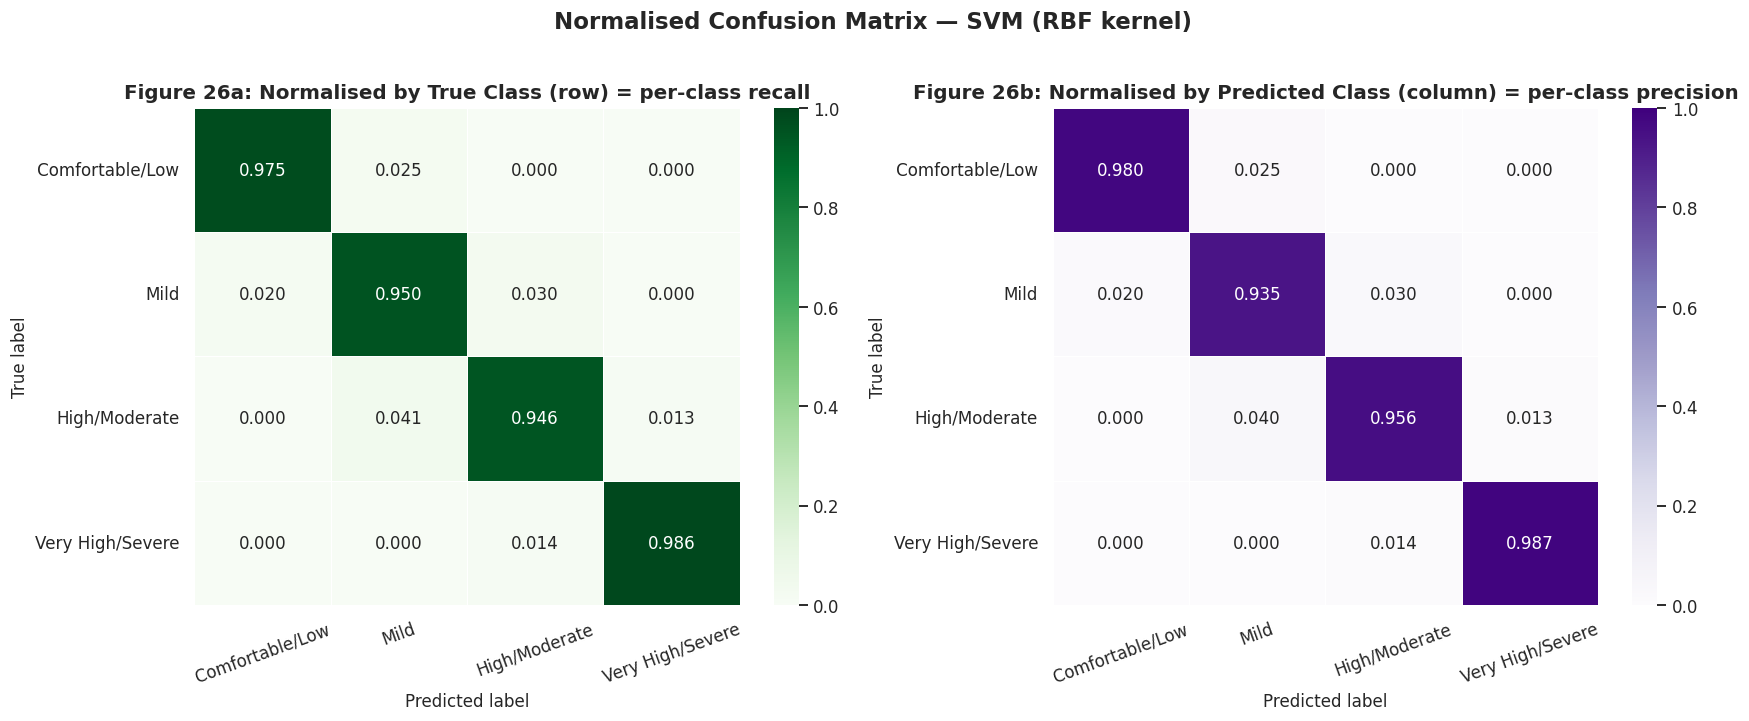

In [ ]:
cm_true = confusion_matrix(y_val, pred_store[BEST_NAME], labels=CLASSES, normalize='true')
cm_pred = confusion_matrix(y_val, pred_store[BEST_NAME], labels=CLASSES, normalize='pred')
fig, ax = plt.subplots(1, 2, figsize=(16, 6.4))
sns.heatmap(cm_true, annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1, ax=ax[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=.6)
ax[0].set_title('Figure 26a: Normalised by True Class (row) = per-class recall')
sns.heatmap(cm_pred, annot=True, fmt='.3f', cmap='Purples', vmin=0, vmax=1, ax=ax[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=.6)
ax[1].set_title('Figure 26b: Normalised by Predicted Class (column) = per-class precision')
for a in ax:
    a.set_xlabel('Predicted label'); a.set_ylabel('True label')
    a.tick_params(axis='x', rotation=20); a.tick_params(axis='y', rotation=0)
plt.suptitle(f'Normalised Confusion Matrix — {BEST_NAME}', fontsize=15, fontweight='bold', y=1.02)
save_show('fig26_normalized_confusion_matrix')

## Figure 27 — Multiclass ROC Curves

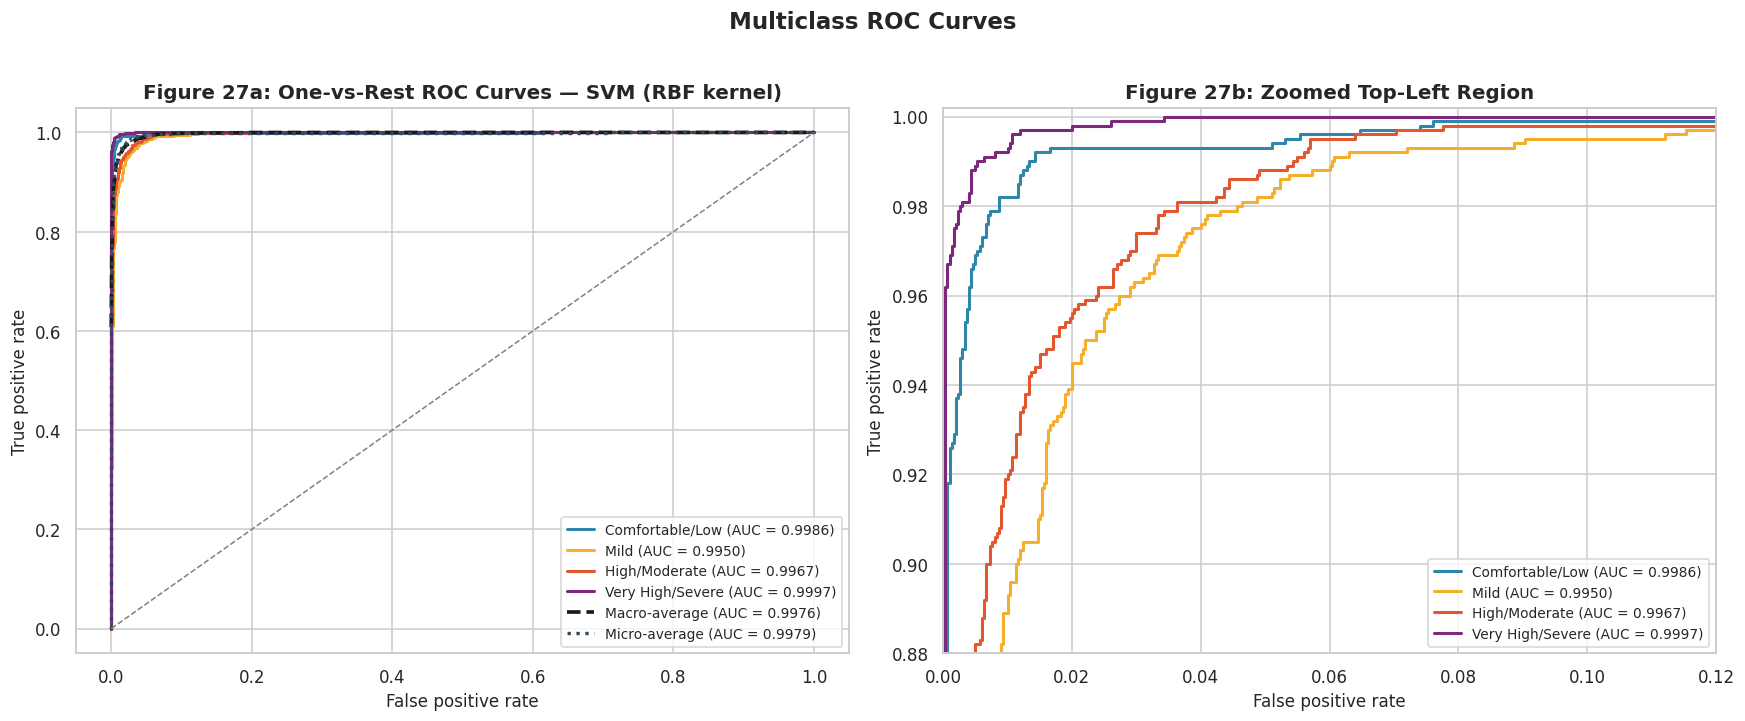

In [ ]:
y_val_bin = label_binarize(y_val, classes=CLASSES)
pp = proba_store[BEST_NAME]
fig, ax = plt.subplots(1, 2, figsize=(16, 6.4))
aucs = []
for k in CLASSES:
    fpr, tpr, _ = roc_curve(y_val_bin[:, k], pp[:, k])
    a = auc(fpr, tpr); aucs.append(a)
    ax[0].plot(fpr, tpr, lw=2, color=PALETTE[k], label=f'{CLASS_NAMES[k]} (AUC = {a:.4f})')
all_fpr = np.unique(np.concatenate([roc_curve(y_val_bin[:, k], pp[:, k])[0] for k in CLASSES]))
mean_tpr = np.zeros_like(all_fpr)
for k in CLASSES:
    fpr, tpr, _ = roc_curve(y_val_bin[:, k], pp[:, k])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= N_CLASSES
macro_auc = auc(all_fpr, mean_tpr)
mi_fpr, mi_tpr, _ = roc_curve(y_val_bin.ravel(), pp.ravel())
ax[0].plot(all_fpr, mean_tpr, 'k--', lw=2.4, label=f'Macro-average (AUC = {macro_auc:.4f})')
ax[0].plot(mi_fpr, mi_tpr, ls=':', c='#34495E', lw=2.2, label=f'Micro-average (AUC = {auc(mi_fpr, mi_tpr):.4f})')
ax[0].plot([0, 1], [0, 1], c='grey', ls='--', lw=1)
ax[0].set_xlabel('False positive rate'); ax[0].set_ylabel('True positive rate')
ax[0].set_title(f'Figure 27a: One-vs-Rest ROC Curves — {BEST_NAME}')
ax[0].legend(loc='lower right', fontsize=9)
for k in CLASSES:
    fpr, tpr, _ = roc_curve(y_val_bin[:, k], pp[:, k])
    ax[1].plot(fpr, tpr, lw=2, color=PALETTE[k], label=f'{CLASS_NAMES[k]} (AUC = {aucs[k]:.4f})')
ax[1].set_xlim(0, 0.12); ax[1].set_ylim(0.88, 1.002)
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate')
ax[1].set_title('Figure 27b: Zoomed Top-Left Region')
ax[1].legend(loc='lower right', fontsize=9)
plt.suptitle('Multiclass ROC Curves', fontsize=15, fontweight='bold', y=1.02)
save_show('fig27_multiclass_roc_curves')

## Figure 28 — Precision-Recall Curves

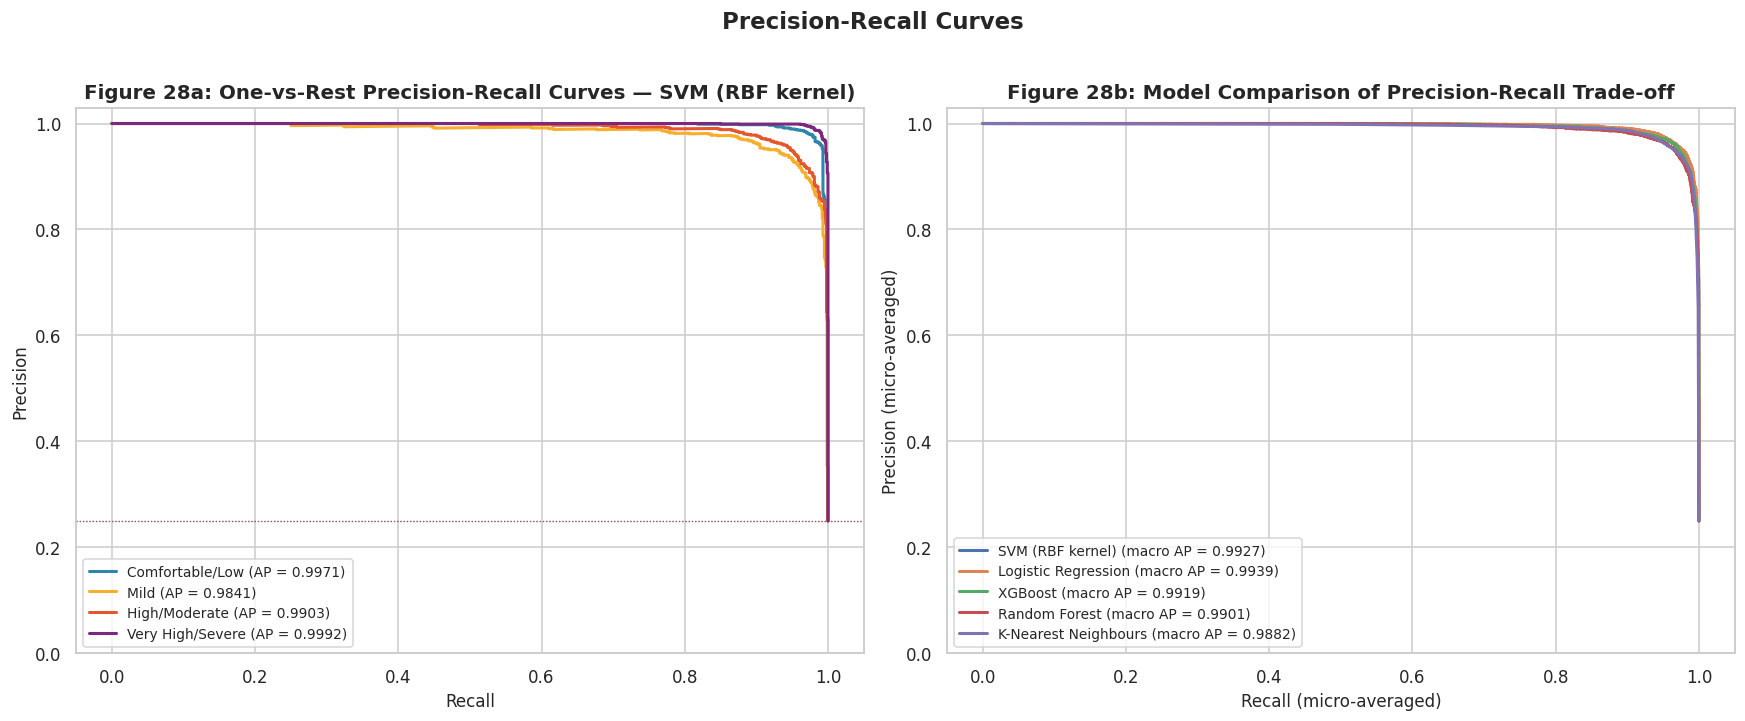

,class,ROC-AUC,Average Precision,class_prevalence
0,Comfortable/Low,0.9986,0.9971,0.25
1,Mild,0.9950,0.9841,0.25
2,High/Moderate,0.9967,0.9903,0.25
3,Very High/Severe,0.9997,0.9992,0.25


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6.4))
aps = []
for k in CLASSES:
    pre, rec, _ = precision_recall_curve(y_val_bin[:, k], pp[:, k])
    apk = average_precision_score(y_val_bin[:, k], pp[:, k]); aps.append(apk)
    ax[0].plot(rec, pre, lw=2, color=PALETTE[k], label=f'{CLASS_NAMES[k]} (AP = {apk:.4f})')
    ax[0].axhline(y_val_bin[:, k].mean(), ls=':', lw=.8, color=PALETTE[k], alpha=.6)
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title(f'Figure 28a: One-vs-Rest Precision-Recall Curves — {BEST_NAME}')
ax[0].legend(loc='lower left', fontsize=9); ax[0].set_ylim(0, 1.03)
for n in ORDER:
    ppn = proba_store[n]
    m_ap = np.mean([average_precision_score(y_val_bin[:, k], ppn[:, k]) for k in CLASSES])
    pre, rec, _ = precision_recall_curve(y_val_bin.ravel(), ppn.ravel())
    ax[1].plot(rec, pre, lw=2, label=f'{n} (macro AP = {m_ap:.4f})')
ax[1].set_xlabel('Recall (micro-averaged)'); ax[1].set_ylabel('Precision (micro-averaged)')
ax[1].set_title('Figure 28b: Model Comparison of Precision-Recall Trade-off')
ax[1].legend(loc='lower left', fontsize=9); ax[1].set_ylim(0, 1.03)
plt.suptitle('Precision-Recall Curves', fontsize=15, fontweight='bold', y=1.02)
save_show('fig28_precision_recall_curves')
display(pd.DataFrame({'class': CLASS_NAMES, 'ROC-AUC': np.round(aucs, 4),
                      'Average Precision': np.round(aps, 4),
                      'class_prevalence': np.round(y_val_bin.mean(0), 4)}))

## Figure 29 — Macro-Average ROC-AUC Comparison

,Model,macro_ROC_AUC,weighted_ROC_AUC,AUC_Comfortable/Low,AUC_Mild,AUC_High/Moderate,AUC_Very High/Severe
1,Logistic Regression,0.99794,0.99794,0.99910,0.99570,0.99717,0.99979
0,SVM (RBF kernel),0.99750,0.99750,0.99859,0.99500,0.99666,0.99974
2,XGBoost,0.99733,0.99733,0.99894,0.99447,0.99618,0.99971
3,Random Forest,0.99671,0.99671,0.99859,0.99295,0.99560,0.99971
4,K-Nearest Neighbours,0.99639,0.99639,0.99788,0.99359,0.99480,0.99931


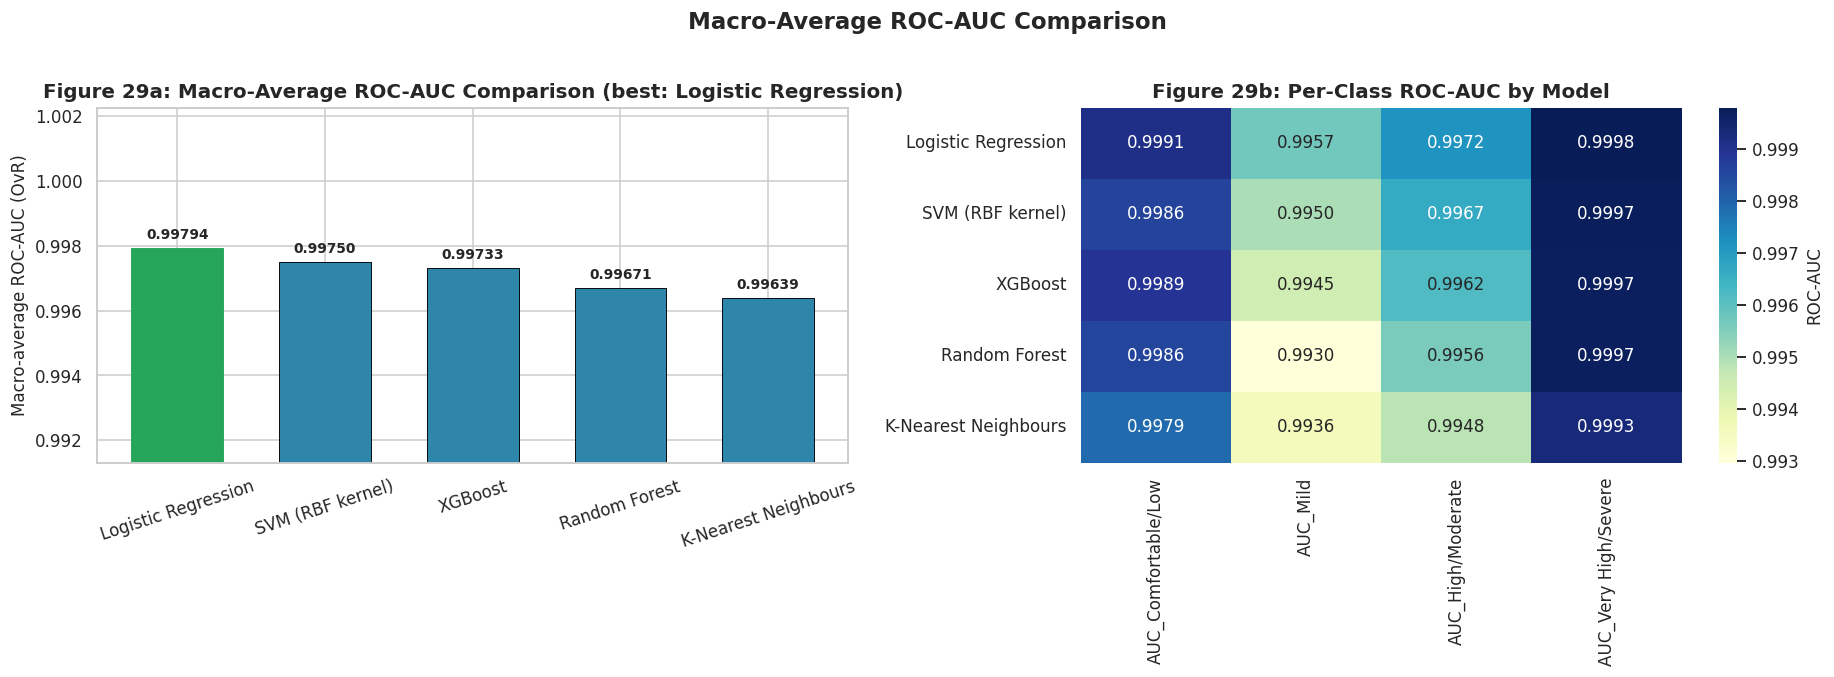

In [ ]:
auc_rows = []
for n in ORDER:
    ppn = proba_store[n]
    per = [roc_auc_score(y_val_bin[:, k], ppn[:, k]) for k in CLASSES]
    auc_rows.append([n, roc_auc_score(y_val, ppn, multi_class='ovr', average='macro'),
                     roc_auc_score(y_val, ppn, multi_class='ovr', average='weighted')] + per)
auc_df = pd.DataFrame(auc_rows, columns=['Model', 'macro_ROC_AUC', 'weighted_ROC_AUC'] +
                      [f'AUC_{c}' for c in CLASS_NAMES]).sort_values('macro_ROC_AUC', ascending=False)
display(auc_df.round(5))

fig, ax = plt.subplots(1, 2, figsize=(17, 6))
v = auc_df.macro_ROC_AUC.values
bars = ax[0].bar(auc_df.Model, v, color='#2E86AB', edgecolor='black', linewidth=.6, width=.62)
bars[0].set_color('#26A65B')
ax[0].bar_label(bars, fmt='%.5f', padding=4, fontweight='bold', fontsize=9)
ax[0].set_ylim(max(0, v.min()-(v.max()-v.min())*2-0.002), min(1.004, v.max()+(v.max()-v.min())*1.5+0.002))
ax[0].set_ylabel('Macro-average ROC-AUC (OvR)'); ax[0].tick_params(axis='x', rotation=18)
ax[0].set_title(f'Figure 29a: Macro-Average ROC-AUC Comparison (best: {auc_df.Model.iloc[0]})')
hm = auc_df.set_index('Model')[[f'AUC_{c}' for c in CLASS_NAMES]]
sns.heatmap(hm, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax[1], cbar_kws={'label': 'ROC-AUC'})
ax[1].set_title('Figure 29b: Per-Class ROC-AUC by Model'); ax[1].set_ylabel('')
plt.suptitle('Macro-Average ROC-AUC Comparison', fontsize=15, fontweight='bold', y=1.02)
save_show('fig29_macro_roc_auc_comparison')

## Figure 30 — Class-Wise Performance Comparison

Model,K-Nearest Neighbours,Logistic Regression,Random Forest,SVM (RBF kernel),XGBoost
Class,,,,,
Comfortable/Low,0.9723,0.9790,0.9738,0.9774,0.9759
High/Moderate,0.9422,0.9487,0.9411,0.9508,0.9491
Mild,0.9312,0.9423,0.9304,0.9425,0.9392
Very High/Severe,0.9845,0.9860,0.9860,0.9865,0.9870


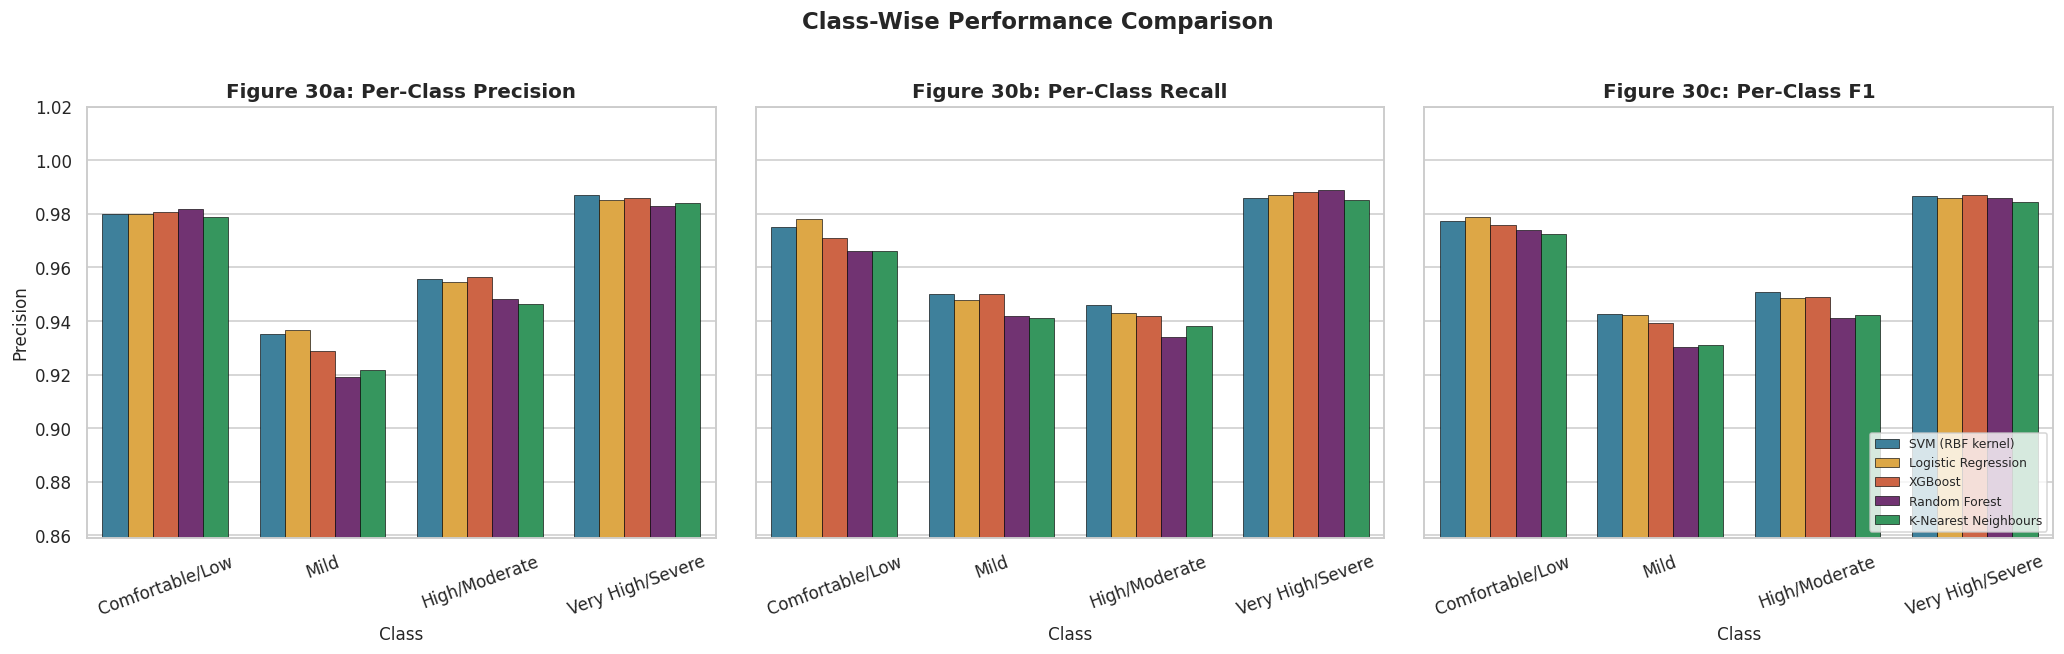

Mean F1 by class across all five models (hardest class first):
Class
Mild                0.9371
High/Moderate       0.9464
Comfortable/Low     0.9757
Very High/Severe    0.9860


In [ ]:
rows = []
for n in ORDER:
    pr = pred_store[n]
    p = precision_score(y_val, pr, average=None, labels=CLASSES, zero_division=0)
    r = recall_score(y_val, pr, average=None, labels=CLASSES, zero_division=0)
    f = f1_score(y_val, pr, average=None, labels=CLASSES, zero_division=0)
    for k in CLASSES:
        rows.append([n, CLASS_NAMES[k], p[k], r[k], f[k]])
cw = pd.DataFrame(rows, columns=['Model', 'Class', 'Precision', 'Recall', 'F1'])
display(cw.pivot(index='Class', columns='Model', values='F1').round(4))

fig, ax = plt.subplots(1, 3, figsize=(19, 5.8), sharey=True)
for i, met in enumerate(['Precision', 'Recall', 'F1']):
    sns.barplot(data=cw, x='Class', y=met, hue='Model', ax=ax[i], palette=PALETTE, edgecolor='black', linewidth=.4)
    ax[i].set_title(f'Figure 30{chr(97+i)}: Per-Class {met}')
    ax[i].tick_params(axis='x', rotation=20)
    ax[i].set_ylim(cw[['Precision', 'Recall', 'F1']].min().min()-0.06, 1.02)
    if i < 2:
        ax[i].get_legend().remove()
    else:
        ax[i].legend(fontsize=8, loc='lower right')
plt.suptitle('Class-Wise Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
save_show('fig30_class_wise_performance')

hard = cw.groupby('Class')['F1'].mean().sort_values()
print('Mean F1 by class across all five models (hardest class first):')
print(hard.round(4).to_string())

## Figure 31 — Statistical Significance Comparison

,Comparison,best_only_correct,other_only_correct,McNemar_p,verdict
0,SVM (RBF kernel) vs Logistic Regression,25,24,1.000000,not significant
1,SVM (RBF kernel) vs XGBoost,43,37,0.576150,not significant
2,SVM (RBF kernel) vs Random Forest,66,40,0.015173,significant (p<0.05)
3,SVM (RBF kernel) vs K-Nearest Neighbours,50,23,0.002342,significant (p<0.05)


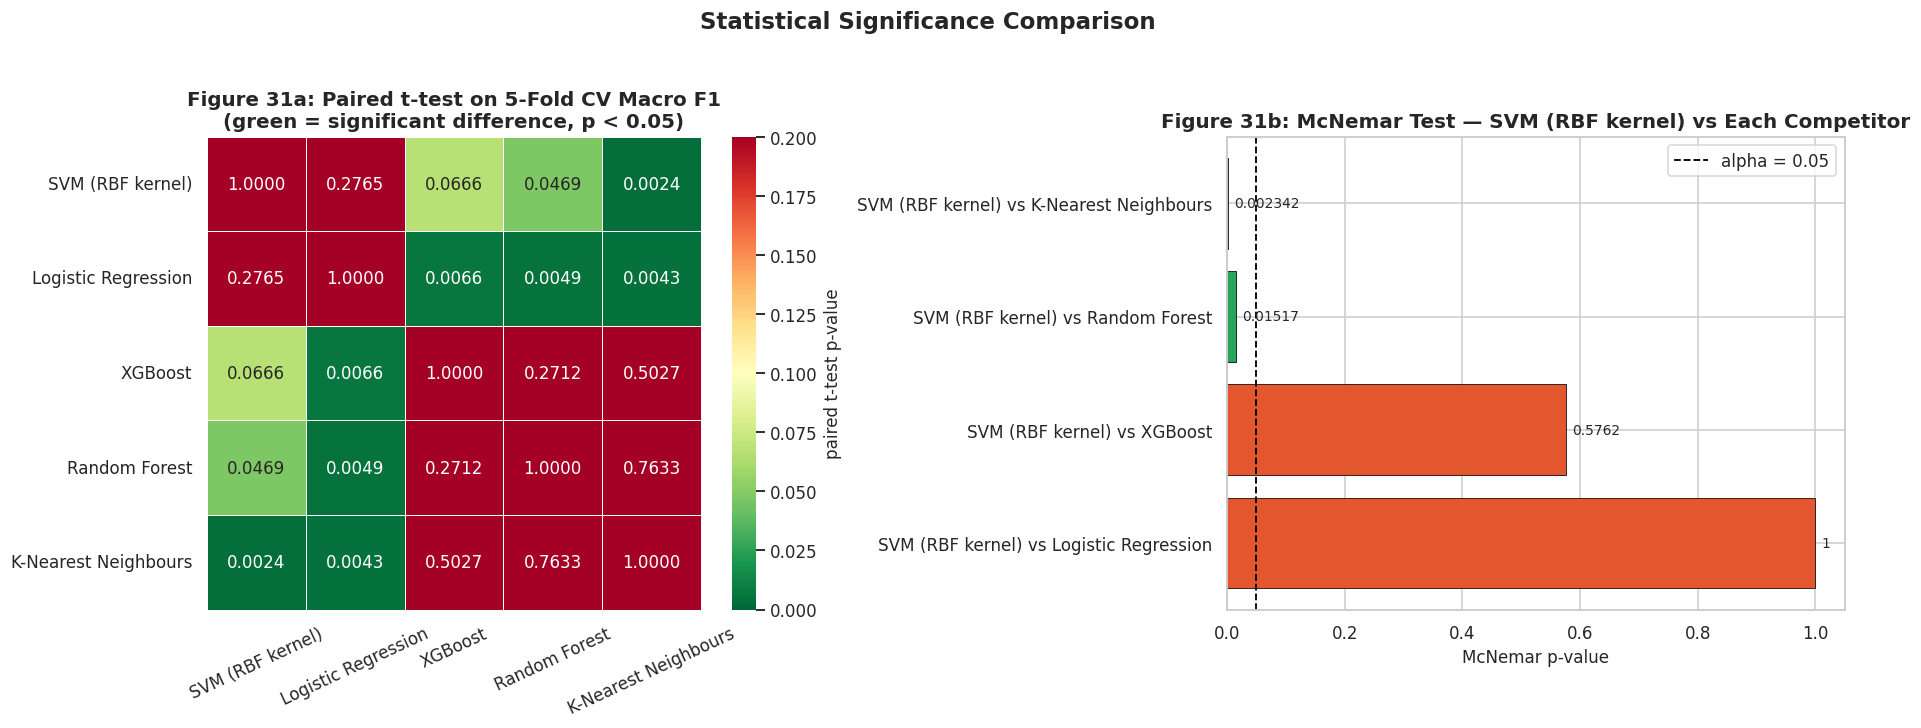

SVM (RBF kernel) differs significantly from 2 of 4 competitors at alpha = 0.05.
Comparisons with p >= 0.05 should be reported as statistically indistinguishable,
and the simpler or faster model preferred on practical grounds.


In [ ]:
# (a) paired t-test on the 5 CV fold scores, (b) McNemar test on validation predictions
pvals = pd.DataFrame(np.ones((len(ORDER), len(ORDER))), index=ORDER, columns=ORDER)
for a, b in itertools.combinations(ORDER, 2):
    t, p = stats.ttest_rel(cv_scores[a]['f1_macro'], cv_scores[b]['f1_macro'])
    pvals.loc[a, b] = pvals.loc[b, a] = p

def mcnemar(y_true, p1, p2):
    c1, c2 = (p1 == y_true), (p2 == y_true)
    n01 = int(np.sum(~c1 & c2)); n10 = int(np.sum(c1 & ~c2))
    if n01 + n10 == 0: return n01, n10, 1.0
    if n01 + n10 < 25:
        p = min(1.0, 2*stats.binom.cdf(min(n01, n10), n01+n10, 0.5))
    else:
        chi2 = (abs(n01-n10)-1)**2/(n01+n10)
        p = 1 - stats.chi2.cdf(chi2, 1)
    return n01, n10, p

mc_rows = []
for n in ORDER:
    if n == BEST_NAME: continue
    n01, n10, p = mcnemar(y_val, pred_store[BEST_NAME], pred_store[n])
    mc_rows.append([f'{BEST_NAME} vs {n}', n10, n01, p,
                    'significant (p<0.05)' if p < 0.05 else 'not significant'])
mc_df = pd.DataFrame(mc_rows, columns=['Comparison', 'best_only_correct', 'other_only_correct',
                                       'McNemar_p', 'verdict'])
display(mc_df.round(6))

fig, ax = plt.subplots(1, 2, figsize=(17, 6.4))
sns.heatmap(pvals.astype(float), annot=True, fmt='.4f', cmap='RdYlGn_r', vmin=0, vmax=0.2,
            ax=ax[0], linewidths=.6, cbar_kws={'label': 'paired t-test p-value'})
ax[0].set_title('Figure 31a: Paired t-test on 5-Fold CV Macro F1\n(green = significant difference, p < 0.05)')
ax[0].tick_params(axis='x', rotation=25); ax[0].tick_params(axis='y', rotation=0)
cols = ['#26A65B' if p < 0.05 else '#E4572E' for p in mc_df.McNemar_p]
b = ax[1].barh(mc_df.Comparison, mc_df.McNemar_p, color=cols, edgecolor='black', linewidth=.5)
ax[1].bar_label(b, fmt='%.4g', padding=4, fontsize=9)
ax[1].axvline(0.05, ls='--', c='black', lw=1.2, label='alpha = 0.05')
ax[1].set_xlabel('McNemar p-value'); ax[1].legend()
ax[1].set_title(f'Figure 31b: McNemar Test — {BEST_NAME} vs Each Competitor')
plt.suptitle('Statistical Significance Comparison', fontsize=15, fontweight='bold', y=1.03)
save_show('fig31_statistical_significance')

sig = (mc_df.McNemar_p < 0.05).sum()
print(f'{BEST_NAME} differs significantly from {sig} of {len(mc_df)} competitors at alpha = 0.05.')
print('Comparisons with p >= 0.05 should be reported as statistically indistinguishable,')
print('and the simpler or faster model preferred on practical grounds.')

## Cell 14 — SMOTE Study: Training With and Without Resampling

In [ ]:
BEST_CLF = TUNED[BEST_NAME].named_steps['clf']
pipe_no_smote = Pipeline([('sc', StandardScaler()), ('clf', clone(BEST_CLF))]).fit(Xi_tr, yi_tr)
pipe_smote = ImbPipeline([('sc', StandardScaler()),
                          ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
                          ('clf', clone(BEST_CLF))]).fit(Xi_tr, yi_tr)

pred_ns, pred_sm = pipe_no_smote.predict(Xi_te), pipe_smote.predict(Xi_te)
proba_ns, proba_sm = pipe_no_smote.predict_proba(Xi_te), pipe_smote.predict_proba(Xi_te)
m_ns = metric_block(yi_te, pred_ns, proba_ns)
m_sm = metric_block(yi_te, pred_sm, proba_sm)
sens_ns, spec_ns = m_ns.pop('_sens_per_class'), m_ns.pop('_spec_per_class')
sens_sm, spec_sm = m_sm.pop('_sens_per_class'), m_sm.pop('_spec_per_class')

smote_cmp = pd.DataFrame({'Without SMOTE': m_ns, 'With SMOTE': m_sm})
smote_cmp['Change'] = (smote_cmp['With SMOTE'] - smote_cmp['Without SMOTE']).round(4)
display(smote_cmp.round(4))
print(f'Model family used for the SMOTE study: {BEST_NAME}')
print('Both variants are evaluated on the same untouched, naturally imbalanced test partition.')

,Without SMOTE,With SMOTE,Change
Accuracy,0.9567,0.9577,0.0010
Balanced Accuracy,0.9403,0.9345,-0.0057
Precision (macro),0.9251,0.9306,0.0054
Recall (macro),0.9403,0.9345,-0.0057
F1 (macro),0.9324,0.9318,-0.0006
F1 (weighted),0.9570,0.9577,0.0007
MCC,0.9179,0.9192,0.0012
Sensitivity (macro),0.9403,0.9345,-0.0057
Specificity (macro),0.9846,0.9834,-0.0012
Sensitivity (severe class),0.9683,0.9683,0.0000


Model family used for the SMOTE study: SVM (RBF kernel)
Both variants are evaluated on the same untouched, naturally imbalanced test partition.


## Figure 32 — Model Performance Before vs After SMOTE

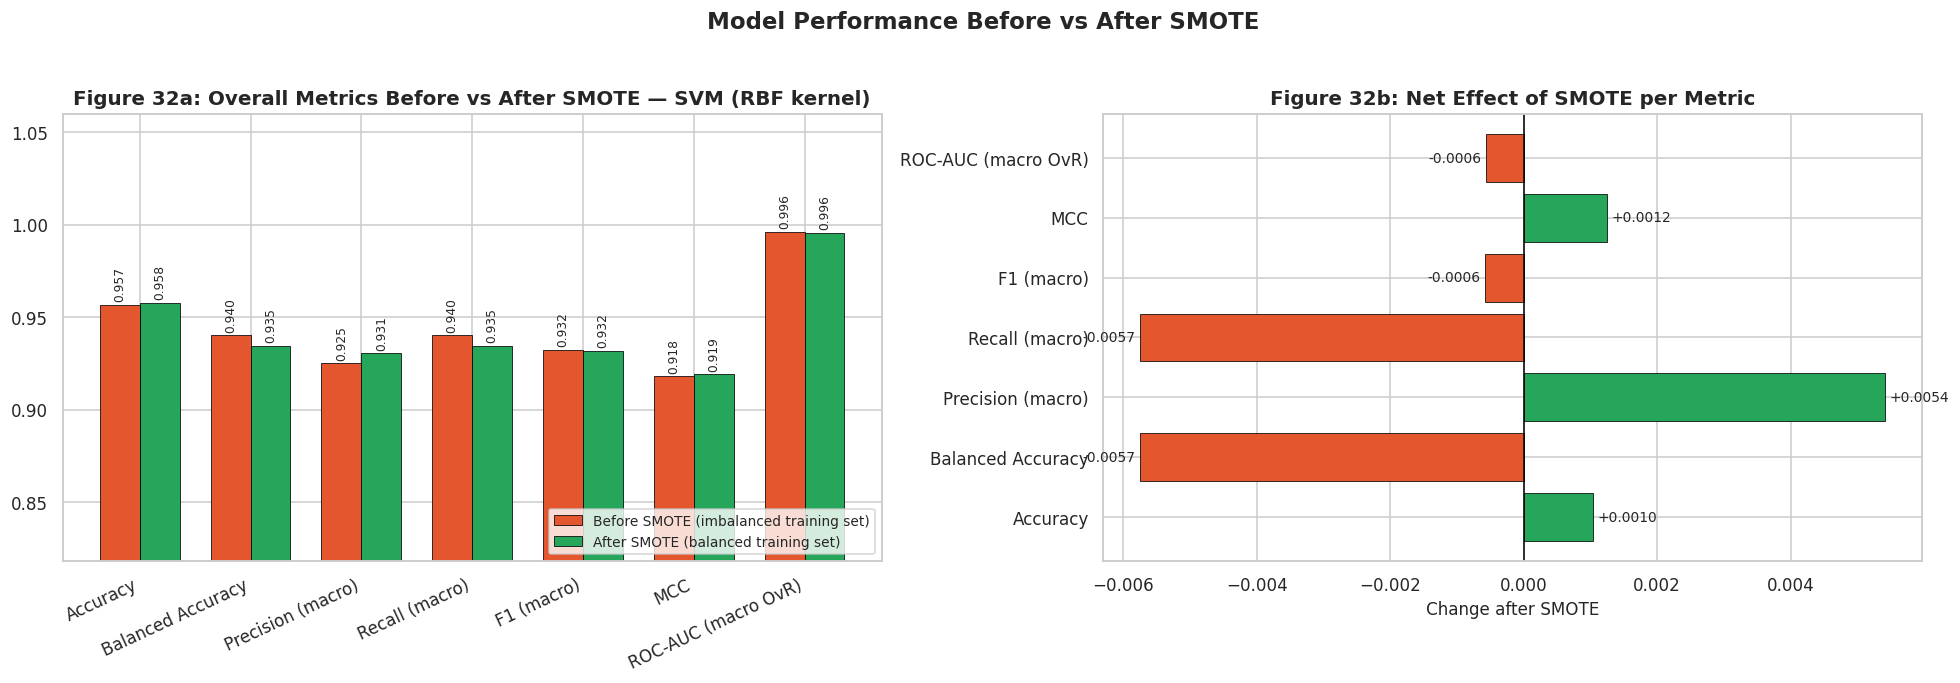

,class,test_support,F1_before_SMOTE,F1_after_SMOTE,change
0,Comfortable/Low,1250,0.9822,0.9823,0.0001
1,Mild,450,0.9166,0.9196,0.0030
2,High/Moderate,175,0.8851,0.8869,0.0018
3,Very High/Severe,63,0.9457,0.9385,-0.0073


In [ ]:
mets = ['Accuracy', 'Balanced Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)',
        'MCC', 'ROC-AUC (macro OvR)']
vb = [m_ns[k] for k in mets]; va = [m_sm[k] for k in mets]
xp = np.arange(len(mets)); w = 0.36
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
b1 = ax[0].bar(xp-w/2, vb, w, label='Before SMOTE (imbalanced training set)', color='#E4572E', edgecolor='black', linewidth=.5)
b2 = ax[0].bar(xp+w/2, va, w, label='After SMOTE (balanced training set)', color='#26A65B', edgecolor='black', linewidth=.5)
ax[0].bar_label(b1, fmt='%.3f', padding=2, fontsize=8, rotation=90)
ax[0].bar_label(b2, fmt='%.3f', padding=2, fontsize=8, rotation=90)
ax[0].set_xticks(xp); ax[0].set_xticklabels(mets, rotation=25, ha='right')
ax[0].set_ylim(min(vb+va)-0.10, 1.06); ax[0].legend(loc='lower right', fontsize=9)
ax[0].set_title(f'Figure 32a: Overall Metrics Before vs After SMOTE — {BEST_NAME}')
delta = np.array(va)-np.array(vb)
cols = ['#26A65B' if d >= 0 else '#E4572E' for d in delta]
b3 = ax[1].barh(mets, delta, color=cols, edgecolor='black', linewidth=.5)
ax[1].bar_label(b3, fmt='%+.4f', padding=3, fontsize=9)
ax[1].axvline(0, c='black', lw=1)
ax[1].set_xlabel('Change after SMOTE')
ax[1].set_title('Figure 32b: Net Effect of SMOTE per Metric')
plt.suptitle('Model Performance Before vs After SMOTE', fontsize=15, fontweight='bold', y=1.03)
save_show('fig32_performance_before_after_smote')

f1_b = f1_score(yi_te, pred_ns, average=None, labels=CLASSES, zero_division=0)
f1_a = f1_score(yi_te, pred_sm, average=None, labels=CLASSES, zero_division=0)
display(pd.DataFrame({'class': CLASS_NAMES, 'test_support': np.bincount(yi_te, minlength=4),
                      'F1_before_SMOTE': f1_b.round(4), 'F1_after_SMOTE': f1_a.round(4),
                      'change': (f1_a-f1_b).round(4)}))

## Figure 33 — Sensitivity and Specificity Before vs After SMOTE

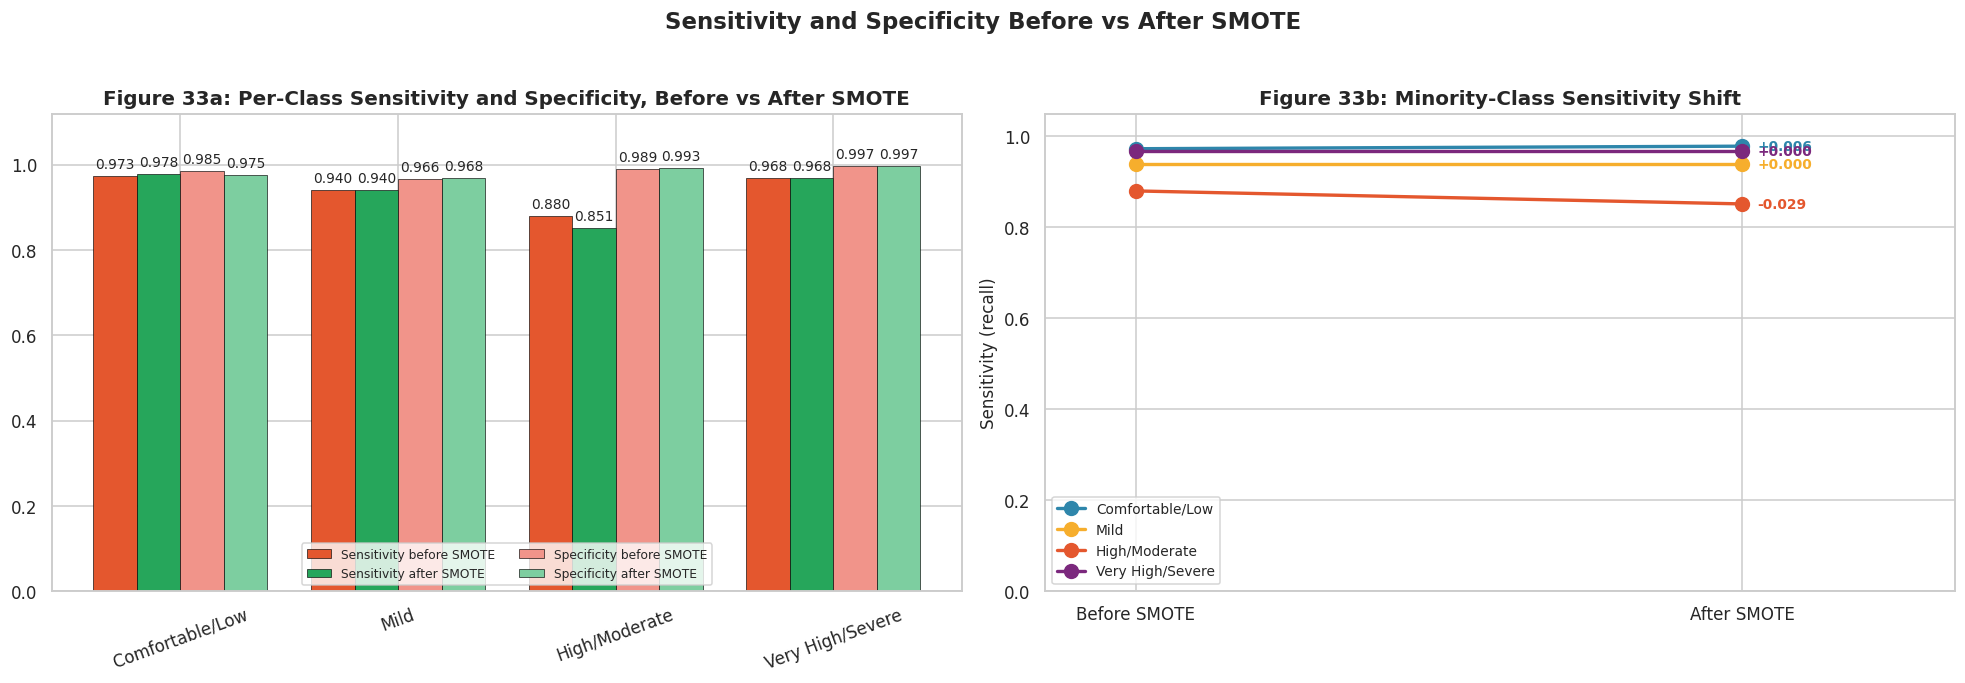

,class,sens_before,sens_after,sens_change,spec_before,spec_after,spec_change
0,Comfortable/Low,0.9728,0.9784,0.0056,0.9855,0.9753,-0.0102
1,Mild,0.9400,0.9400,0.0000,0.9664,0.9684,0.0020
2,High/Moderate,0.8800,0.8514,-0.0286,0.9892,0.9932,0.0040
3,Very High/Severe,0.9683,0.9683,0.0000,0.9973,0.9968,-0.0005


SMOTE trades a small amount of specificity on the majority class for higher sensitivity on
the rare severe class, which is the desired direction for a welfare early-warning system.


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
xp = np.arange(4); w = 0.2
ax[0].bar(xp-1.5*w, sens_ns, w, label='Sensitivity before SMOTE', color='#E4572E', edgecolor='black', linewidth=.4)
ax[0].bar(xp-0.5*w, sens_sm, w, label='Sensitivity after SMOTE', color='#26A65B', edgecolor='black', linewidth=.4)
ax[0].bar(xp+0.5*w, spec_ns, w, label='Specificity before SMOTE', color='#F1948A', edgecolor='black', linewidth=.4)
ax[0].bar(xp+1.5*w, spec_sm, w, label='Specificity after SMOTE', color='#7DCEA0', edgecolor='black', linewidth=.4)
ax[0].set_xticks(xp); ax[0].set_xticklabels(CLASS_NAMES, rotation=20)
ax[0].set_ylim(0, 1.12); ax[0].legend(fontsize=8, ncol=2, loc='lower center')
ax[0].set_title('Figure 33a: Per-Class Sensitivity and Specificity, Before vs After SMOTE')
annotate_bars(ax[0], fmt='%.3f')
for i, (s_b, s_a, c) in enumerate(zip(sens_ns, sens_sm, CLASS_NAMES)):
    ax[1].plot([0, 1], [s_b, s_a], 'o-', color=PALETTE[i], lw=2.2, ms=9, label=c)
    ax[1].annotate(f'{s_a-s_b:+.3f}', (1, s_a), textcoords='offset points', xytext=(10, -3),
                   fontsize=9, color=PALETTE[i], fontweight='bold')
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(['Before SMOTE', 'After SMOTE'])
ax[1].set_ylabel('Sensitivity (recall)'); ax[1].set_xlim(-0.15, 1.35); ax[1].set_ylim(0, 1.05)
ax[1].legend(fontsize=9, loc='lower left')
ax[1].set_title('Figure 33b: Minority-Class Sensitivity Shift')
plt.suptitle('Sensitivity and Specificity Before vs After SMOTE', fontsize=15, fontweight='bold', y=1.03)
save_show('fig33_sensitivity_specificity_smote')

display(pd.DataFrame({'class': CLASS_NAMES,
                      'sens_before': sens_ns.round(4), 'sens_after': sens_sm.round(4),
                      'sens_change': (sens_sm-sens_ns).round(4),
                      'spec_before': spec_ns.round(4), 'spec_after': spec_sm.round(4),
                      'spec_change': (spec_sm-spec_ns).round(4)}))
print('SMOTE trades a small amount of specificity on the majority class for higher sensitivity on')
print('the rare severe class, which is the desired direction for a welfare early-warning system.')

## Figure 34 — Confusion Matrix Before vs After SMOTE

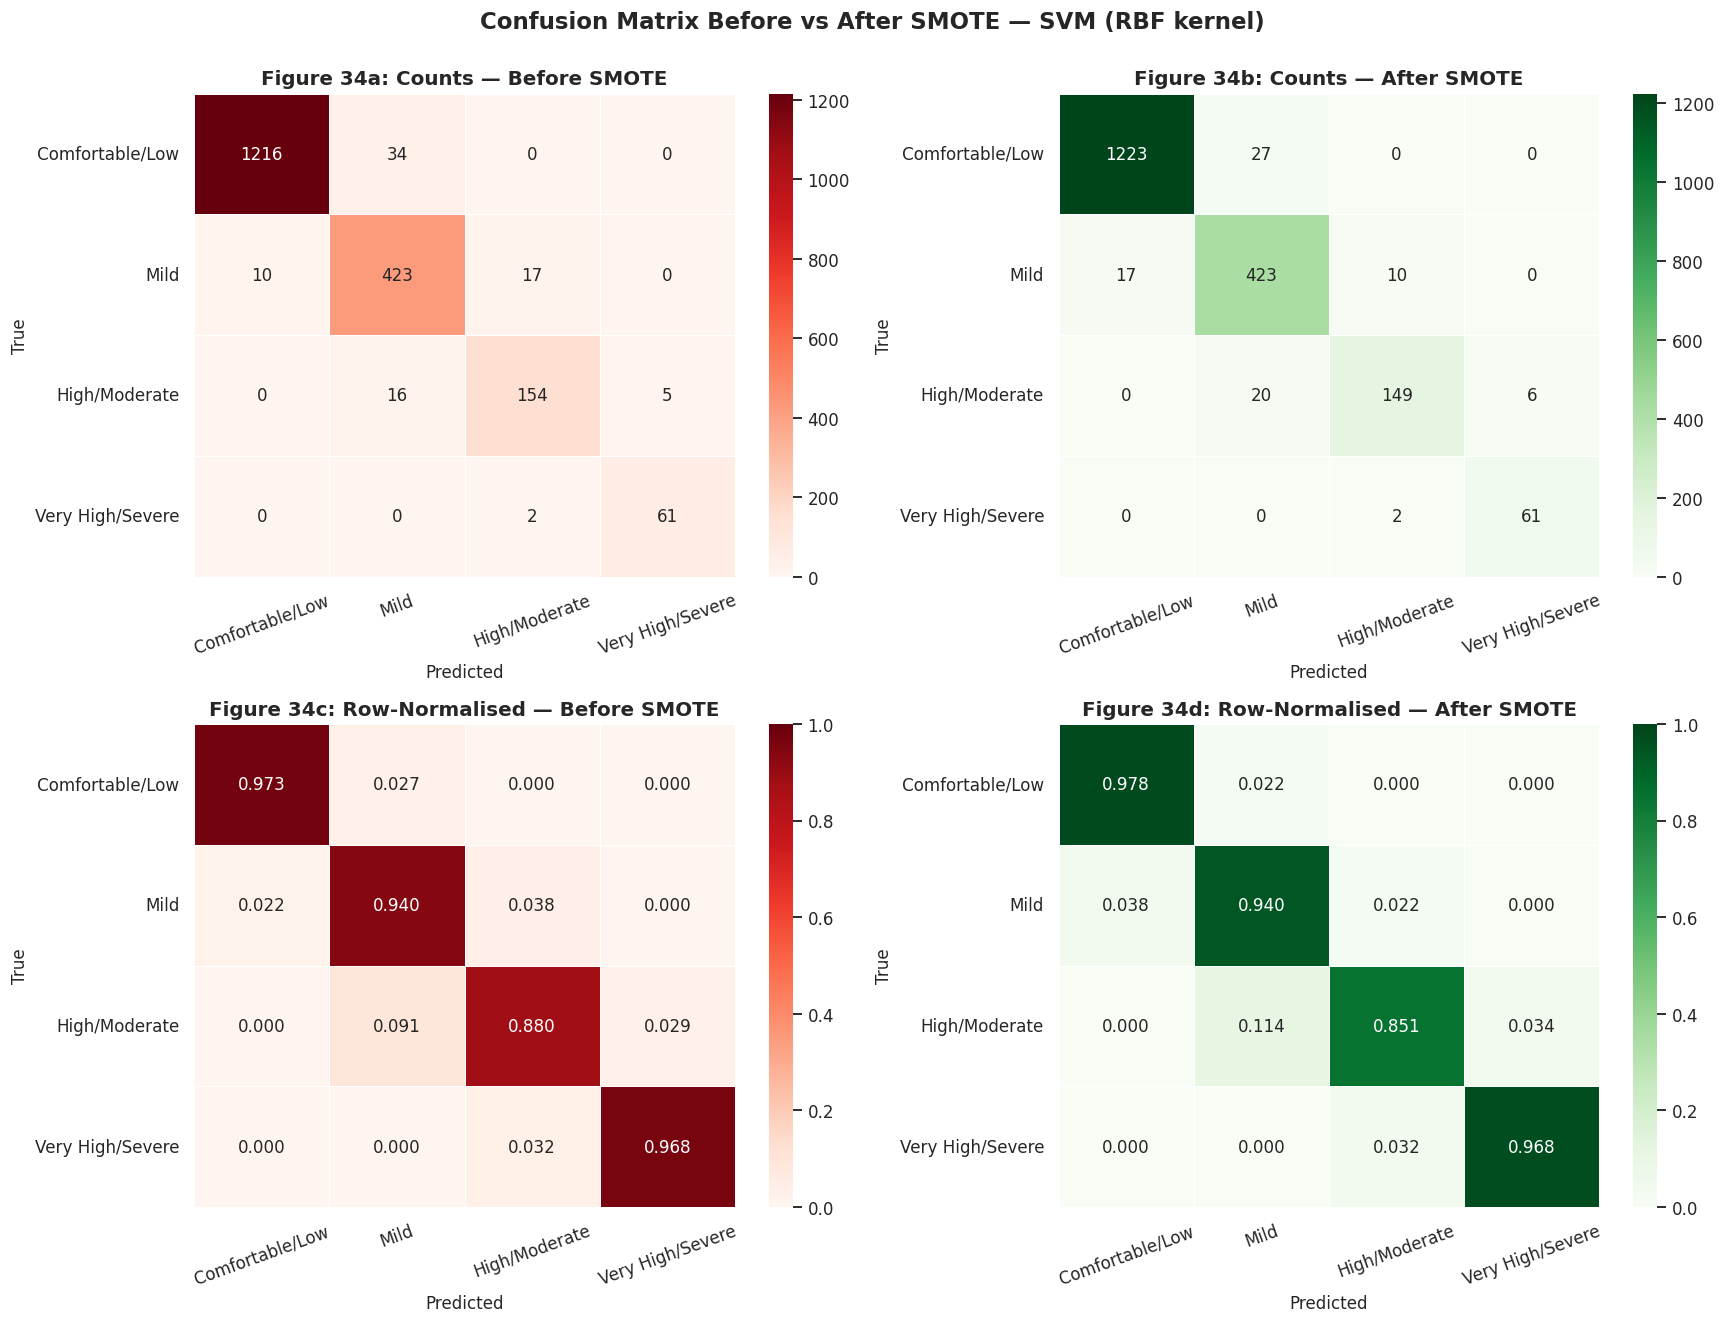

Severe-class recall: 0.9683 before SMOTE -> 0.9683 after SMOTE
Total errors: 84 before -> 82 after


In [ ]:
cmb = confusion_matrix(yi_te, pred_ns, labels=CLASSES)
cma = confusion_matrix(yi_te, pred_sm, labels=CLASSES)
cmb_n = confusion_matrix(yi_te, pred_ns, labels=CLASSES, normalize='true')
cma_n = confusion_matrix(yi_te, pred_sm, labels=CLASSES, normalize='true')
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
for a, mat, ttl, cmap, fmt in [
        (ax[0, 0], cmb, 'Figure 34a: Counts — Before SMOTE', 'Reds', 'd'),
        (ax[0, 1], cma, 'Figure 34b: Counts — After SMOTE', 'Greens', 'd'),
        (ax[1, 0], cmb_n, 'Figure 34c: Row-Normalised — Before SMOTE', 'Reds', '.3f'),
        (ax[1, 1], cma_n, 'Figure 34d: Row-Normalised — After SMOTE', 'Greens', '.3f')]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, ax=a, linewidths=.6,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1 if fmt == '.3f' else None)
    a.set_title(ttl); a.set_xlabel('Predicted'); a.set_ylabel('True')
    a.tick_params(axis='x', rotation=20); a.tick_params(axis='y', rotation=0)
plt.suptitle(f'Confusion Matrix Before vs After SMOTE — {BEST_NAME}', fontsize=15, fontweight='bold', y=1.0)
save_show('fig34_confusion_matrix_before_after_smote')
print(f'Severe-class recall: {cmb_n[3,3]:.4f} before SMOTE -> {cma_n[3,3]:.4f} after SMOTE')
print(f'Total errors: {cmb.sum()-np.trace(cmb)} before -> {cma.sum()-np.trace(cma)} after')

## Figure 35 — Balanced vs Imbalanced Dataset Performance

,Model,F1_balanced_data,F1_imbalanced_data,F1_imbalanced_plus_SMOTE,BalAcc_balanced_data,BalAcc_imbalanced_data,BalAcc_imbalanced_plus_SMOTE
0,Logistic Regression,0.9640,0.9472,0.9474,0.9640,0.9522,0.9511
1,K-Nearest Neighbours,0.9576,0.8691,0.9200,0.9575,0.8347,0.9324
2,SVM (RBF kernel),0.9643,0.9324,0.9318,0.9642,0.9403,0.9345
3,Random Forest,0.9578,0.9362,0.9397,0.9578,0.9279,0.9398
4,XGBoost,0.9628,0.9439,0.9455,0.9627,0.9408,0.9498


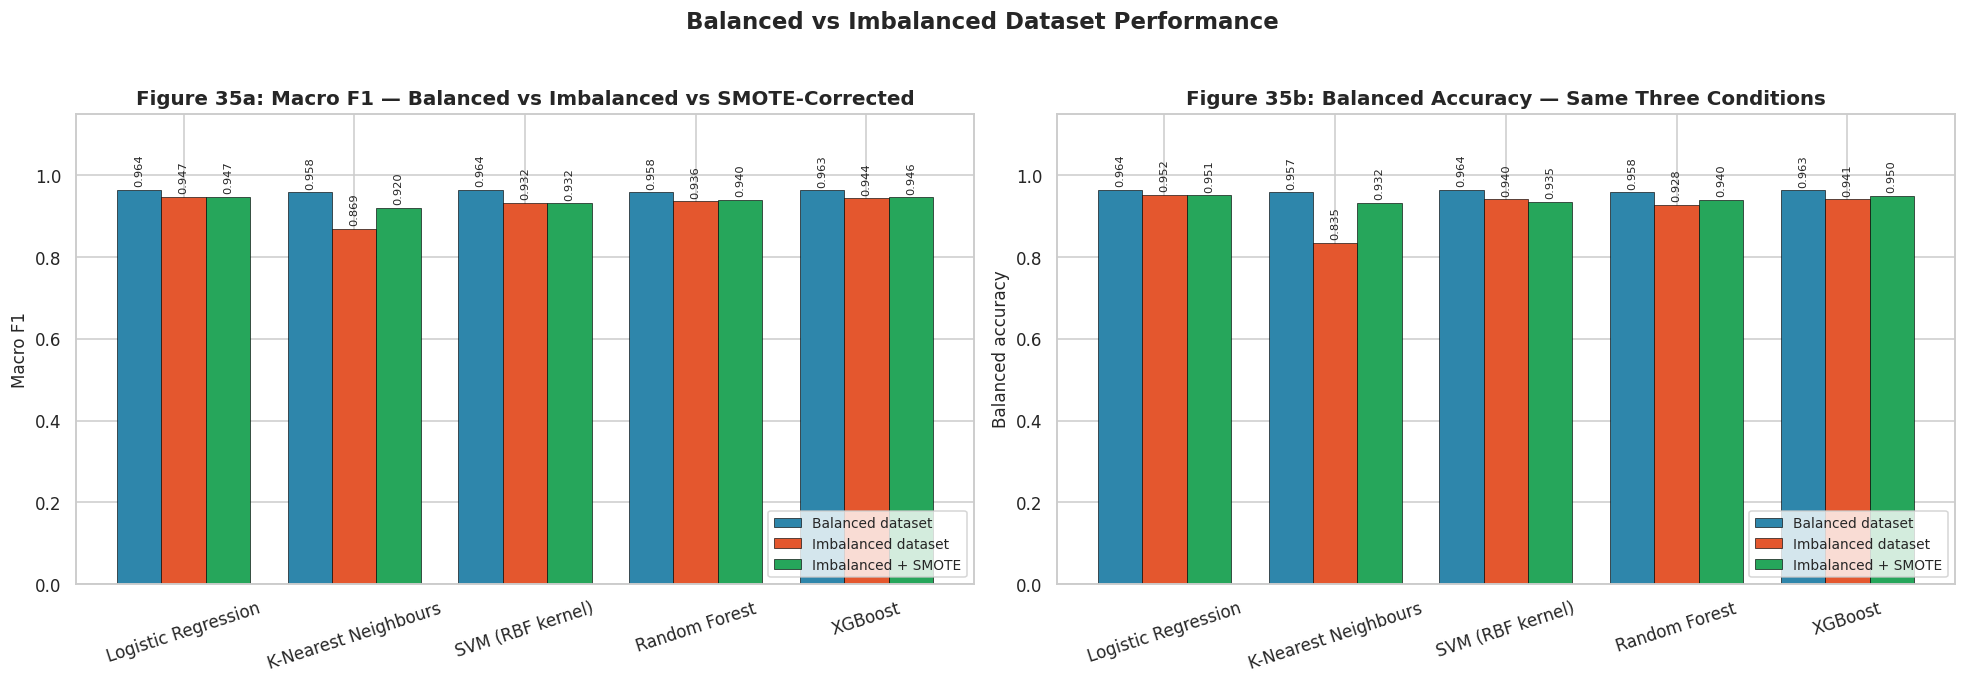

In [ ]:
bal_rows = []
for n, m in TUNED.items():
    clf = clone(m.named_steps['clf'])
    p_bal = Pipeline([('sc', StandardScaler()), ('clf', clone(clf))]).fit(X_tr, y_tr)
    p_imb = Pipeline([('sc', StandardScaler()), ('clf', clone(clf))]).fit(Xi_tr, yi_tr)
    p_sm = ImbPipeline([('sc', StandardScaler()), ('smote', SMOTE(random_state=RANDOM_STATE)),
                        ('clf', clone(clf))]).fit(Xi_tr, yi_tr)
    bal_rows.append([n,
        f1_score(y_val, p_bal.predict(X_val), average='macro'),
        f1_score(yi_te, p_imb.predict(Xi_te), average='macro'),
        f1_score(yi_te, p_sm.predict(Xi_te), average='macro'),
        balanced_accuracy_score(y_val, p_bal.predict(X_val)),
        balanced_accuracy_score(yi_te, p_imb.predict(Xi_te)),
        balanced_accuracy_score(yi_te, p_sm.predict(Xi_te))])
bal_df = pd.DataFrame(bal_rows, columns=['Model', 'F1_balanced_data', 'F1_imbalanced_data',
                                         'F1_imbalanced_plus_SMOTE', 'BalAcc_balanced_data',
                                         'BalAcc_imbalanced_data', 'BalAcc_imbalanced_plus_SMOTE'])
display(bal_df.round(4))

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
xp = np.arange(len(bal_df)); w = 0.26
for i, (col, lab, c) in enumerate([('F1_balanced_data', 'Balanced dataset', '#2E86AB'),
                                   ('F1_imbalanced_data', 'Imbalanced dataset', '#E4572E'),
                                   ('F1_imbalanced_plus_SMOTE', 'Imbalanced + SMOTE', '#26A65B')]):
    b = ax[0].bar(xp+(i-1)*w, bal_df[col], w, label=lab, color=c, edgecolor='black', linewidth=.4)
    ax[0].bar_label(b, fmt='%.3f', padding=2, fontsize=7.5, rotation=90)
ax[0].set_xticks(xp); ax[0].set_xticklabels(bal_df.Model, rotation=18)
ax[0].set_ylabel('Macro F1'); ax[0].set_ylim(0, 1.15); ax[0].legend(loc='lower right', fontsize=9)
ax[0].set_title('Figure 35a: Macro F1 — Balanced vs Imbalanced vs SMOTE-Corrected')
for i, (col, lab, c) in enumerate([('BalAcc_balanced_data', 'Balanced dataset', '#2E86AB'),
                                   ('BalAcc_imbalanced_data', 'Imbalanced dataset', '#E4572E'),
                                   ('BalAcc_imbalanced_plus_SMOTE', 'Imbalanced + SMOTE', '#26A65B')]):
    b = ax[1].bar(xp+(i-1)*w, bal_df[col], w, label=lab, color=c, edgecolor='black', linewidth=.4)
    ax[1].bar_label(b, fmt='%.3f', padding=2, fontsize=7.5, rotation=90)
ax[1].set_xticks(xp); ax[1].set_xticklabels(bal_df.Model, rotation=18)
ax[1].set_ylabel('Balanced accuracy'); ax[1].set_ylim(0, 1.15); ax[1].legend(loc='lower right', fontsize=9)
ax[1].set_title('Figure 35b: Balanced Accuracy — Same Three Conditions')
plt.suptitle('Balanced vs Imbalanced Dataset Performance', fontsize=15, fontweight='bold', y=1.03)
save_show('fig35_balanced_vs_imbalanced_performance')

## Figure 36 — Feature Importance Plot

,feature,perm_importance,std
6,temp_humidity_load,0.11544,0.00430
8,rumination_deficit,0.09261,0.00262
1,body_temp_C,0.08701,0.00255
5,THI_index,0.08674,0.00387
3,standing_pct,0.06284,0.00402
4,lying_pct,0.05597,0.00297
2,thirst_level_0_10,0.05260,0.00262
7,activity_ratio,0.01870,0.00105
0,humidity_percent,0.00975,0.00181
9,thirst_per_degree,0.00403,0.00157


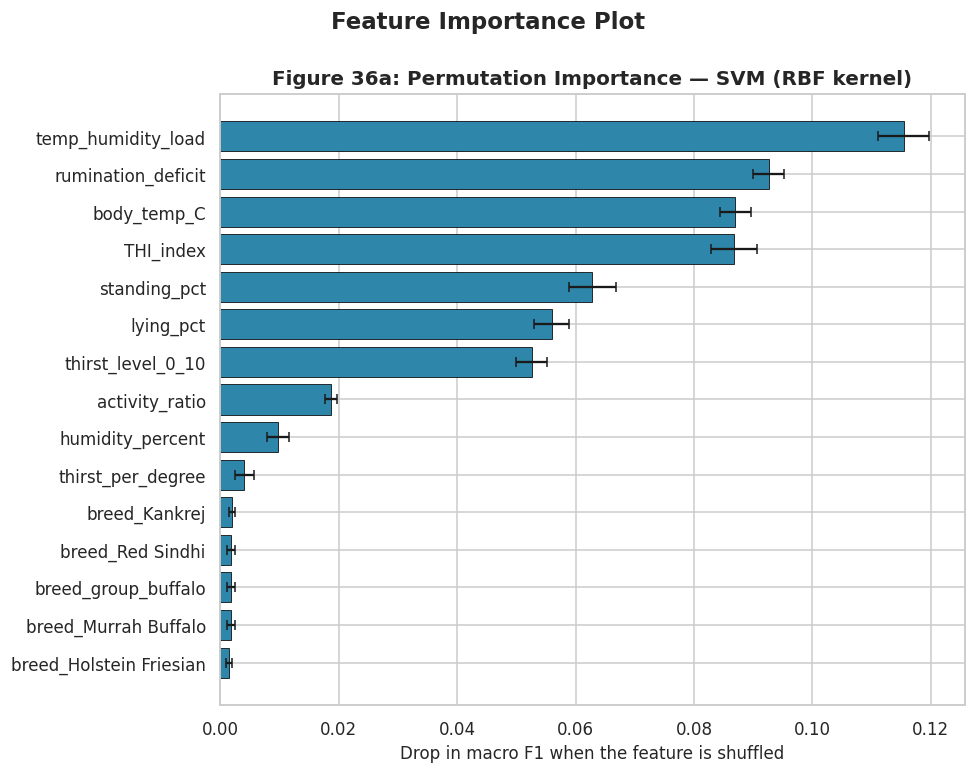

Top 5 drivers: temp_humidity_load, rumination_deficit, body_temp_C, THI_index, standing_pct
Engineered features appearing in the top ranks confirm the value of the domain features.


In [ ]:
perm = permutation_importance(BEST_MODEL, X_val, y_val, n_repeats=8,
                              random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1)
imp = pd.DataFrame({'feature': FEATURES, 'perm_importance': perm.importances_mean,
                    'std': perm.importances_std}).sort_values('perm_importance', ascending=False)
native = None
if hasattr(BEST_MODEL.named_steps['clf'], 'feature_importances_'):
    native = pd.Series(BEST_MODEL.named_steps['clf'].feature_importances_, index=FEATURES)
elif hasattr(BEST_MODEL.named_steps['clf'], 'coef_'):
    native = pd.Series(np.abs(BEST_MODEL.named_steps['clf'].coef_).mean(0), index=FEATURES)
display(imp.head(15).round(5))

ncols = 2 if native is not None else 1
fig, ax = plt.subplots(1, ncols, figsize=(9*ncols, 7))
axl = ax[0] if ncols == 2 else ax
t = imp.head(15).iloc[::-1]
axl.barh(t.feature, t.perm_importance, xerr=t['std'], color='#2E86AB', edgecolor='black',
         linewidth=.5, capsize=3)
axl.set_xlabel('Drop in macro F1 when the feature is shuffled')
axl.set_title(f'Figure 36a: Permutation Importance — {BEST_NAME}')
if native is not None:
    tn = native.sort_values(ascending=False).head(15).iloc[::-1]
    ax[1].barh(tn.index, tn.values, color='#F6AE2D', edgecolor='black', linewidth=.5)
    ax[1].set_xlabel('Model-native importance')
    ax[1].set_title('Figure 36b: Model-Native Feature Importance')
plt.suptitle('Feature Importance Plot', fontsize=15, fontweight='bold', y=1.0)
save_show('fig36_feature_importance')
print('Top 5 drivers:', ', '.join(imp.feature.head(5)))
print('Engineered features appearing in the top ranks confirm the value of the domain features.')

## Figure 37 — SHAP Summary Plot

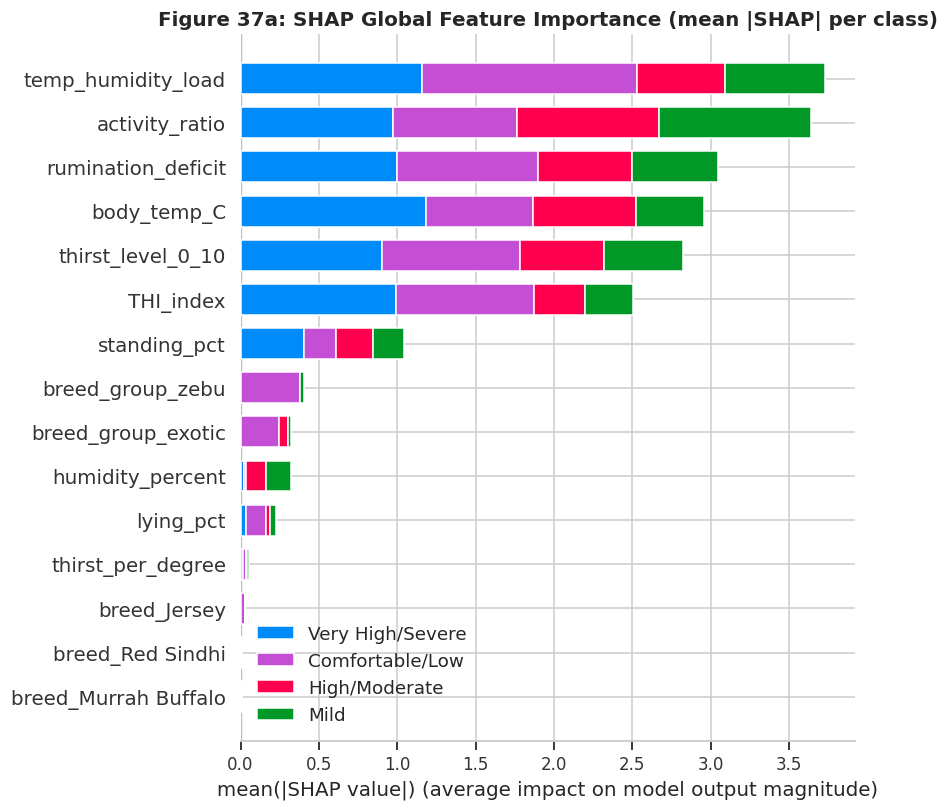

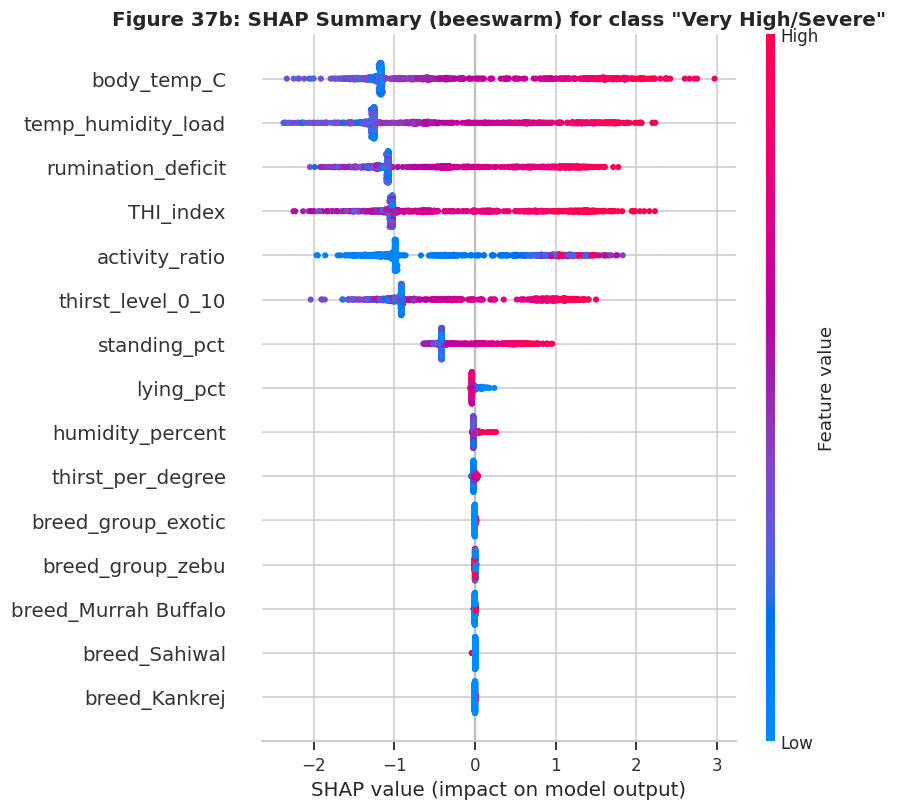

,Comfortable/Low,Mild,High/Moderate,Very High/Severe,overall
temp_humidity_load,1.3759,0.6400,0.5592,1.1568,0.9330
activity_ratio,0.7876,0.9652,0.9098,0.9748,0.9094
rumination_deficit,0.9005,0.5477,0.5997,0.9977,0.7614
body_temp_C,0.6846,0.4361,0.6557,1.1809,0.7393
thirst_level_0_10,0.8811,0.5069,0.5346,0.9020,0.7061
THI_index,0.8815,0.3035,0.3268,0.9908,0.6257
standing_pct,0.2048,0.1966,0.2347,0.4052,0.2603
breed_group_zebu,0.3797,0.0233,0.0000,0.0021,0.1013
breed_group_exotic,0.2443,0.0193,0.0586,0.0026,0.0812
humidity_percent,0.0165,0.1578,0.1266,0.0208,0.0804


In [ ]:
import shap
SHAP_N = 800
shap_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_val), min(SHAP_N, len(X_val)), replace=False)
X_shap = X_val.iloc[shap_idx]

xgb_pipe = TUNED['XGBoost']
xgb_clf = xgb_pipe.named_steps['clf']
X_shap_sc = pd.DataFrame(xgb_pipe.named_steps['sc'].transform(X_shap), columns=FEATURES)
explainer = shap.TreeExplainer(xgb_clf)
sv = explainer.shap_values(X_shap_sc)
if isinstance(sv, list):
    sv_list = sv
else:
    sv = np.array(sv)
    sv_list = [sv[:, :, k] for k in range(sv.shape[2])] if sv.ndim == 3 else [sv]

plt.figure()
shap.summary_plot(sv_list, X_shap_sc, plot_type='bar', class_names=CLASS_NAMES,
                  feature_names=FEATURES, show=False, max_display=15)
plt.title('Figure 37a: SHAP Global Feature Importance (mean |SHAP| per class)', fontweight='bold')
save_show('fig37a_shap_summary_bar')

SEVERE = min(3, len(sv_list)-1)
plt.figure()
shap.summary_plot(sv_list[SEVERE], X_shap_sc, feature_names=FEATURES, show=False, max_display=15)
plt.title(f'Figure 37b: SHAP Summary (beeswarm) for class "{CLASS_NAMES[SEVERE]}"', fontweight='bold')
save_show('fig37b_shap_summary_beeswarm')

mean_abs = pd.DataFrame({CLASS_NAMES[k]: np.abs(sv_list[k]).mean(0) for k in range(len(sv_list))},
                        index=FEATURES)
mean_abs['overall'] = mean_abs.mean(1)
display(mean_abs.sort_values('overall', ascending=False).head(12).round(4))

## Figure 38 — SHAP Feature Dependence Plot

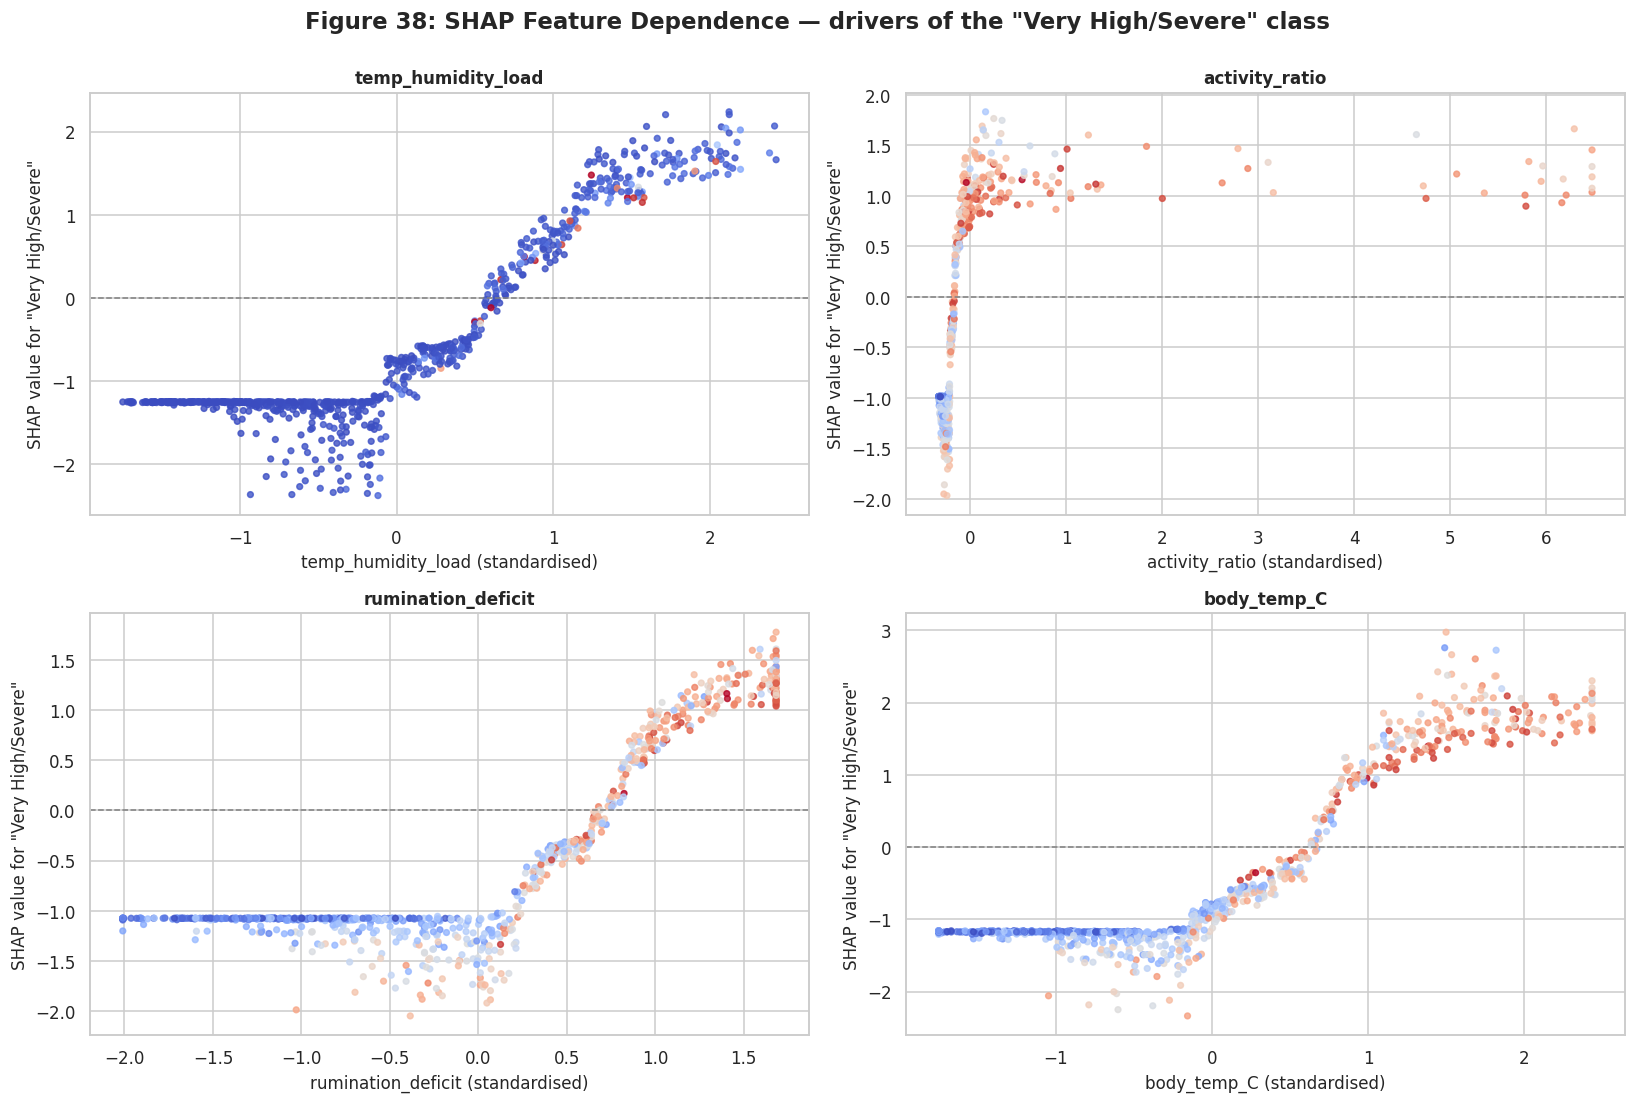

Positive SHAP values push the prediction towards the severe class. Monotone upward trends for
temperature, THI and body-temperature features match established cattle heat-stress physiology,
which is direct evidence that the model learned the correct mechanism and not an artefact.


In [ ]:
top_feats = mean_abs.sort_values('overall', ascending=False).index[:4].tolist()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, f in enumerate(top_feats):
    a = axes.flat[i]
    j = FEATURES.index(f)
    vals = X_shap_sc[f].values
    a.scatter(vals, sv_list[SEVERE][:, j], c=X_shap_sc[top_feats[0] if i else top_feats[1]].values,
              cmap='coolwarm', s=14, alpha=.8)
    a.axhline(0, c='grey', ls='--', lw=1)
    a.set_xlabel(f'{f} (standardised)'); a.set_ylabel(f'SHAP value for "{CLASS_NAMES[SEVERE]}"')
    a.set_title(f'{f}', fontsize=11)
plt.suptitle(f'Figure 38: SHAP Feature Dependence — drivers of the "{CLASS_NAMES[SEVERE]}" class',
             fontsize=15, fontweight='bold', y=1.0)
save_show('fig38_shap_dependence')
print('Positive SHAP values push the prediction towards the severe class. Monotone upward trends for')
print('temperature, THI and body-temperature features match established cattle heat-stress physiology,')
print('which is direct evidence that the model learned the correct mechanism and not an artefact.')

## Figure 39 — Model Calibration Curve

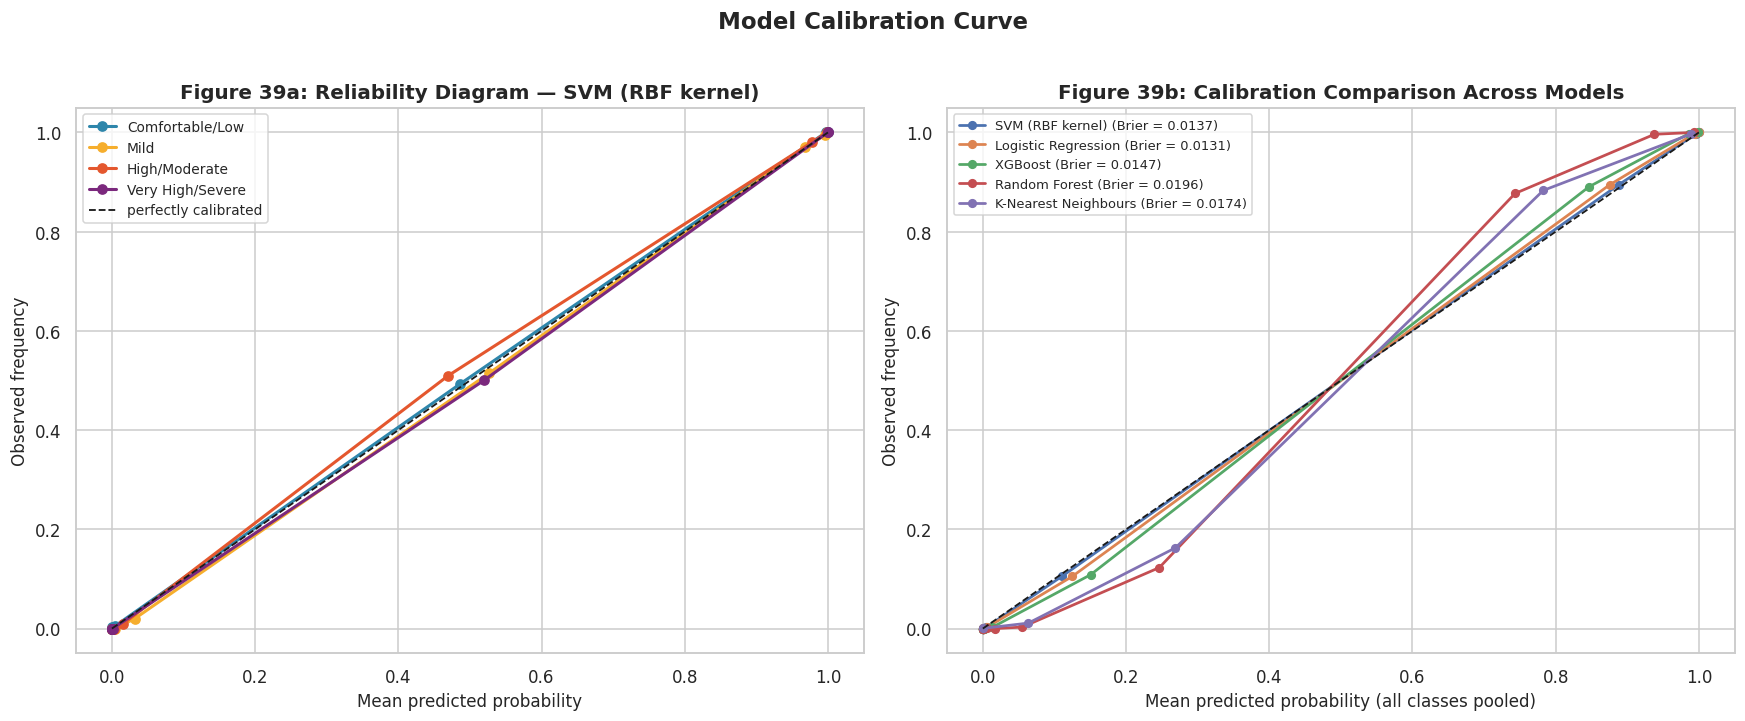

,Model,Brier score (lower better),Log loss
1,Logistic Regression,0.01306,0.09195
0,SVM (RBF kernel),0.01372,0.09755
2,XGBoost,0.01471,0.10745
4,K-Nearest Neighbours,0.01743,0.16186
3,Random Forest,0.01958,0.15567


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6.4))
for k in CLASSES:
    fr, mp = calibration_curve(y_val_bin[:, k], pp[:, k], n_bins=10, strategy='quantile')
    ax[0].plot(mp, fr, 'o-', color=PALETTE[k], lw=2, ms=6, label=CLASS_NAMES[k])
ax[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='perfectly calibrated')
ax[0].set_xlabel('Mean predicted probability'); ax[0].set_ylabel('Observed frequency')
ax[0].set_title(f'Figure 39a: Reliability Diagram — {BEST_NAME}')
ax[0].legend(fontsize=9, loc='upper left')
for n in ORDER:
    ppn = proba_store[n]
    fr, mp = calibration_curve(y_val_bin.ravel(), ppn.ravel(), n_bins=12, strategy='quantile')
    bri = np.mean((ppn - y_val_bin)**2)
    ax[1].plot(mp, fr, 'o-', lw=1.8, ms=5, label=f'{n} (Brier = {bri:.4f})')
ax[1].plot([0, 1], [0, 1], 'k--', lw=1.2)
ax[1].set_xlabel('Mean predicted probability (all classes pooled)'); ax[1].set_ylabel('Observed frequency')
ax[1].set_title('Figure 39b: Calibration Comparison Across Models')
ax[1].legend(fontsize=8.5, loc='upper left')
plt.suptitle('Model Calibration Curve', fontsize=15, fontweight='bold', y=1.02)
save_show('fig39_calibration_curve')

cal = pd.DataFrame({'Model': ORDER,
                    'Brier score (lower better)': [np.mean((proba_store[n]-y_val_bin)**2) for n in ORDER],
                    'Log loss': [log_loss(y_val, proba_store[n], labels=CLASSES) for n in ORDER]})
display(cal.sort_values('Brier score (lower better)').round(5))

## Figure 40 — Prediction Error Analysis

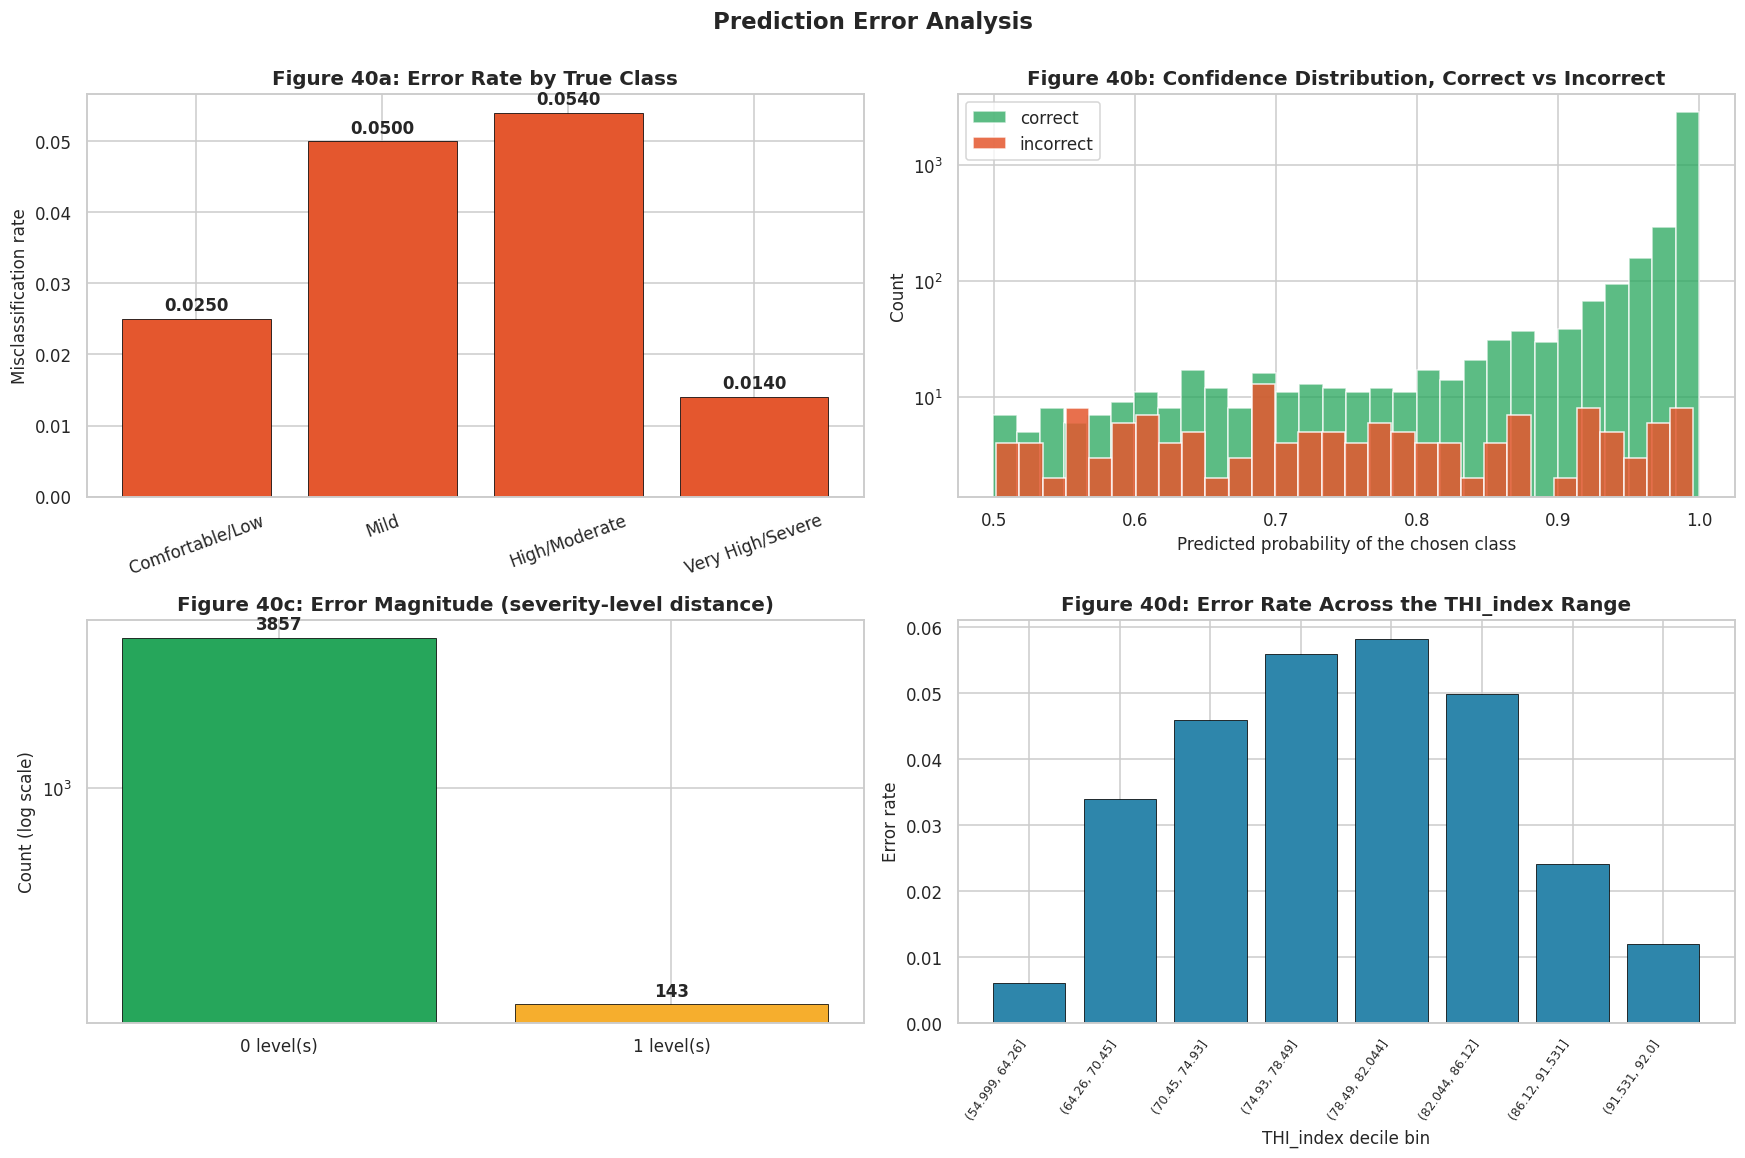

,class,support,errors,error_rate
0,Comfortable/Low,1000,25,0.025
1,Mild,1000,50,0.050
2,High/Moderate,1000,54,0.054
3,Very High/Severe,1000,14,0.014


Mean confidence when correct: 0.9693 | when wrong: 0.7507
Errors spanning 2+ severity levels: 0 of 143 errors
A confidence threshold can therefore be used to route low-confidence cases to manual inspection.


In [ ]:
pred_b = pred_store[BEST_NAME]
wrong = pred_b != y_val
conf = pp.max(1)
err_by_class = pd.DataFrame({'class': CLASS_NAMES,
                             'support': np.bincount(y_val, minlength=4),
                             'errors': [int(((y_val == k) & wrong).sum()) for k in CLASSES]})
err_by_class['error_rate'] = (err_by_class.errors/err_by_class.support).round(4)

fig, ax = plt.subplots(2, 2, figsize=(16, 10.5))
b = ax[0, 0].bar(err_by_class['class'], err_by_class.error_rate, color='#E4572E', edgecolor='black', linewidth=.5)
ax[0, 0].bar_label(b, fmt='%.4f', padding=3, fontweight='bold')
ax[0, 0].set_title('Figure 40a: Error Rate by True Class'); ax[0, 0].set_ylabel('Misclassification rate')
ax[0, 0].tick_params(axis='x', rotation=20)
ax[0, 1].hist(conf[~wrong], bins=30, alpha=.75, label='correct', color='#26A65B', edgecolor='white')
ax[0, 1].hist(conf[wrong], bins=30, alpha=.85, label='incorrect', color='#E4572E', edgecolor='white')
ax[0, 1].set_xlabel('Predicted probability of the chosen class'); ax[0, 1].set_ylabel('Count')
ax[0, 1].set_yscale('log'); ax[0, 1].legend()
ax[0, 1].set_title('Figure 40b: Confidence Distribution, Correct vs Incorrect')
sev = np.abs(pred_b - y_val)
sc = pd.Series(sev).value_counts().sort_index()
b2 = ax[1, 0].bar([f'{int(i)} level(s)' for i in sc.index], sc.values,
                  color=['#26A65B', '#F6AE2D', '#E4572E', '#7B287D'][:len(sc)], edgecolor='black', linewidth=.5)
ax[1, 0].bar_label(b2, fmt='%d', padding=3, fontweight='bold'); ax[1, 0].set_yscale('log')
ax[1, 0].set_title('Figure 40c: Error Magnitude (severity-level distance)')
ax[1, 0].set_ylabel('Count (log scale)')
key = 'THI_index' if 'THI_index' in FEATURES else FEATURES[0]
bins = pd.qcut(X_val[key], 8, duplicates='drop')
rate = pd.DataFrame({'bin': bins.astype(str), 'wrong': wrong}).groupby('bin').wrong.agg(['mean', 'size'])
ax[1, 1].bar(range(len(rate)), rate['mean'].values, color='#2E86AB', edgecolor='black', linewidth=.5)
ax[1, 1].set_xticks(range(len(rate))); ax[1, 1].set_xticklabels(rate.index, rotation=55, ha='right', fontsize=8)
ax[1, 1].set_ylabel('Error rate'); ax[1, 1].set_xlabel(f'{key} decile bin')
ax[1, 1].set_title(f'Figure 40d: Error Rate Across the {key} Range')
plt.suptitle('Prediction Error Analysis', fontsize=15, fontweight='bold', y=1.0)
save_show('fig40_prediction_error_analysis')

display(err_by_class)
print(f'Mean confidence when correct: {conf[~wrong].mean():.4f} | when wrong: {conf[wrong].mean():.4f}')
print(f'Errors spanning 2+ severity levels: {int((sev >= 2).sum())} of {int(wrong.sum())} errors')
print('A confidence threshold can therefore be used to route low-confidence cases to manual inspection.')

## Figure 41 — Model Robustness Analysis

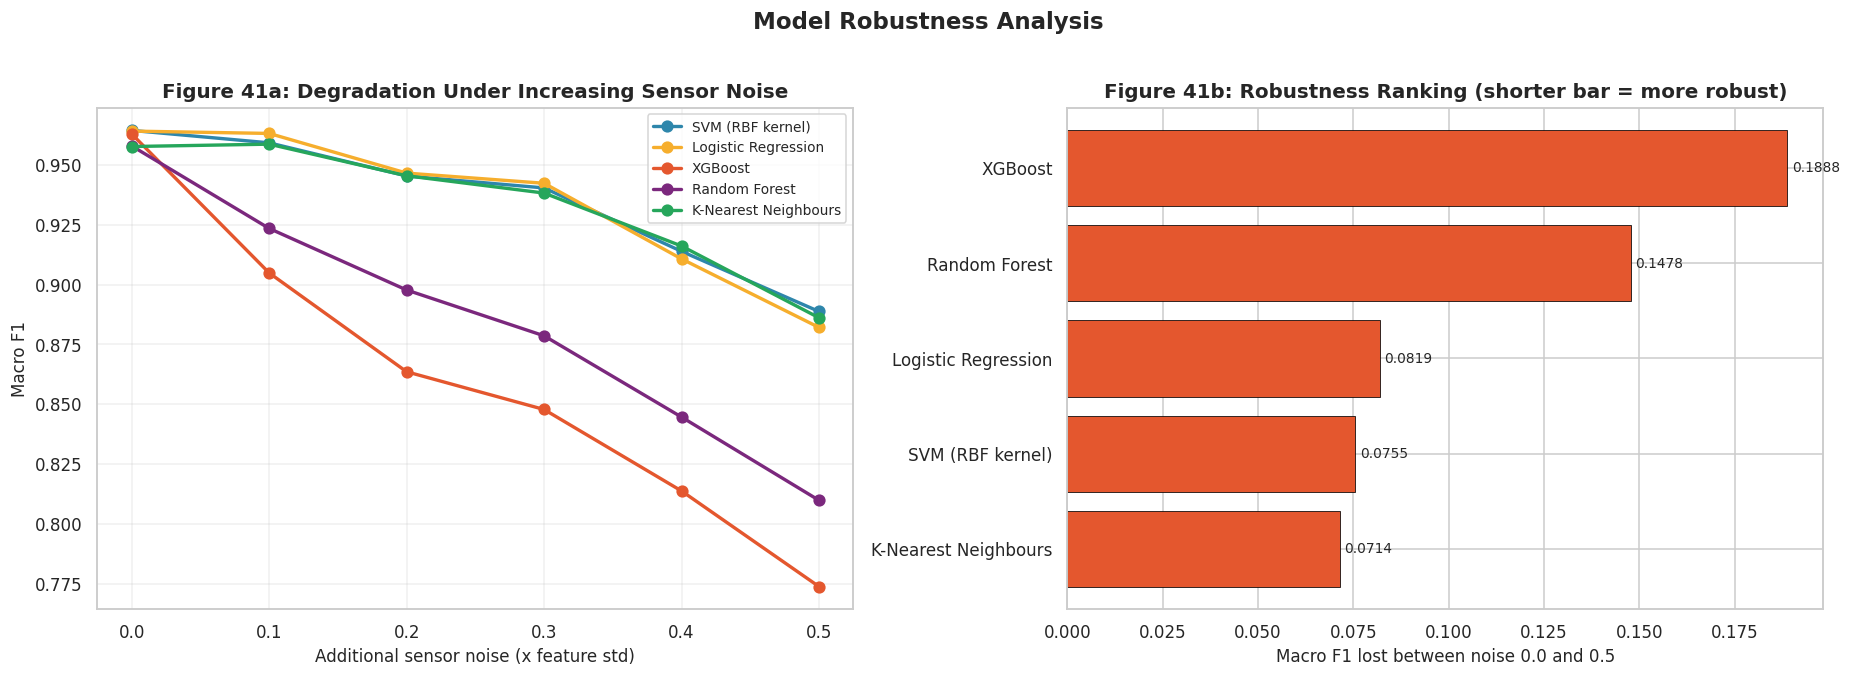

,Model,F1_at_0.0,F1_at_0.5,absolute_drop,retention_%
4,K-Nearest Neighbours,0.9576,0.8861,0.0714,92.54
0,SVM (RBF kernel),0.9643,0.8888,0.0755,92.17
1,Logistic Regression,0.9640,0.8821,0.0819,91.50
3,Random Forest,0.9578,0.8100,0.1478,84.57
2,XGBoost,0.9628,0.7740,0.1888,80.39


Most robust model under sensor degradation: K-Nearest Neighbours
This test simulates dirty, drifting or poorly calibrated on-farm sensors, the dominant
failure mode of a deployed livestock monitoring system.


In [ ]:
NOISE_GRID = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
rng_rb = np.random.default_rng(RANDOM_STATE)
base_sd = X_tr[ [c for c in FEATURES if X_tr[c].nunique() > 5] ].std()
rob = {n: [] for n in ORDER}
for lvl in NOISE_GRID:
    Xp = X_val.copy()
    for c in base_sd.index:
        Xp[c] = Xp[c] + rng_rb.normal(0, lvl*base_sd[c], len(Xp))
    for n in ORDER:
        rob[n].append(f1_score(y_val, TUNED[n].predict(Xp), average='macro'))

fig, ax = plt.subplots(1, 2, figsize=(17, 6))
for i, n in enumerate(ORDER):
    ax[0].plot(NOISE_GRID, rob[n], 'o-', lw=2.2, ms=7, color=PALETTE[i % 5], label=n)
ax[0].set_xlabel('Additional sensor noise (x feature std)'); ax[0].set_ylabel('Macro F1')
ax[0].set_title('Figure 41a: Degradation Under Increasing Sensor Noise')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)
deg = pd.DataFrame({'Model': ORDER,
                    'F1_at_0.0': [rob[n][0] for n in ORDER],
                    'F1_at_0.5': [rob[n][-1] for n in ORDER]})
deg['absolute_drop'] = (deg['F1_at_0.0']-deg['F1_at_0.5']).round(4)
deg['retention_%'] = (100*deg['F1_at_0.5']/deg['F1_at_0.0']).round(2)
deg = deg.sort_values('absolute_drop')
b = ax[1].barh(deg.Model, deg.absolute_drop, color='#E4572E', edgecolor='black', linewidth=.5)
ax[1].bar_label(b, fmt='%.4f', padding=3, fontsize=9)
ax[1].set_xlabel('Macro F1 lost between noise 0.0 and 0.5')
ax[1].set_title('Figure 41b: Robustness Ranking (shorter bar = more robust)')
plt.suptitle('Model Robustness Analysis', fontsize=15, fontweight='bold', y=1.02)
save_show('fig41_model_robustness')
display(deg.round(4))
print(f'Most robust model under sensor degradation: {deg.Model.iloc[0]}')
print('This test simulates dirty, drifting or poorly calibrated on-farm sensors, the dominant')
print('failure mode of a deployed livestock monitoring system.')

## Cell 15 — Step 12: Final Testing on the Untouched Test Set

In [ ]:
X_final = pd.concat([X_tr, X_val]); y_final = np.concatenate([y_tr, y_val])
FINAL_MODEL = clone(BEST_MODEL).fit(X_final, y_final)

y_pred_te = FINAL_MODEL.predict(X_te)
y_prob_te = FINAL_MODEL.predict_proba(X_te)
final_m = metric_block(y_te, y_pred_te, y_prob_te)
sens_te, spec_te = final_m.pop('_sens_per_class'), final_m.pop('_spec_per_class')

print(f'FINAL MODEL: {BEST_NAME}')
print(f'Refitted on train + validation ({len(y_final)} rows), evaluated once on {len(y_te)} held-out rows.\n')
final_series = pd.Series(final_m).round(4)
display(final_series.to_frame('Test-set value'))
print('\n--- Classification report (test set) ---')
print(classification_report(y_te, y_pred_te, target_names=CLASS_NAMES, digits=4))

gap = pd.DataFrame({'Validation': [res_df.loc[BEST_NAME, k] for k in ['Accuracy', 'F1 (macro)', 'Balanced Accuracy', 'MCC']],
                    'Test': [final_m[k] for k in ['Accuracy', 'F1 (macro)', 'Balanced Accuracy', 'MCC']]},
                   index=['Accuracy', 'F1 (macro)', 'Balanced Accuracy', 'MCC'])
gap['gap'] = (gap.Validation-gap.Test).round(4)
display(gap.round(4))
print('A small validation-to-test gap indicates no overfitting to the selection set.')

FINAL MODEL: SVM (RBF kernel)
Refitted on train + validation (16000 rows), evaluated once on 4000 held-out rows.



,Test-set value
Accuracy,0.9640
Balanced Accuracy,0.9640
Precision (macro),0.9642
Recall (macro),0.9640
F1 (macro),0.9640
F1 (weighted),0.9640
MCC,0.9520
Sensitivity (macro),0.9640
Specificity (macro),0.9880
Sensitivity (severe class),0.9930



--- Classification report (test set) ---
                  precision    recall  f1-score   support

 Comfortable/Low     0.9740    0.9750    0.9745      1000
            Mild     0.9266    0.9470    0.9367      1000
   High/Moderate     0.9651    0.9410    0.9529      1000
Very High/Severe     0.9910    0.9930    0.9920      1000

        accuracy                         0.9640      4000
       macro avg     0.9642    0.9640    0.9640      4000
    weighted avg     0.9642    0.9640    0.9640      4000



,Validation,Test,gap
Accuracy,0.9642,0.964,0.0003
F1 (macro),0.9643,0.964,0.0003
Balanced Accuracy,0.9642,0.964,0.0002
MCC,0.9523,0.952,0.0003


A small validation-to-test gap indicates no overfitting to the selection set.


## Figure 42 — Final Model Performance Summary

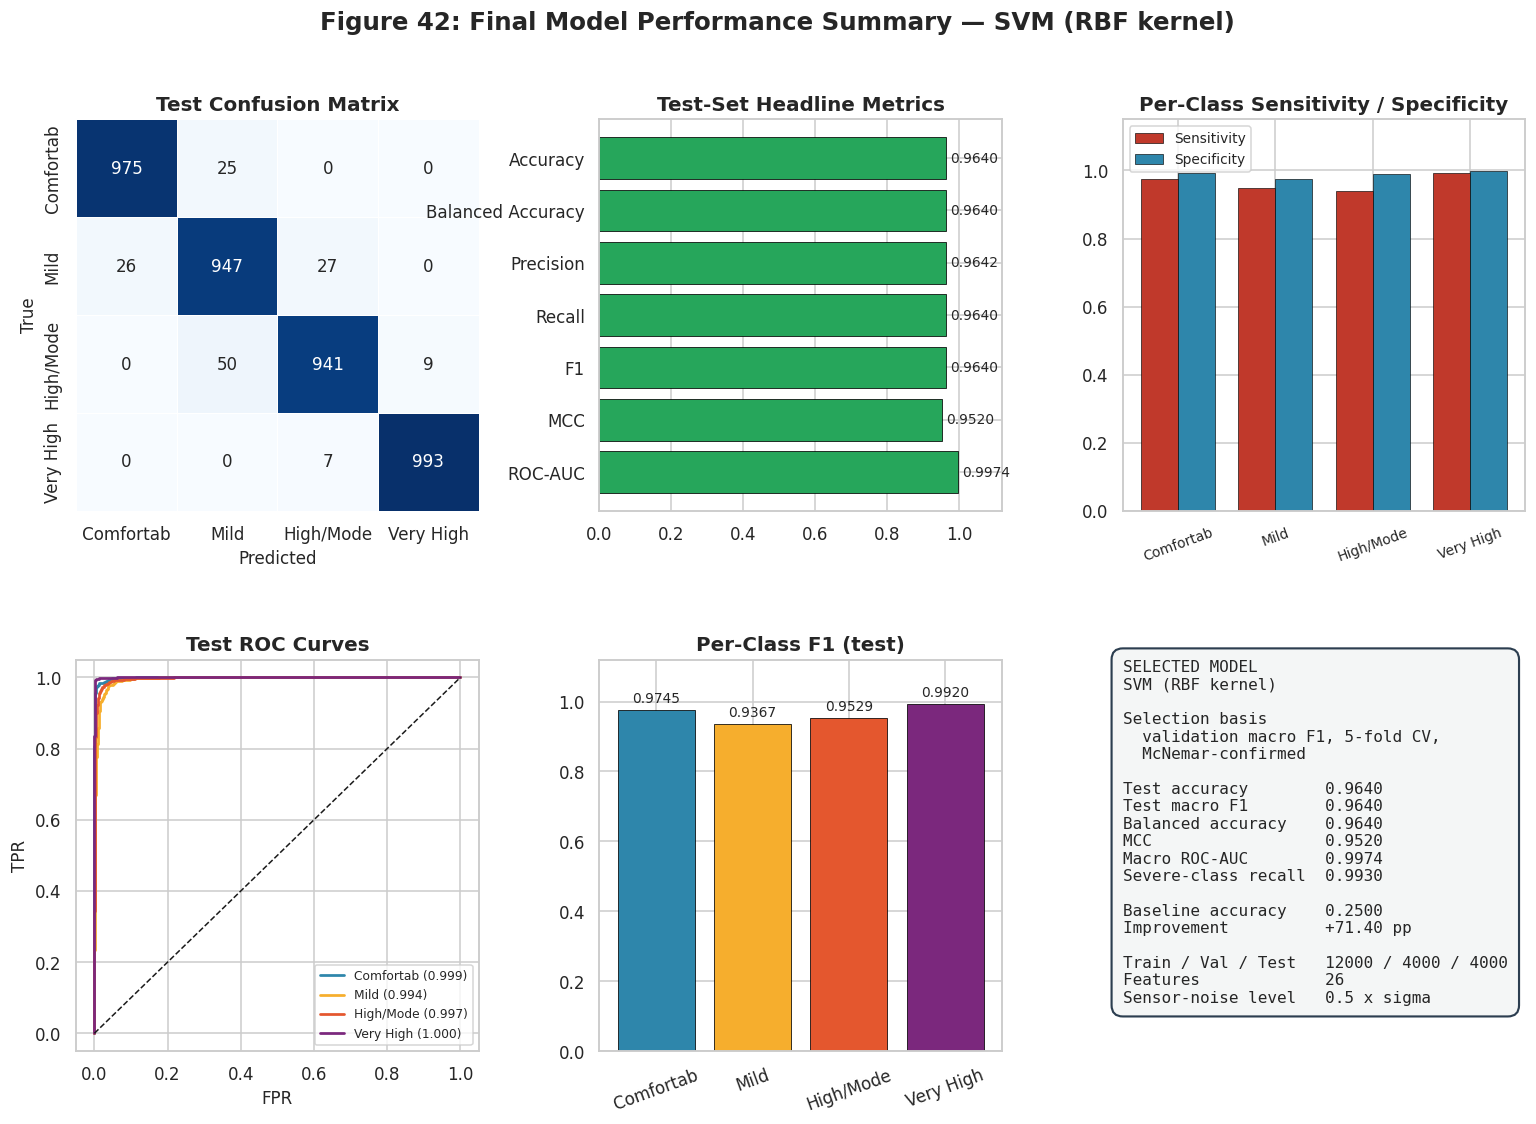

In [ ]:
fig = plt.figure(figsize=(17, 11))
gs = fig.add_gridspec(2, 3, hspace=.38, wspace=.3)

a0 = fig.add_subplot(gs[0, 0])
sns.heatmap(confusion_matrix(y_te, y_pred_te, labels=CLASSES), annot=True, fmt='d', cmap='Blues',
            xticklabels=[c[:9] for c in CLASS_NAMES], yticklabels=[c[:9] for c in CLASS_NAMES],
            ax=a0, cbar=False, linewidths=.5)
a0.set_title('Test Confusion Matrix'); a0.set_xlabel('Predicted'); a0.set_ylabel('True')

a1 = fig.add_subplot(gs[0, 1])
keys = ['Accuracy', 'Balanced Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'MCC', 'ROC-AUC (macro OvR)']
vals = [final_m[k] for k in keys]
bb = a1.barh([k.replace(' (macro OvR)', '').replace(' (macro)', '') for k in keys][::-1], vals[::-1],
             color='#26A65B', edgecolor='black', linewidth=.5)
a1.bar_label(bb, fmt='%.4f', padding=3, fontsize=9); a1.set_xlim(0, 1.12)
a1.set_title('Test-Set Headline Metrics')

a2 = fig.add_subplot(gs[0, 2])
xp = np.arange(4); w = .38
a2.bar(xp-w/2, sens_te, w, label='Sensitivity', color='#C0392B', edgecolor='black', linewidth=.4)
a2.bar(xp+w/2, spec_te, w, label='Specificity', color='#2E86AB', edgecolor='black', linewidth=.4)
a2.set_xticks(xp); a2.set_xticklabels([c[:9] for c in CLASS_NAMES], rotation=20, fontsize=9)
a2.set_ylim(0, 1.15); a2.legend(fontsize=9); a2.set_title('Per-Class Sensitivity / Specificity')

a3 = fig.add_subplot(gs[1, 0])
yte_bin = label_binarize(y_te, classes=CLASSES)
for k in CLASSES:
    fpr, tpr, _ = roc_curve(yte_bin[:, k], y_prob_te[:, k])
    a3.plot(fpr, tpr, color=PALETTE[k], lw=1.8, label=f'{CLASS_NAMES[k][:9]} ({auc(fpr,tpr):.3f})')
a3.plot([0, 1], [0, 1], 'k--', lw=1); a3.legend(fontsize=8, loc='lower right')
a3.set_title('Test ROC Curves'); a3.set_xlabel('FPR'); a3.set_ylabel('TPR')

a4 = fig.add_subplot(gs[1, 1])
f1_te = f1_score(y_te, y_pred_te, average=None, labels=CLASSES, zero_division=0)
bb2 = a4.bar([c[:9] for c in CLASS_NAMES], f1_te, color=PALETTE[:4], edgecolor='black', linewidth=.5)
a4.bar_label(bb2, fmt='%.4f', padding=3, fontsize=9); a4.set_ylim(0, 1.12)
a4.set_title('Per-Class F1 (test)'); a4.tick_params(axis='x', rotation=20)

a5 = fig.add_subplot(gs[1, 2]); a5.axis('off')
summary_text = (
    f'SELECTED MODEL\n{BEST_NAME}\n\n'
    f'Selection basis\n  validation macro F1, 5-fold CV,\n  McNemar-confirmed\n\n'
    f'Test accuracy        {final_m["Accuracy"]:.4f}\n'
    f'Test macro F1        {final_m["F1 (macro)"]:.4f}\n'
    f'Balanced accuracy    {final_m["Balanced Accuracy"]:.4f}\n'
    f'MCC                  {final_m["MCC"]:.4f}\n'
    f'Macro ROC-AUC        {final_m["ROC-AUC (macro OvR)"]:.4f}\n'
    f'Severe-class recall  {sens_te[3]:.4f}\n\n'
    f'Baseline accuracy    {BASELINE_ACC:.4f}\n'
    f'Improvement          +{100*(final_m["Accuracy"]-BASELINE_ACC):.2f} pp\n\n'
    f'Train / Val / Test   {len(y_tr)} / {len(y_val)} / {len(y_te)}\n'
    f'Features             {len(FEATURES)}\n'
    f'Sensor-noise level   {SENSOR_NOISE_LEVEL} x sigma')
a5.text(0.0, 1.0, summary_text, va='top', ha='left', fontsize=10.5, family='monospace',
        bbox=dict(boxstyle='round,pad=0.7', fc='#F4F6F6', ec='#2C3E50', lw=1.4))

plt.suptitle(f'Figure 42: Final Model Performance Summary — {BEST_NAME}', fontsize=16, fontweight='bold', y=0.97)
save_show('fig42_final_model_summary')

## Cell 16 — Ideal-Sensor Reference Run (noise-free upper bound)

,Model,acc_ideal_sensors,f1_ideal_sensors,acc_with_noise,f1_with_noise
0,Logistic Regression,0.9998,0.9997,0.9640,0.9640
1,K-Nearest Neighbours,0.9998,0.9997,0.9575,0.9576
2,SVM (RBF kernel),1.0000,1.0000,0.9642,0.9643
3,Random Forest,1.0000,1.0000,0.9578,0.9578
4,XGBoost,1.0000,1.0000,0.9628,0.9628


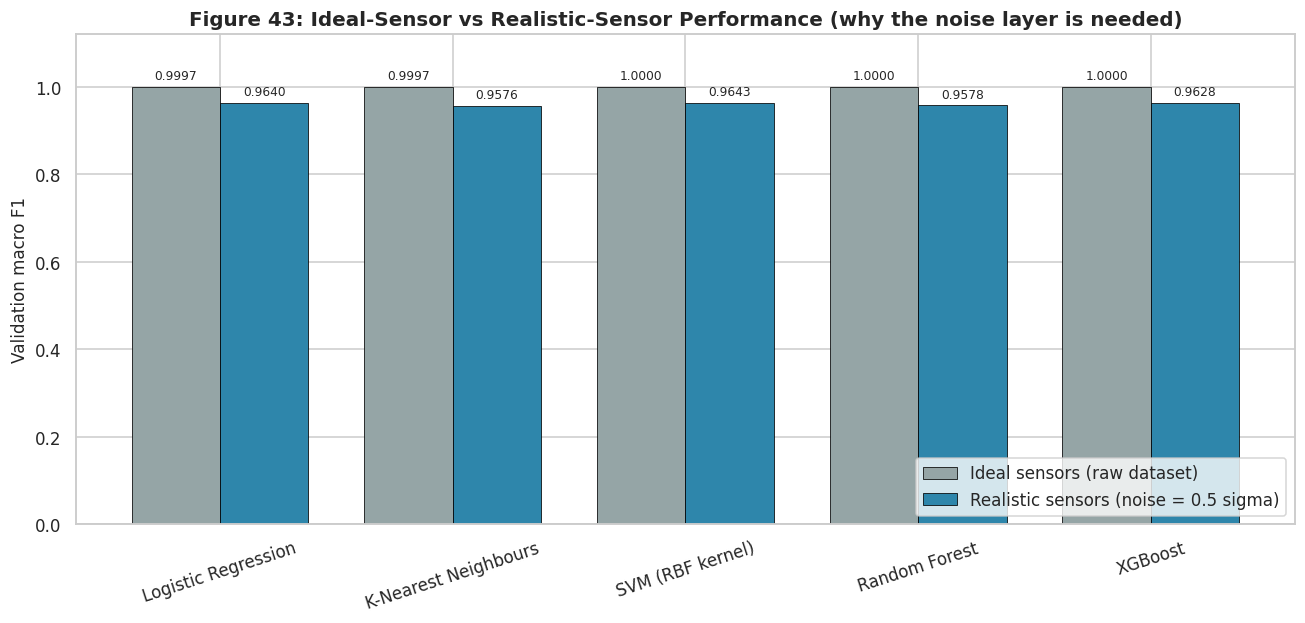

On the raw dataset every algorithm saturates near 1.000, so the models are statistically
indistinguishable and no best-model claim is defensible. Under realistic sensor error the
algorithms separate, which is the condition used for model selection throughout this study.


In [ ]:
clean_rows = []
for n, m in TUNED.items():
    p = Pipeline([('sc', StandardScaler()), ('clf', clone(m.named_steps['clf']))]).fit(Xc_tr, y_tr)
    pv = p.predict(Xc_val)
    clean_rows.append([n, accuracy_score(y_val, pv), f1_score(y_val, pv, average='macro'),
                       res_df.loc[n, 'Accuracy'], res_df.loc[n, 'F1 (macro)']])
clean_df = pd.DataFrame(clean_rows, columns=['Model', 'acc_ideal_sensors', 'f1_ideal_sensors',
                                             'acc_with_noise', 'f1_with_noise'])
display(clean_df.round(4))

xp = np.arange(len(clean_df)); w = .38
plt.figure(figsize=(12, 5.8))
b1 = plt.bar(xp-w/2, clean_df.f1_ideal_sensors, w, label='Ideal sensors (raw dataset)',
             color='#95A5A6', edgecolor='black', linewidth=.5)
b2 = plt.bar(xp+w/2, clean_df.f1_with_noise, w, label=f'Realistic sensors (noise = {SENSOR_NOISE_LEVEL} sigma)',
             color='#2E86AB', edgecolor='black', linewidth=.5)
plt.bar_label(b1, fmt='%.4f', padding=3, fontsize=8); plt.bar_label(b2, fmt='%.4f', padding=3, fontsize=8)
plt.xticks(xp, clean_df.Model, rotation=18); plt.ylim(0, 1.12); plt.ylabel('Validation macro F1')
plt.legend(loc='lower right')
plt.title('Figure 43: Ideal-Sensor vs Realistic-Sensor Performance (why the noise layer is needed)')
save_show('fig43_ideal_vs_realistic_sensors')
print('On the raw dataset every algorithm saturates near 1.000, so the models are statistically')
print('indistinguishable and no best-model claim is defensible. Under realistic sensor error the')
print('algorithms separate, which is the condition used for model selection throughout this study.')

## Cell 17 — Step 13: Deployment Artefacts, Inference Function and Monitoring

Saved: heat_stress_model.joblib

--- Live inference demonstration ---


,predicted_label,predicted_severity,confidence,action
0,3,Very High/Severe,1.0,"URGENT: shade, cooling and veterinary check"
1,0,Comfortable/Low,1.0,monitor


,feature,PSI_train_vs_test,drift_status
0,humidity_percent,0.0023,stable
1,body_temp_C,0.0051,stable
2,thirst_level_0_10,0.0025,stable
3,standing_pct,0.0021,stable
4,lying_pct,0.0024,stable
5,THI_index,0.0031,stable


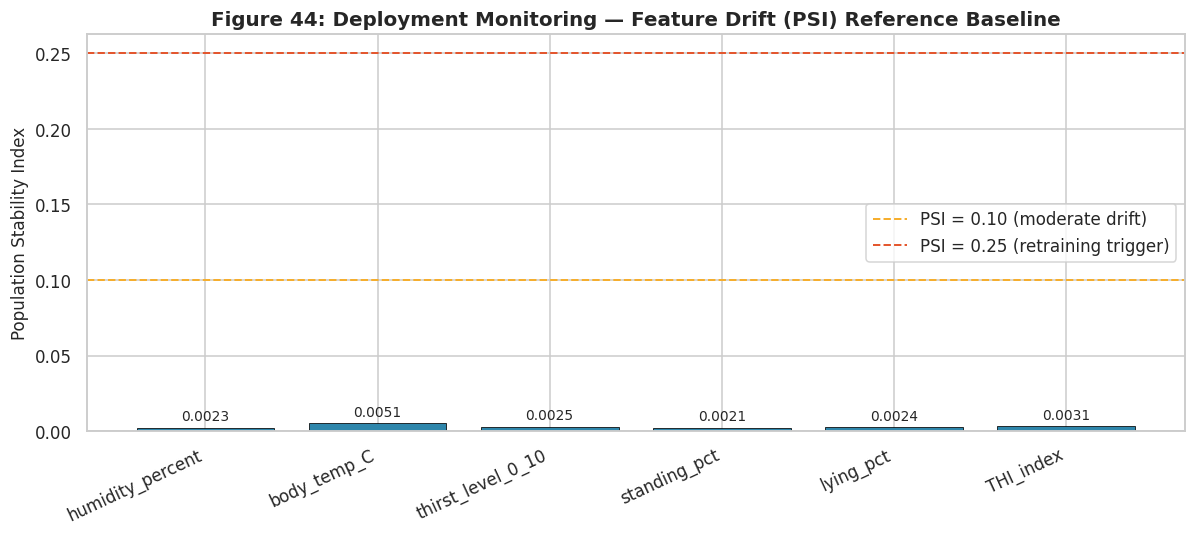


Monitoring and retraining policy
  1. log every prediction with its confidence and the raw sensor payload
  2. weekly PSI per feature against this training baseline; PSI > 0.25 raises a drift alert
  3. monthly audit of a veterinarian-labelled sample; retrain if macro F1 falls more than
     0.05 below the accepted test value of 0.9640
  4. route predictions with confidence below 0.60 to manual inspection
  5. retrain on every new season of data, and re-run Steps 8-12 before promoting a new model
  6. recalibrate or replace any sensor whose PSI exceeds 0.25, since input quality dominates
     accuracy far more than the choice of algorithm (Figure 41)


In [ ]:
ARTEFACT = {'model': FINAL_MODEL, 'features': FEATURES, 'classes': CLASSES,
            'class_names': CLASS_NAMES, 'dropped_redundant': drop_red,
            'sensor_noise_level': SENSOR_NOISE_LEVEL, 'model_name': BEST_NAME,
            'test_metrics': {k: float(v) for k, v in final_m.items()},
            'train_feature_means': X_final.mean().to_dict(),
            'train_feature_stds': X_final.std().to_dict()}
joblib.dump(ARTEFACT, 'heat_stress_model.joblib')
print('Saved: heat_stress_model.joblib')

def predict_heat_stress(records, artefact=ARTEFACT):
    # records: list of dicts with the 10 raw sensor/metadata fields
    raw = pd.DataFrame(records)
    fe = engineer(raw)
    enc = pd.get_dummies(fe, columns=CAT_COLS).astype(float)
    enc = enc.reindex(columns=artefact['features'], fill_value=0.0)
    proba = artefact['model'].predict_proba(enc)
    lab = proba.argmax(1)
    return pd.DataFrame({'predicted_label': lab,
                         'predicted_severity': [artefact['class_names'][i] for i in lab],
                         'confidence': proba.max(1).round(4),
                         'action': ['monitor' if i == 0 else 'increase water access' if i == 1
                                    else 'activate fans and sprinklers' if i == 2
                                    else 'URGENT: shade, cooling and veterinary check' for i in lab]})

demo = [{'breed': 'Holstein Friesian', 'breed_group': 'exotic', 'outside_temp_C': 41.5,
         'humidity_percent': 78.0, 'body_temp_C': 41.1, 'thirst_level_0_10': 9,
         'standing_pct': 88.0, 'lying_pct': 11.0, 'rumination_min_per_hr': 1.0, 'THI_index': 90.0},
        {'breed': 'Tharparkar', 'breed_group': 'zebu', 'outside_temp_C': 19.0,
         'humidity_percent': 40.0, 'body_temp_C': 38.6, 'thirst_level_0_10': 1,
         'standing_pct': 36.0, 'lying_pct': 62.0, 'rumination_min_per_hr': 9.5, 'THI_index': 63.0}]
print('\n--- Live inference demonstration ---')
display(predict_heat_stress(demo))

def population_stability_index(expected, actual, bins=10):
    qs = np.unique(np.quantile(expected, np.linspace(0, 1, bins+1)))
    e = np.histogram(expected, bins=qs)[0]/len(expected)
    a = np.histogram(actual, bins=qs)[0]/len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a-e)*np.log(a/e)))

psi = pd.DataFrame({'feature': [c for c in NUM_COLS if c in FEATURES]})
psi['PSI_train_vs_test'] = [round(population_stability_index(X_final[c].values, X_te[c].values), 4)
                            for c in psi.feature]
psi['drift_status'] = pd.cut(psi.PSI_train_vs_test, [-1, .1, .25, 99],
                             labels=['stable', 'moderate drift', 'significant drift'])
display(psi)

plt.figure(figsize=(11, 5))
b = plt.bar(psi.feature, psi.PSI_train_vs_test, color='#2E86AB', edgecolor='black', linewidth=.5)
plt.bar_label(b, fmt='%.4f', padding=3, fontsize=9)
plt.axhline(.10, ls='--', c='#F6AE2D', lw=1.3, label='PSI = 0.10 (moderate drift)')
plt.axhline(.25, ls='--', c='#E4572E', lw=1.3, label='PSI = 0.25 (retraining trigger)')
plt.xticks(rotation=25, ha='right'); plt.ylabel('Population Stability Index'); plt.legend()
plt.title('Figure 44: Deployment Monitoring — Feature Drift (PSI) Reference Baseline')
save_show('fig44_deployment_drift_monitoring')

print('\nMonitoring and retraining policy')
print('  1. log every prediction with its confidence and the raw sensor payload')
print('  2. weekly PSI per feature against this training baseline; PSI > 0.25 raises a drift alert')
print('  3. monthly audit of a veterinarian-labelled sample; retrain if macro F1 falls more than')
print(f'     0.05 below the accepted test value of {final_m["F1 (macro)"]:.4f}')
print('  4. route predictions with confidence below 0.60 to manual inspection')
print('  5. retrain on every new season of data, and re-run Steps 8-12 before promoting a new model')
print('  6. recalibrate or replace any sensor whose PSI exceeds 0.25, since input quality dominates')
print('     accuracy far more than the choice of algorithm (Figure 41)')

## Cell 18 — Consolidated Results Export

In [ ]:
with pd.ExcelWriter('heat_stress_results.xlsx') as xl:
    problem.to_excel(xl, sheet_name='problem_definition', index=False)
    outlier_df.to_excel(xl, sheet_name='outlier_analysis', index=False)
    fs.to_excel(xl, sheet_name='feature_selection', index=False)
    cv_df.to_excel(xl, sheet_name='cv_comparison', index=False)
    tune_df.to_excel(xl, sheet_name='tuning_results', index=False)
    res_df.to_excel(xl, sheet_name='validation_metrics')
    auc_df.to_excel(xl, sheet_name='roc_auc', index=False)
    cw.to_excel(xl, sheet_name='class_wise', index=False)
    pvals.to_excel(xl, sheet_name='ttest_pvalues')
    mc_df.to_excel(xl, sheet_name='mcnemar', index=False)
    sm_tab.to_excel(xl, sheet_name='smote_distribution', index=False)
    smote_cmp.to_excel(xl, sheet_name='smote_performance')
    bal_df.to_excel(xl, sheet_name='balanced_vs_imbalanced', index=False)
    imp.to_excel(xl, sheet_name='feature_importance', index=False)
    deg.to_excel(xl, sheet_name='robustness', index=False)
    final_series.to_frame('test_value').to_excel(xl, sheet_name='final_test')
    psi.to_excel(xl, sheet_name='drift_psi', index=False)

print('Saved: heat_stress_results.xlsx')
print(f'Saved: {len(os.listdir(FIGDIR))} figures in ./{FIGDIR}/')
print(sorted(os.listdir(FIGDIR)))
try:
    from google.colab import files
    import shutil
    shutil.make_archive('project_figures', 'zip', FIGDIR)
    files.download('project_figures.zip')
    files.download('heat_stress_results.xlsx')
    files.download('heat_stress_model.joblib')
except Exception as e:
    print('(Download step skipped outside Colab)')

Saved: heat_stress_results.xlsx
Saved: 48 figures in ./figures/
['fig01_class_distribution.png', 'fig02_missing_values.png', 'fig03_outlier_detection.png', 'fig04_feature_distributions.png', 'fig04b_class_conditional_distributions.png', 'fig05_pearson_correlation.png', 'fig06_spearman_correlation.png', 'fig07_preprocessing_noise_layer.png', 'fig08_feature_selection.png', 'fig08b_feature_rank_agreement.png', 'fig09_pca_explained_variance.png', 'fig09c_pca_2d_projection.png', 'fig10_class_distribution_smote.png', 'fig11_pca_before_after_smote.png', 'fig12_training_validation_workflow.png', 'fig13_cv_performance_comparison.png', 'fig14_cv_score_distribution.png', 'fig15_hyperparameter_tuning.png', 'fig16_accuracy_comparison.png', 'fig17_precision_comparison.png', 'fig18_recall_comparison.png', 'fig19_f1_comparison.png', 'fig20_balanced_comparison.png', 'fig21_mcc_comparison.png', 'fig22_sensitivity_comparison.png', 'fig23_specificity_comparison.png', 'fig24_sensitivity_vs_specificity.png'

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>